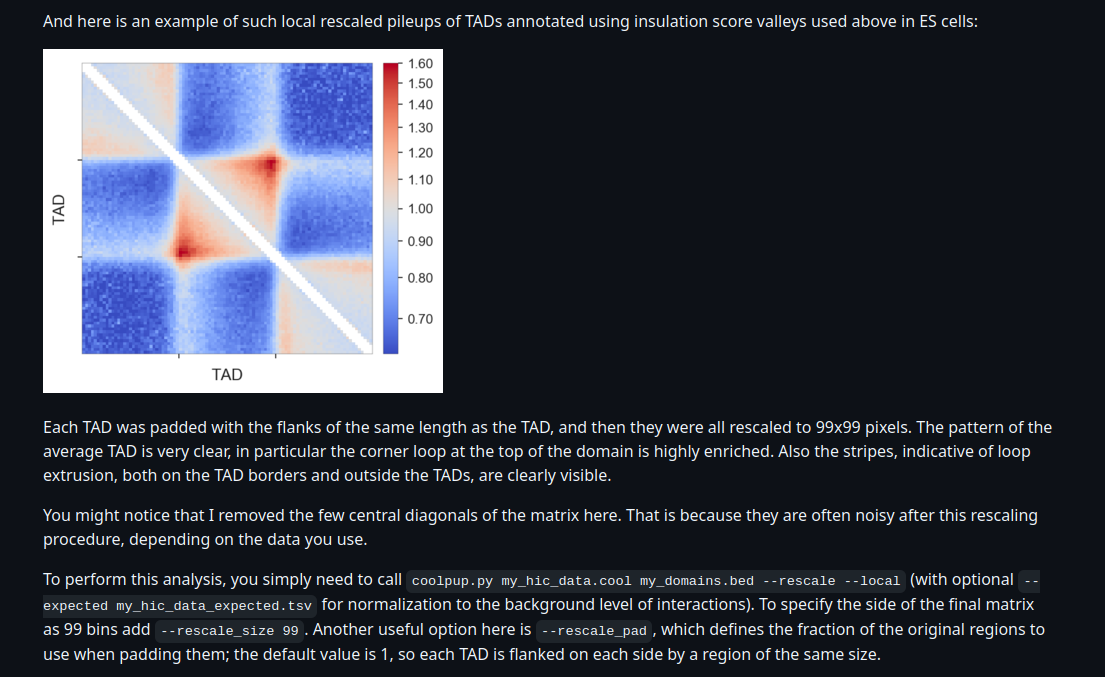

In [1]:
import pandas as pd
import cooler
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from functools import partial

def adjust_locus(locus_position, chromsize, is_circ_chrom = False):
        """Adjust the coordinates of a locus to fit between 0 and the chromosome size. Accounts for circularity."""
        if locus_position < 0:
            locus_position = chromsize + locus_position if is_circ_chrom else 0

        if locus_position >= chromsize:
            locus_position = locus_position - chromsize if is_circ_chrom else chromsize
        return locus_position

dickeya_regions = """Chromosome	Start	End	Id
NC_014500.1	4822882	100000	Ori
NC_014500.1	100001	2329999	Arm1
NC_014500.1	2330000	2580000	Ter
NC_014500.1	2580001	4822881	Arm2"""

dickeya_regions = """Chromosome	Start	End	Id
NC_014500.1	3215000	3235000	Region1
NC_014500.1	3365000	3385000	Region2
NC_014500.1	4025000	4045000	Region3
NC_014500.1	4285000	4305000	Region4
NC_014500.1	2620000	2640000	Region5"""

dickeya_regions_df = pd.DataFrame([line.split("\t") for line in dickeya_regions.split("\n")])
dickeya_regions_df.rename(columns=dickeya_regions_df.iloc[0], inplace = True)
dickeya_regions_df.drop(dickeya_regions_df.index[0], inplace = True)
dickeya_regions_df["Start"] = dickeya_regions_df["Start"].astype('int64')
dickeya_regions_df["End"] = dickeya_regions_df["End"].astype('int64')

# Hi-C dataset
banks = ["Control", "PGA", "Acid", "Endive1_2025", "Endive2_2025", "Endive3_2025", "Endive4_2025", "Endive5_2025"]
binning = 1000
chromsize = 4922802
hics = [
    #f"C:/Users/maely/Desktop/D. dadantii Hi-C/cool_files/{bank}.mcool::resolutions/{binning}" for bank in banks
    f"/data/Maelys/datas/cool_files/{bank}/{bank}.mcool::resolutions/{binning}" for bank in banks
]
dickeya_regions_df

,Chromosome,Start,End,Id
1,NC_014500.1,3215000,3235000,Region1
2,NC_014500.1,3365000,3385000,Region2
3,NC_014500.1,4025000,4045000,Region3
4,NC_014500.1,4285000,4305000,Region4
5,NC_014500.1,2620000,2640000,Region5


In [2]:
import math
def apply_padding(region, chromsize, padding_size = 0.5):
    """Adds padding to region in new columns, "Padded_start" and "Padded_end"."""
    # applying padding
    region_size = region["End"] - region["Start"] if region["Start"] <= region["End"] else (chromsize - region["Start"]) + region["End"]
    padding = math.floor(region_size * padding_size)
    
    region["Padded_start"] = (region["Start"] - padding) % chromsize    
    region["Padded_end"] = (region["End"] + padding) % chromsize
    region["Padding"] = padding
    region["Size"] = padding
    
    return region

dickeya_padded_regions = []
for i in range(len(dickeya_regions_df)):
    dickeya_padded_regions.append(apply_padding(dickeya_regions_df.iloc[i], chromsize))
    
dickeya_padded_regions = pd.DataFrame(dickeya_padded_regions)
dickeya_padded_regions

/tmp/ipykernel_10501/2372808659.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region["Padded_start"] = (region["Start"] - padding) % chromsize
/tmp/ipykernel_10501/2372808659.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region["Padded_start"] = (region["Start"] - padding) % chromsize
/tmp/ipykernel_10501/2372808659.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region["Padded_end"] = (region["End"] + padding) % chroms

,Chromosome,Start,End,Id,Padded_start,Padded_end,Padding,Size
1,NC_014500.1,3215000,3235000,Region1,3205000,3245000,10000,10000
2,NC_014500.1,3365000,3385000,Region2,3355000,3395000,10000,10000
3,NC_014500.1,4025000,4045000,Region3,4015000,4055000,10000,10000
4,NC_014500.1,4285000,4305000,Region4,4275000,4315000,10000,10000
5,NC_014500.1,2620000,2640000,Region5,2610000,2650000,10000,10000


In [3]:
# extracting individual windows from the list of regions
def extract_window_region(cool, region1, region2, is_loc_circ1 = False, is_loc_circ2 = False, raw = False):
    """Extracts a submatrix of regions interaction zone from cool matrix.
    If required, adds paddings. Takes into account chromosome circularity."""
    matrix = cool.matrix(balance=(not raw))
    binning = cool.binsize

    if region1["Chromosome"] not in cool.chromsizes or region2["Chromosome"] not in cool.chromsizes:
        return None
    chrom_size1 = cool.chromsizes[region1["Chromosome"]]
    chrom_size2 = cool.chromsizes[region2["Chromosome"]]
    
    start1 = adjust_locus(region1["Start"], chrom_size1, is_circ_chrom = is_loc_circ1)
    end1 = adjust_locus(region1["End"], chrom_size1, is_circ_chrom = is_loc_circ1)
    start2 = adjust_locus(region2["Start"], chrom_size2, is_circ_chrom = is_loc_circ2)
    end2 = adjust_locus(region2["End"], chrom_size2, is_circ_chrom = is_loc_circ2)

    region1_size = region1["Size"]
    region2_size = region2["Size"]
    
    # adjusting to cooler bins
    start1 = start1 + 1 if start1 % binning == 0 else start1
    start2 = start2 + 1 if start2 % binning == 0 else start2
    
    end1 = end1 - 1 if end1 % binning == 0 else end1
    end2 = end2 - 1 if end2 % binning == 0 else end2

    # 1. checking overflows
    region1_overflow = start1 > end1
    region2_overflow = start2 > end2

    # 2. computing intervales TODO: make sure the original submatrix includes the region center
    pos1 = f"{region1['Chromosome']}:{start1 if not region1_overflow else 0}-{end1}"
    pos2 = f"{region2['Chromosome']}:{start2 if not region2_overflow else 0}-{end2}"

    # 3. fetching main submatrix
    submatrix = matrix.fetch(pos1, pos2)[:]
    
    if (not region1_overflow and not region2_overflow): # no overflow
        return submatrix
    
    # 4. managing overflows: always bellow 0
    bins1_to_fill = region1_size // binning - submatrix.shape[0]
    bins2_to_fill = region2_size // binning - submatrix.shape[1]

    if bins1_to_fill > 0:
        fill1 = np.array([chrom_size1 - (bins1_to_fill * binning), chrom_size1])
        fill1_pos = f"{region1['Chromosome']}:{fill1[0]}-{fill1[1]}"
        len1 = abs(fill1[0] - fill1[1]) // binning
    
    if bins2_to_fill > 0:
        fill2 = np.array([chrom_size2 - (bins2_to_fill * binning), chrom_size2])
        fill2_pos = f"{region2['Chromosome']}:{fill2[0]}-{fill2[1]}"
        len2 = abs(fill2[0] - fill2[1]) // binning
    
    mat1, mat2 = None, None
    if bins2_to_fill > 0:
        mat1 = matrix.fetch(pos1, fill2_pos) if is_loc_circ2 else np.full((submatrix.shape[0], len2), np.nan)
        if mat1.shape[1] > len2:
            mat1 = mat1[:, 1:]
    
    if bins1_to_fill > 0:
        mat2 = matrix.fetch(fill1_pos, pos2) if is_loc_circ1 else np.full((len1, submatrix.shape[1]), np.nan)
        if mat2.shape[0] > len1:
            mat2 = mat2[1:]
        
    # two dimensions to fill
    if region1_overflow and region2_overflow:

        mat3 = matrix.fetch(fill1_pos, fill2_pos) if is_loc_circ1 and is_loc_circ2 else np.full((len1,len2), np.nan)
        if mat3.shape[1] > len2:
            mat3 = mat3[:, 1:]
        if mat3.shape[0] > len1:
            mat3 = mat3[1:]

        concat1 = np.concatenate([mat1, submatrix], axis = 1)
        concat2 = np.concatenate([mat3, mat2], axis = 1)
        submatrix = np.concatenate([concat2, concat1], axis = 0)
        
    # dim1 to fill
    elif region1_overflow:        
        submatrix = np.concatenate([mat2, submatrix], axis = 0)
        
    # dim2 to fill
    elif region2_overflow:
        submatrix = np.concatenate([mat1, submatrix], axis = 1)

    return submatrix

def zoom_array(
    in_array,
    final_shape,
    same_sum=False,
    zoom_function=partial(zoom, order=1),
    **zoom_kwargs
):
    """Rescale an array or image.

    Normally, one can use scipy.ndimage.zoom to do array/image rescaling.
    However, scipy.ndimage.zoom does not coarsegrain images well. It basically
    takes nearest neighbor, rather than averaging all the pixels, when
    coarsegraining arrays. This increases noise. Photoshop doesn't do that, and
    performs some smart interpolation-averaging instead.

    If you were to coarsegrain an array by an integer factor, e.g. 100x100 ->
    25x25, you just need to do block-averaging, that's easy, and it reduces
    noise. But what if you want to coarsegrain 100x100 -> 30x30?

    Then my friend you are in trouble. But this function will help you. This
    function will blow up your 100x100 array to a 120x120 array using
    scipy.ndimage zoom Then it will coarsegrain a 120x120 array by
    block-averaging in 4x4 chunks.

    It will do it independently for each dimension, so if you want a 100x100
    array to become a 60x120 array, it will blow up the first and the second
    dimension to 120, and then block-average only the first dimension.

    (Copied from mirnylib.numutils)

    Parameters
    ----------
    in_array : ndarray
        n-dimensional numpy array (1D also works)
    final_shape : shape tuple
        resulting shape of an array
    same_sum : bool, optional
        Preserve a sum of the array, rather than values. By default, values
        are preserved
    zoom_function : callable
        By default, scipy.ndimage.zoom with order=1. You can plug your own.
    **zoom_kwargs :
        Options to pass to zoomFunction.

    Returns
    -------
    rescaled : ndarray
        Rescaled version of in_array

    """
    in_array = np.asarray(in_array, dtype=np.double)
    in_shape = in_array.shape
    assert len(in_shape) == len(final_shape)
    mults = []  # multipliers for the final coarsegraining
    for i in range(len(in_shape)):
        if final_shape[i] < in_shape[i]:
            mults.append(int(np.ceil(in_shape[i] / final_shape[i])))
        else:
            mults.append(1)
    # shape to which to blow up
    temp_shape = tuple([i * j for i, j in zip(final_shape, mults)])

    # stupid zoom doesn't accept the final shape. Carefully crafting the
    # multipliers to make sure that it will work.
    zoom_multipliers = np.array(temp_shape) / np.array(in_shape) + 0.0000001
    assert zoom_multipliers.min() >= 1

    # applying scipy.ndimage.zoom
    rescaled = zoom_function(in_array, zoom_multipliers, **zoom_kwargs)

    for ind, mult in enumerate(mults):
        if mult != 1:
            sh = list(rescaled.shape)
            assert sh[ind] % mult == 0
            newshape = sh[:ind] + [sh[ind] // mult, mult] + sh[ind + 1 :]
            rescaled.shape = newshape
            rescaled = np.mean(rescaled, axis=ind + 1)
    assert rescaled.shape == final_shape

    if same_sum:
        extra_size = np.prod(final_shape) / np.prod(in_shape)
        rescaled /= extra_size
    return rescaled

def resize_window(submatrix, expected_size = 100):
    """Resizes a submatrix to match the shape expected_size x expected_size."""
    return zoom_array(submatrix, (expected_size, expected_size))

In [4]:
# usefull region functions
def compute_bin_coordinates(region, chromsize, binning, add_padding = True):
    """Computes all the coordinates of the bins in the submatrix."""    
    start = region["Padded_start"] if add_padding else region["Start"]
    end = region["Padded_end"] if add_padding else region["End"]
    
    if start <= end:
        return np.array(range(start//binning, end//binning))
    return np.concatenate([
        np.array(range(start//binning, (chromsize - 1)//binning)),
        np.array(range(end//binning))
    ])
    
def get_common_bins(bins1, bins2):
    """Yields the coordinates list of each bins list corresponding to a consecutive list of bins present in both."""
    nb_bins1 = len(bins1)
    nb_bins2 = len(bins2)
    
    if nb_bins1 == 0 or nb_bins2 == 0:
        pass
    
    # reorganising the list for circular coordinates
    zero1, zero2 = 0, 0
    if 0 in bins1:
        while bins1[zero1] != 0:
            zero1 += 1
        bins1 = np.concatenate([bins1[zero1:], bins1[:zero1]])
    if 0 in bins2:
        while bins2[zero2] != 0:
            zero2 += 1
        bins2 = np.concatenate([bins2[zero2:], bins2[:zero2]])
    
    current_list = [[], []]
    i, j = 0, 0
    while i < nb_bins1 and j < nb_bins2:
        if bins1[i] < bins2[j]:
            i += 1
        elif bins2[j] < bins1[i]:
            j += 1
        elif bins2[j] == bins1[i]:
            i_shifted = (i + zero1) % nb_bins1
            j_shifted = (j + zero2) % nb_bins2
            # checking that the indexes to add are consecutive to the previous. Otherwise, the current_list is yielded and re-initialized with the new indexes.
            if len(current_list[0]) == 0 or (current_list[0][-1] == i_shifted - 1 and current_list[1][-1] == j_shifted - 1):
                current_list[0].append(i_shifted)
                current_list[1].append(j_shifted)
            else:
                yield current_list
                current_list = [[i_shifted], [j_shifted]]
            i += 1
            j += 1
    if len(current_list[0]) > 0:
        yield current_list

def mask_diagonal_region(submatrix, region1, region2, binning, diagonal_mask, chromsize = 0, add_padding = True):
    """Computes the mask to apply to the diagonal from positions 1 and 2"""
    if region1["Chromosome"] != region2["Chromosome"]:
        return submatrix
    
    for subcoords in get_common_bins(
        compute_bin_coordinates(region1, chromsize, binning, add_padding = add_padding),
        compute_bin_coordinates(region2, chromsize, binning, add_padding = add_padding)
    ):
        start_dim0, end_dim0 = subcoords[0][0], subcoords[0][-1] + 1
        start_dim1, end_dim1 = subcoords[1][0], subcoords[1][-1] + 1
        
        for i in range(diagonal_mask//binning):
            # upper diagonal
            start = start_dim0 - i
            shift_dim1 = abs(start) if start <= 0 else 0
            start = 0 if start <= 0 else start
            end = end_dim1 + i if end_dim1 + i <= submatrix.shape[1] else submatrix.shape[1]
            np.fill_diagonal(submatrix[start: end_dim0, start_dim1 + shift_dim1: end], np.nan)
            
            # lower diagonal
            start = start_dim1 - i
            shift_dim0 = abs(start) if start < 0 else 0
            start = 0 if start <= 0 else start
            end = end_dim0 + i if end_dim0 + i <= submatrix.shape[0] else submatrix.shape[0]
            np.fill_diagonal(submatrix[start_dim0 + shift_dim0: end, start: end_dim1], np.nan)
    
    return submatrix

/data/Maelys/datas/cool_files/Control/Control.mcool::resolutions/1000
Region1 Region1
(20, 20)


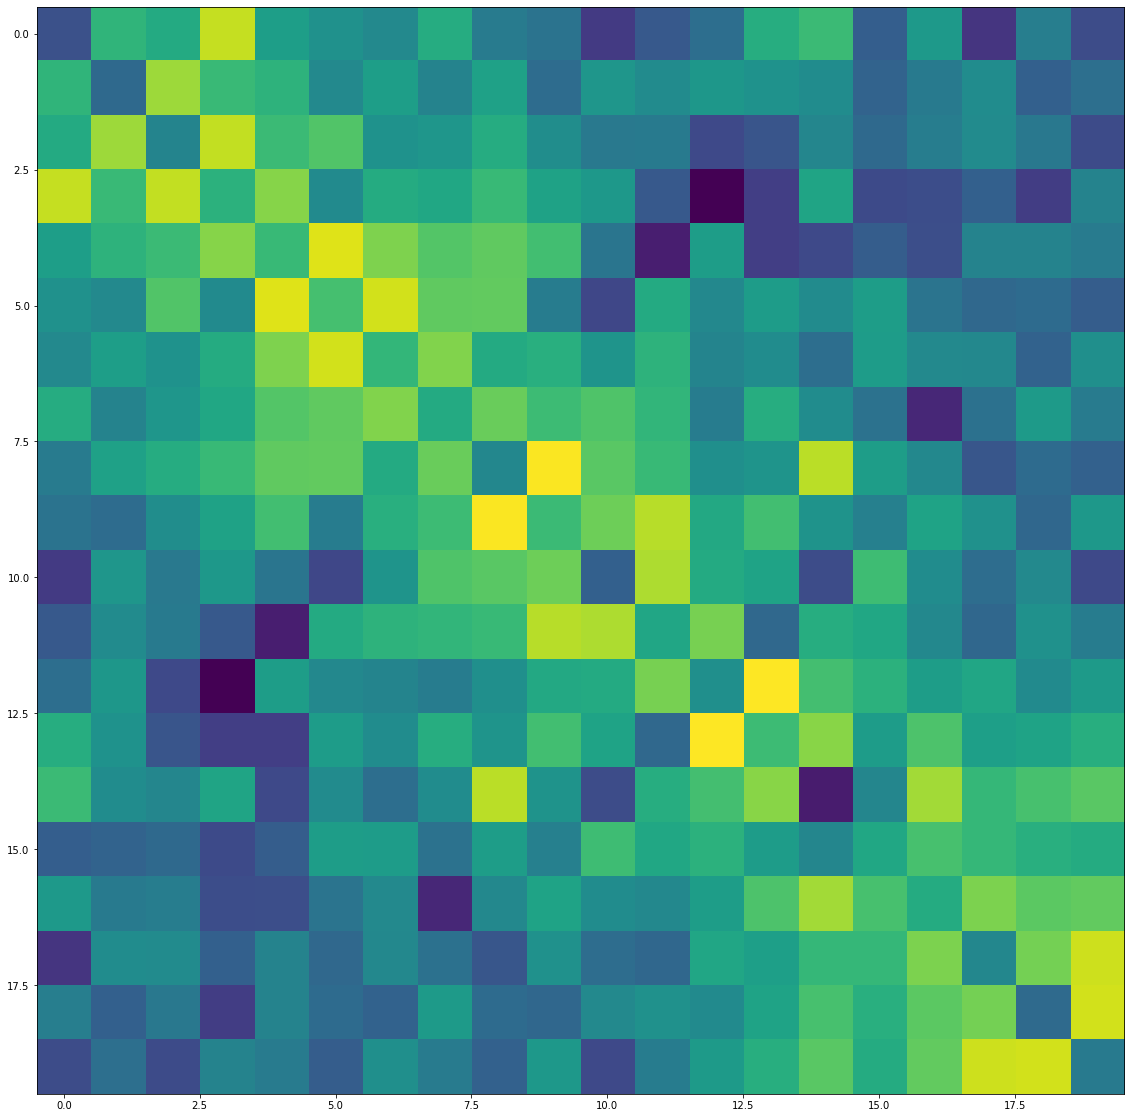

Masked:


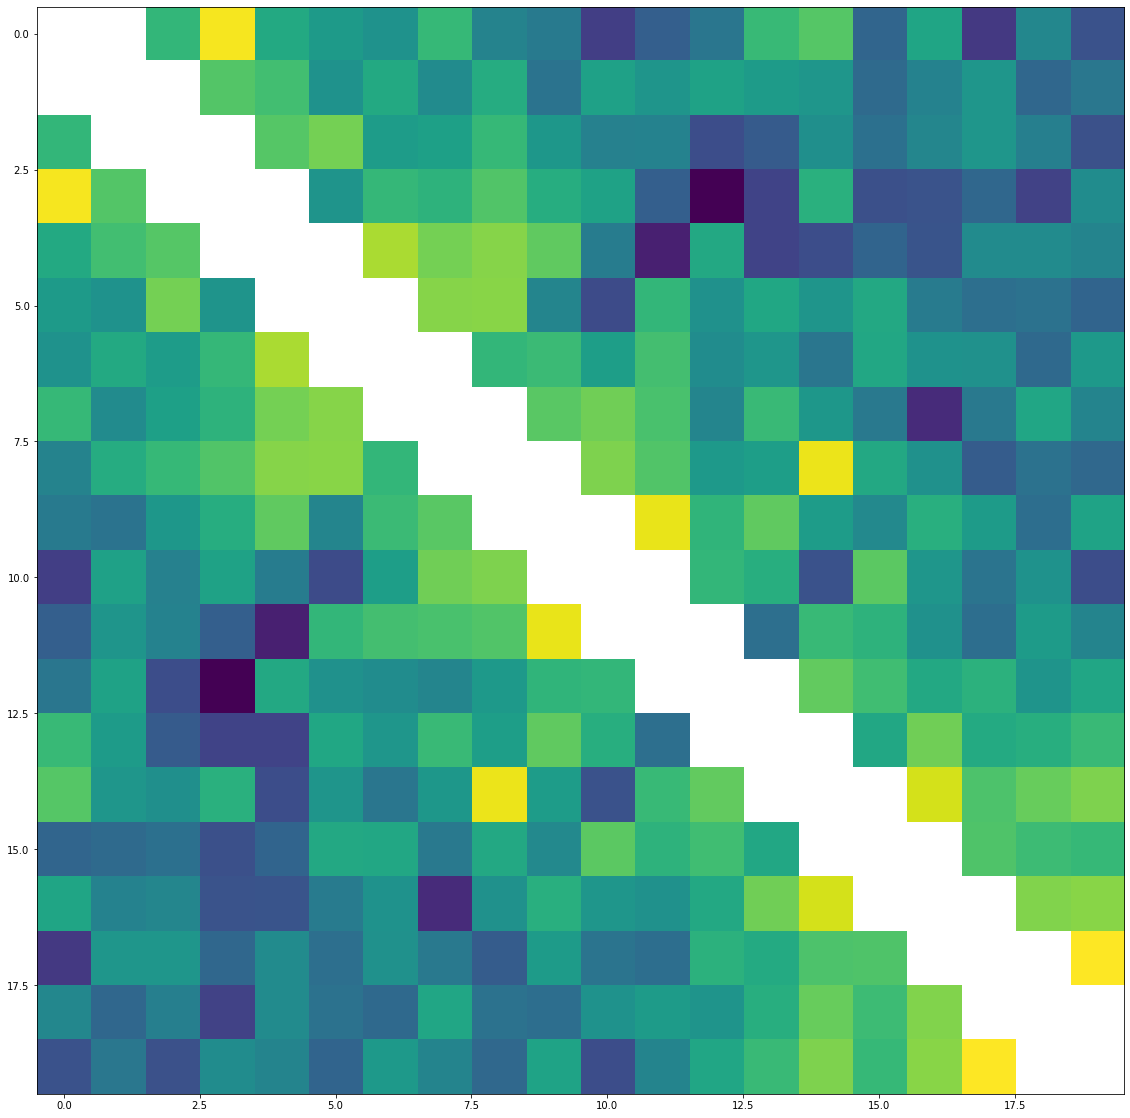

Resized:


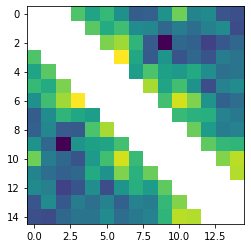

Region1 Region2
(20, 20)


/tmp/ipykernel_621655/3237019885.py:19: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(submat))


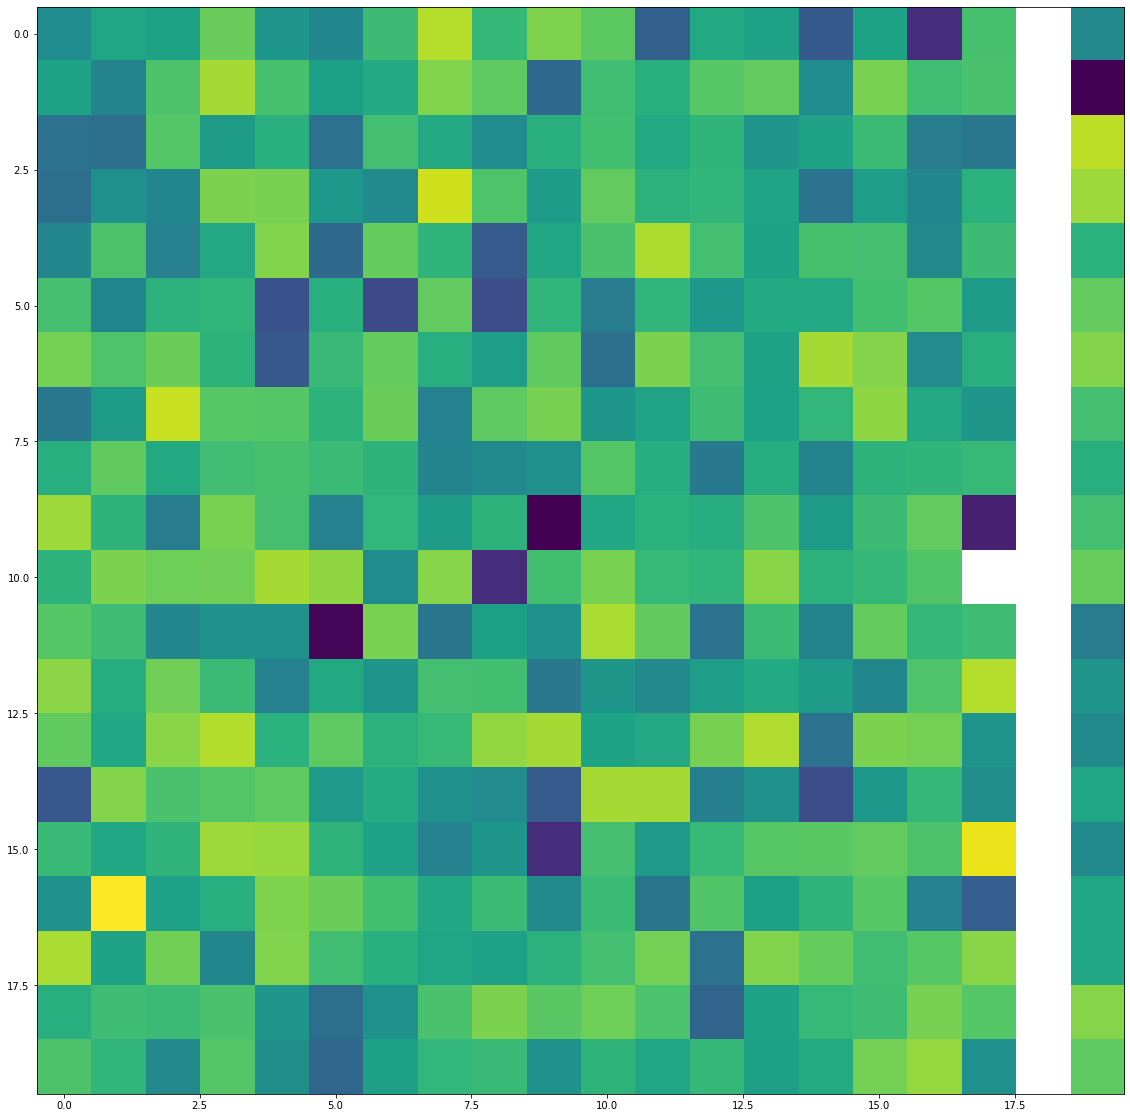

Masked:


/tmp/ipykernel_621655/3237019885.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(submat))


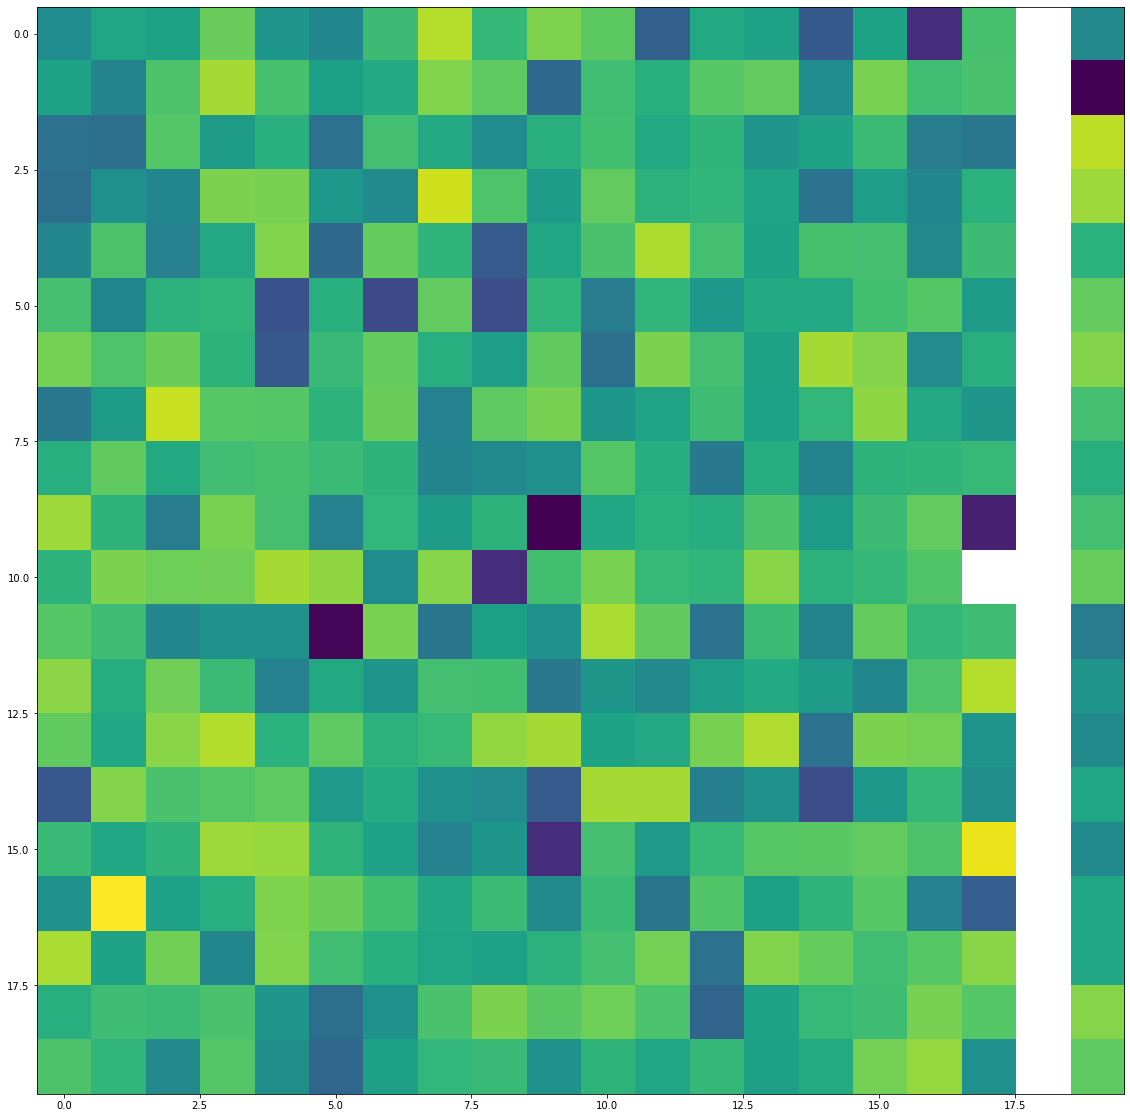

Resized:


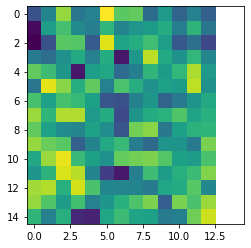

Region1 Region3
(20, 20)


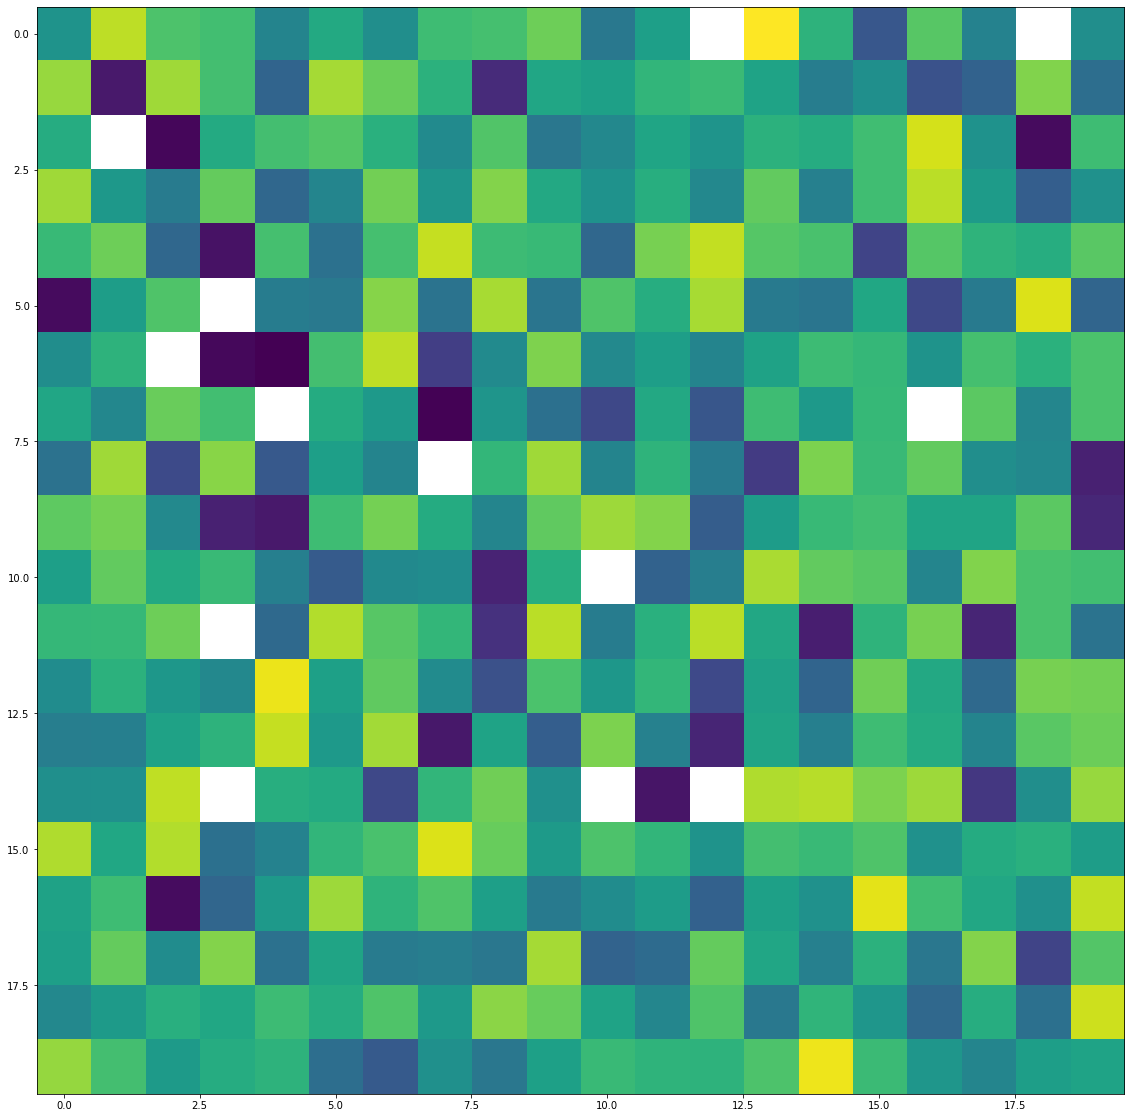

Masked:


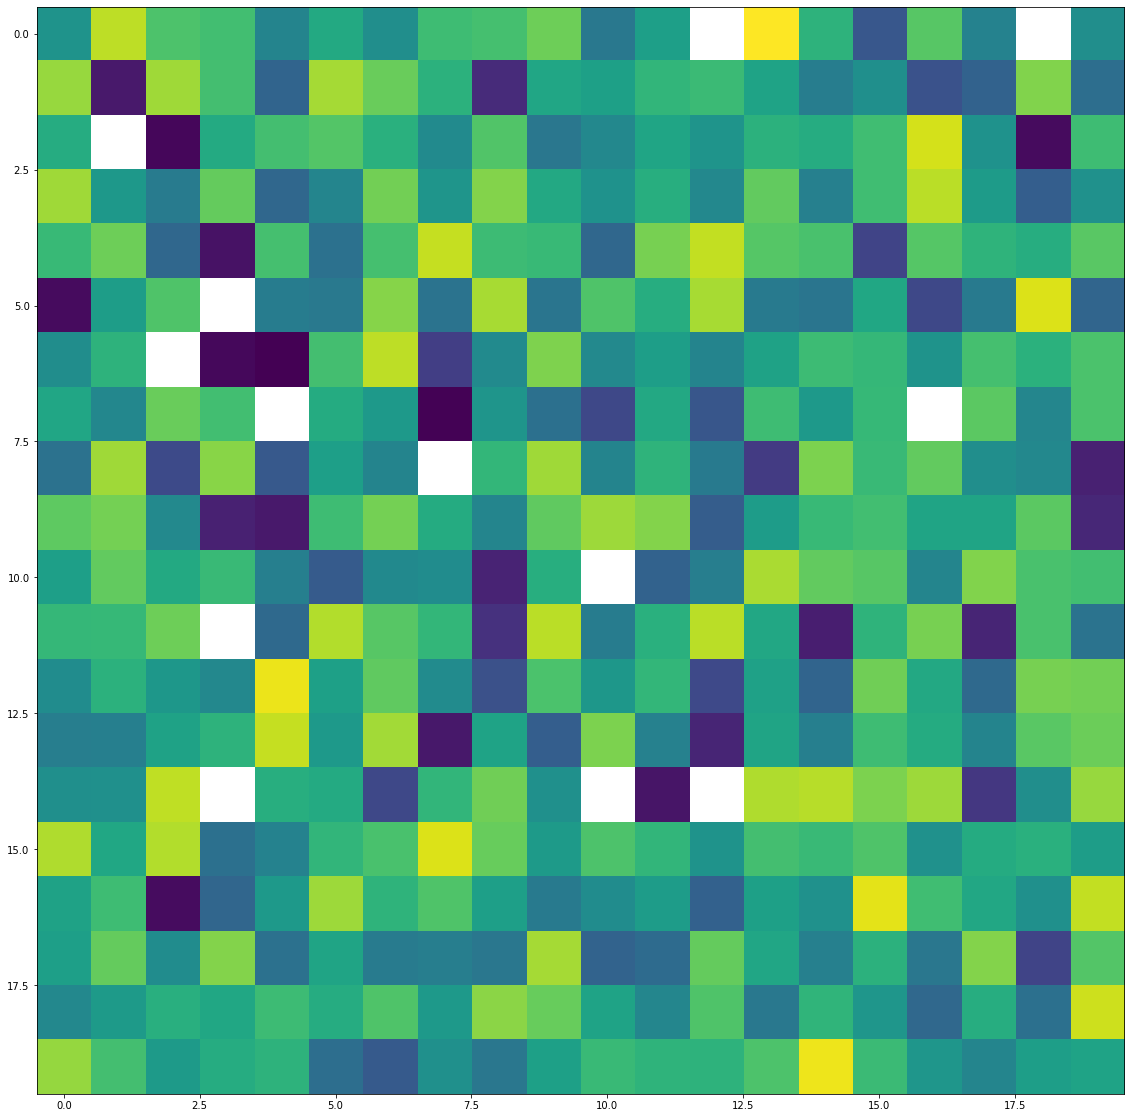

Resized:


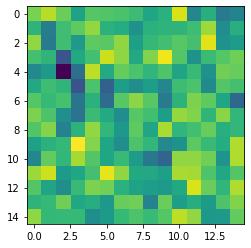

Region1 Region4
(20, 20)


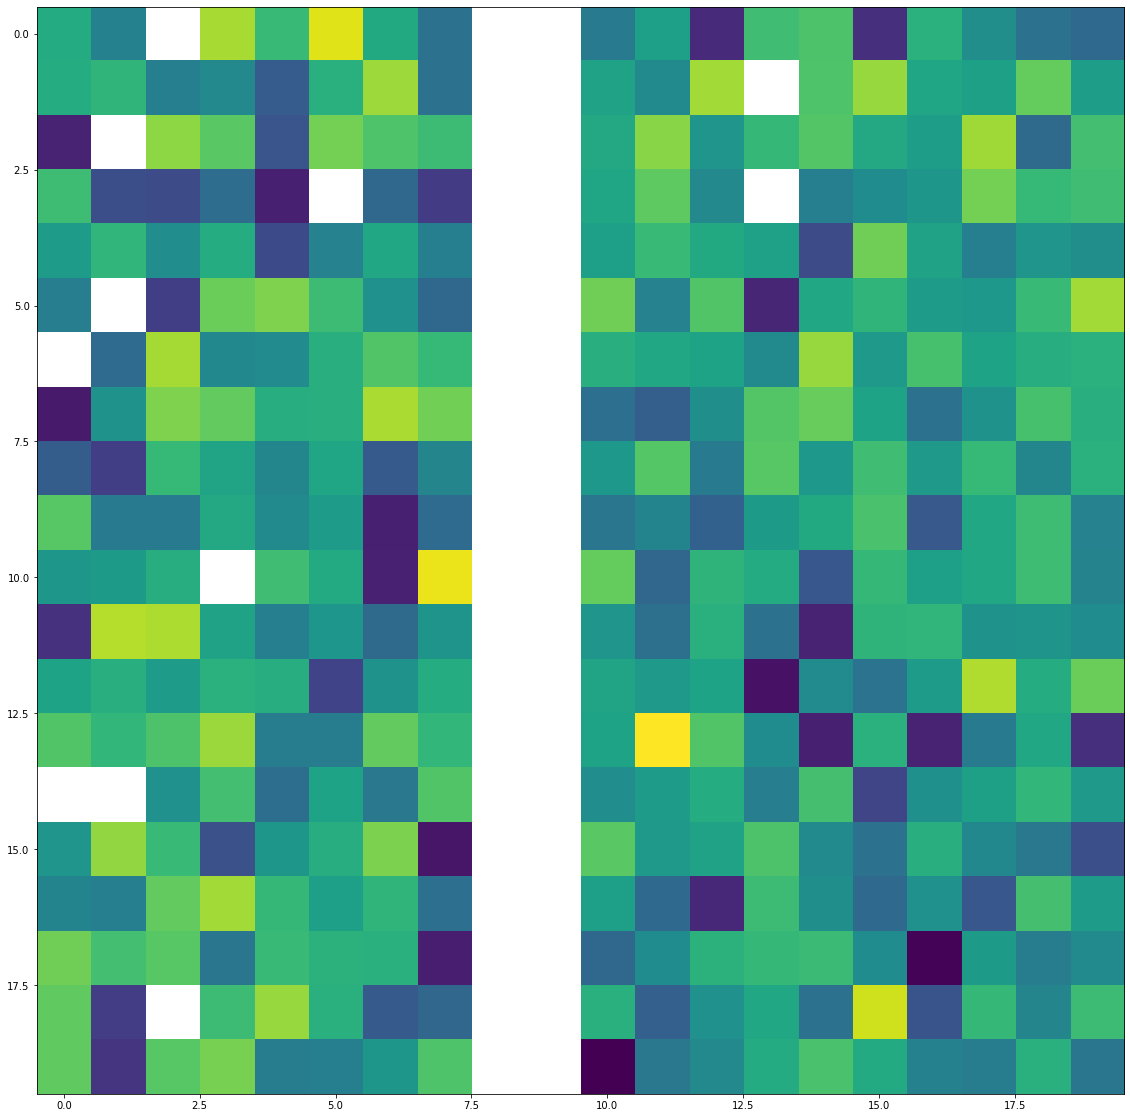

Masked:


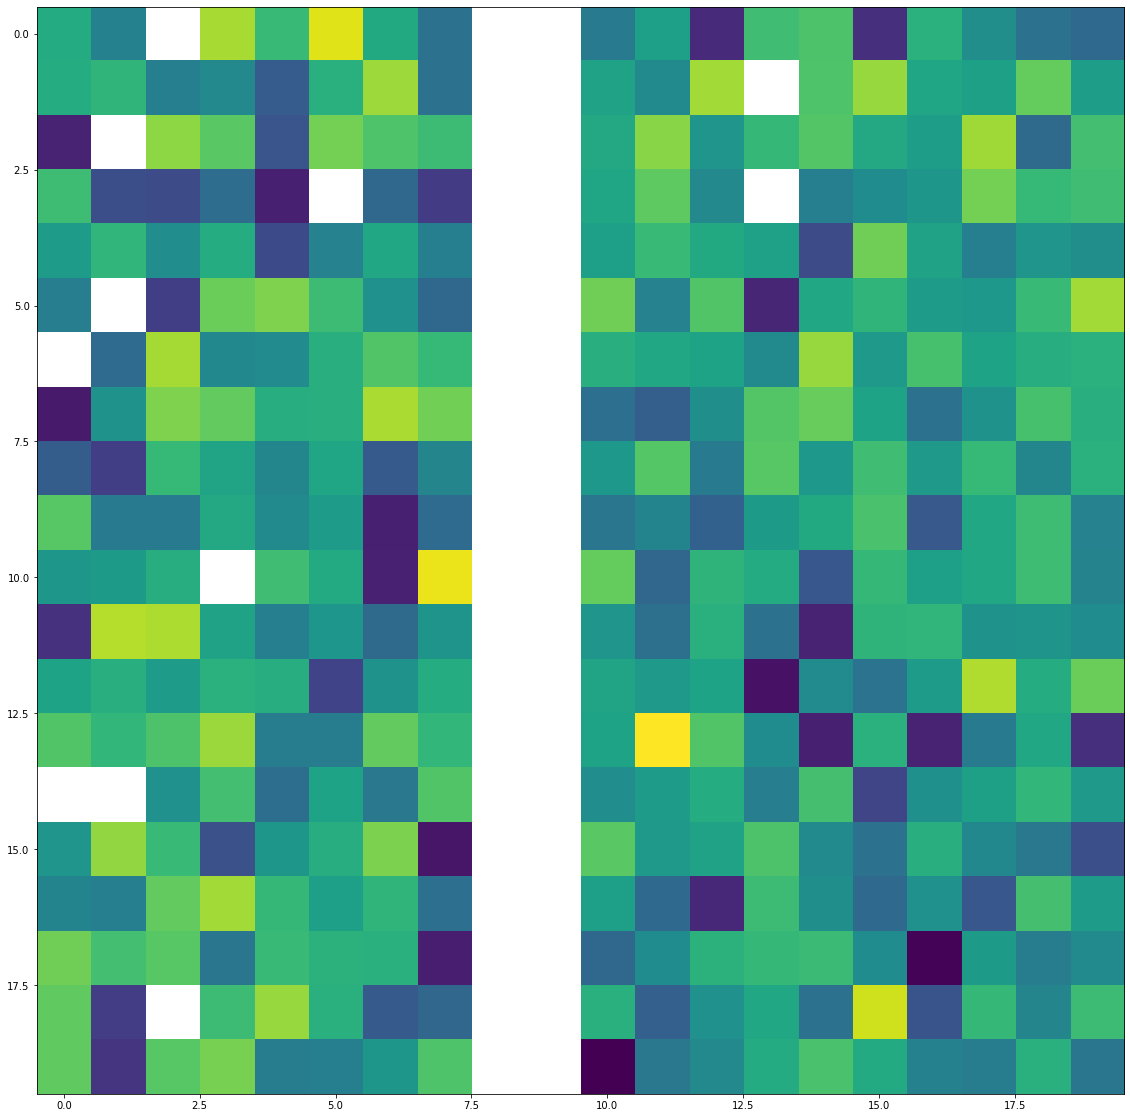

Resized:


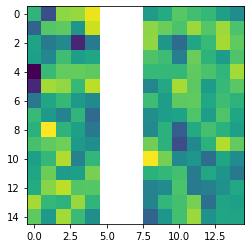

Region1 Region5
(20, 20)


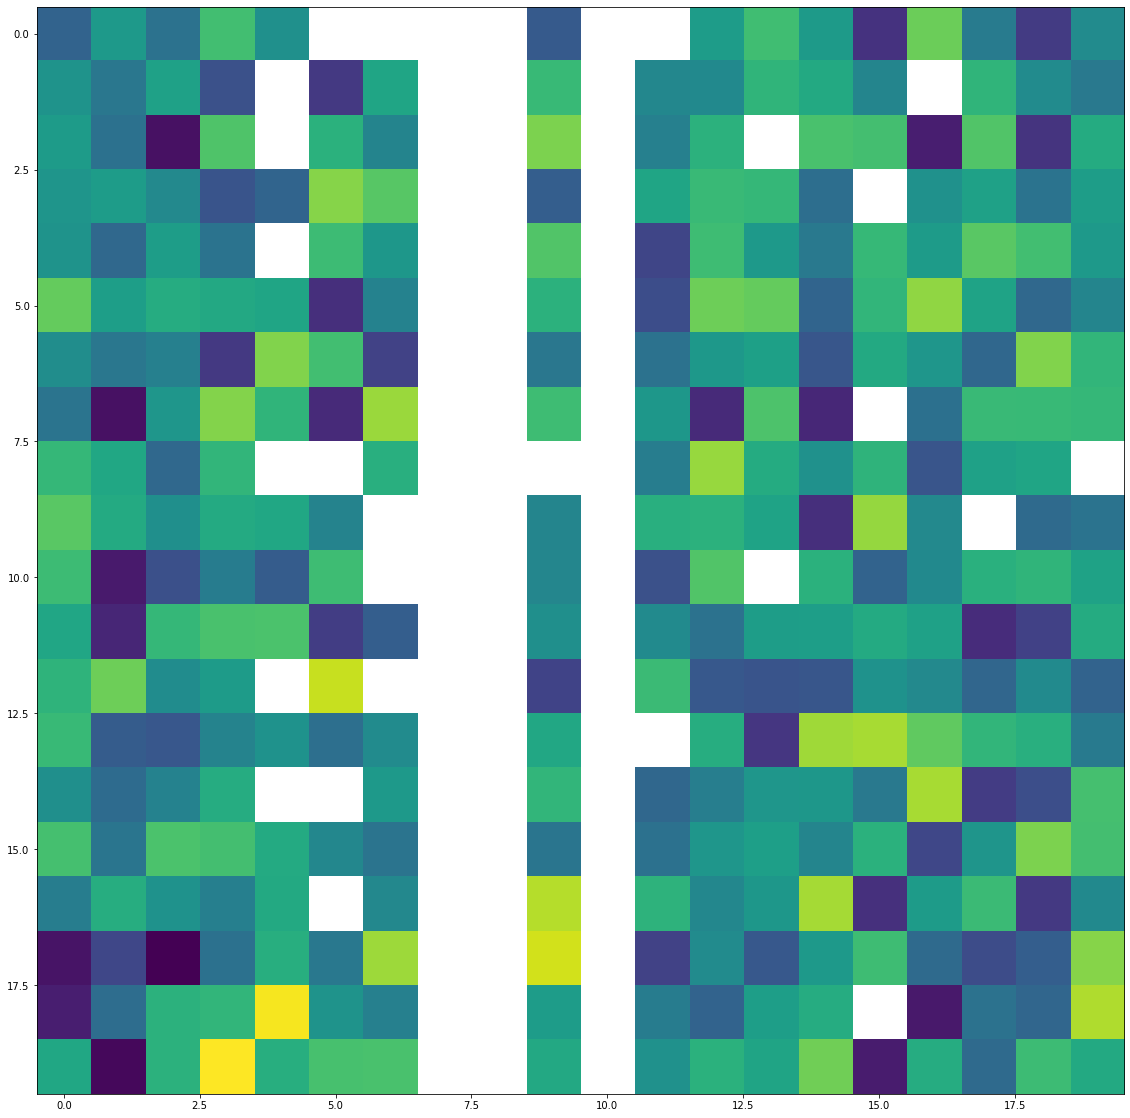

Masked:


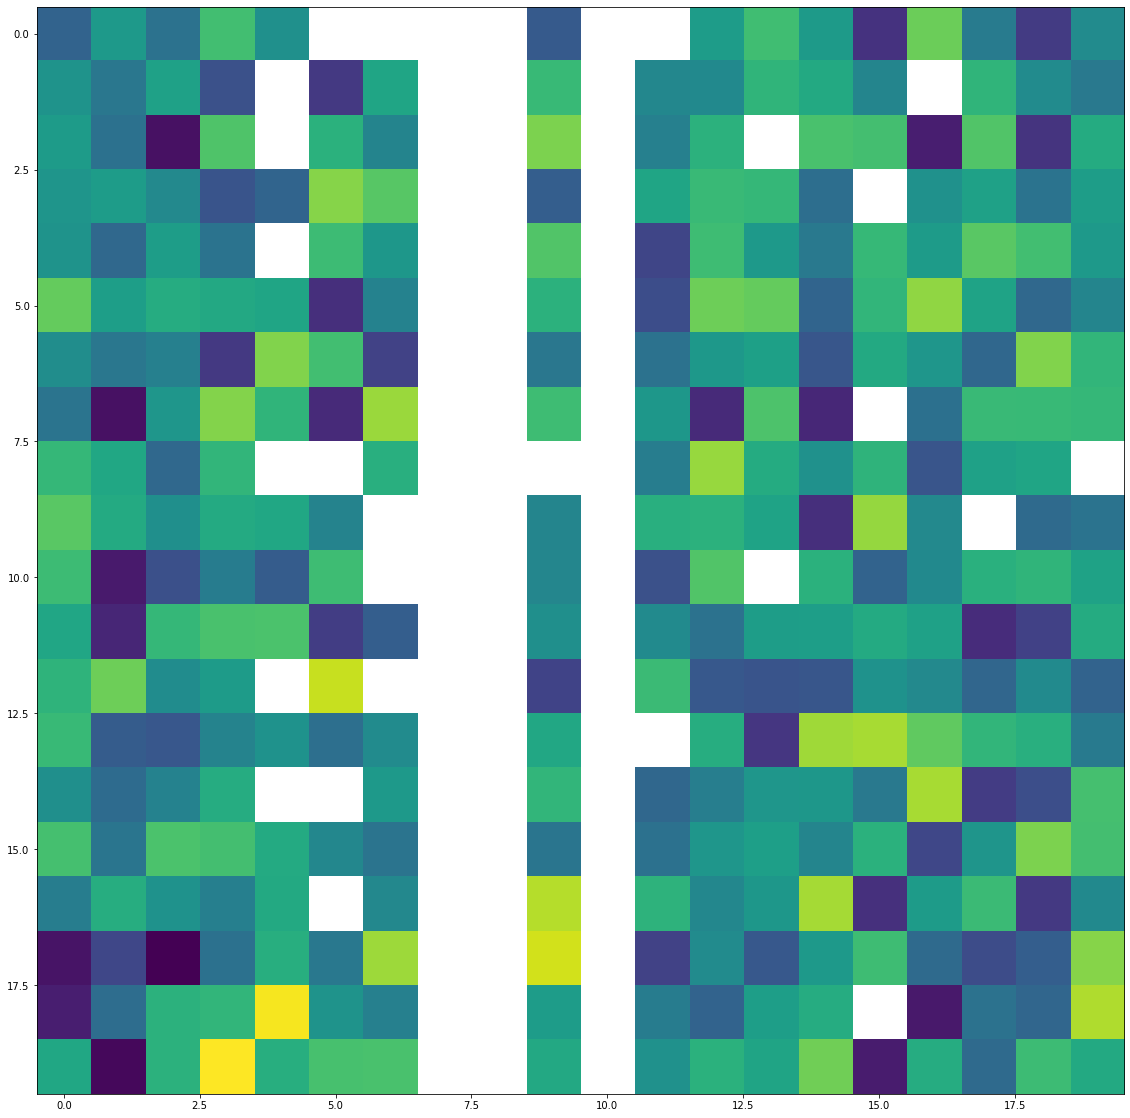

Resized:


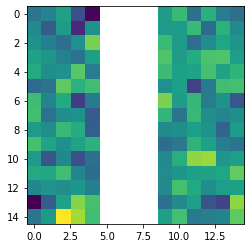

Region2 Region1
(20, 20)


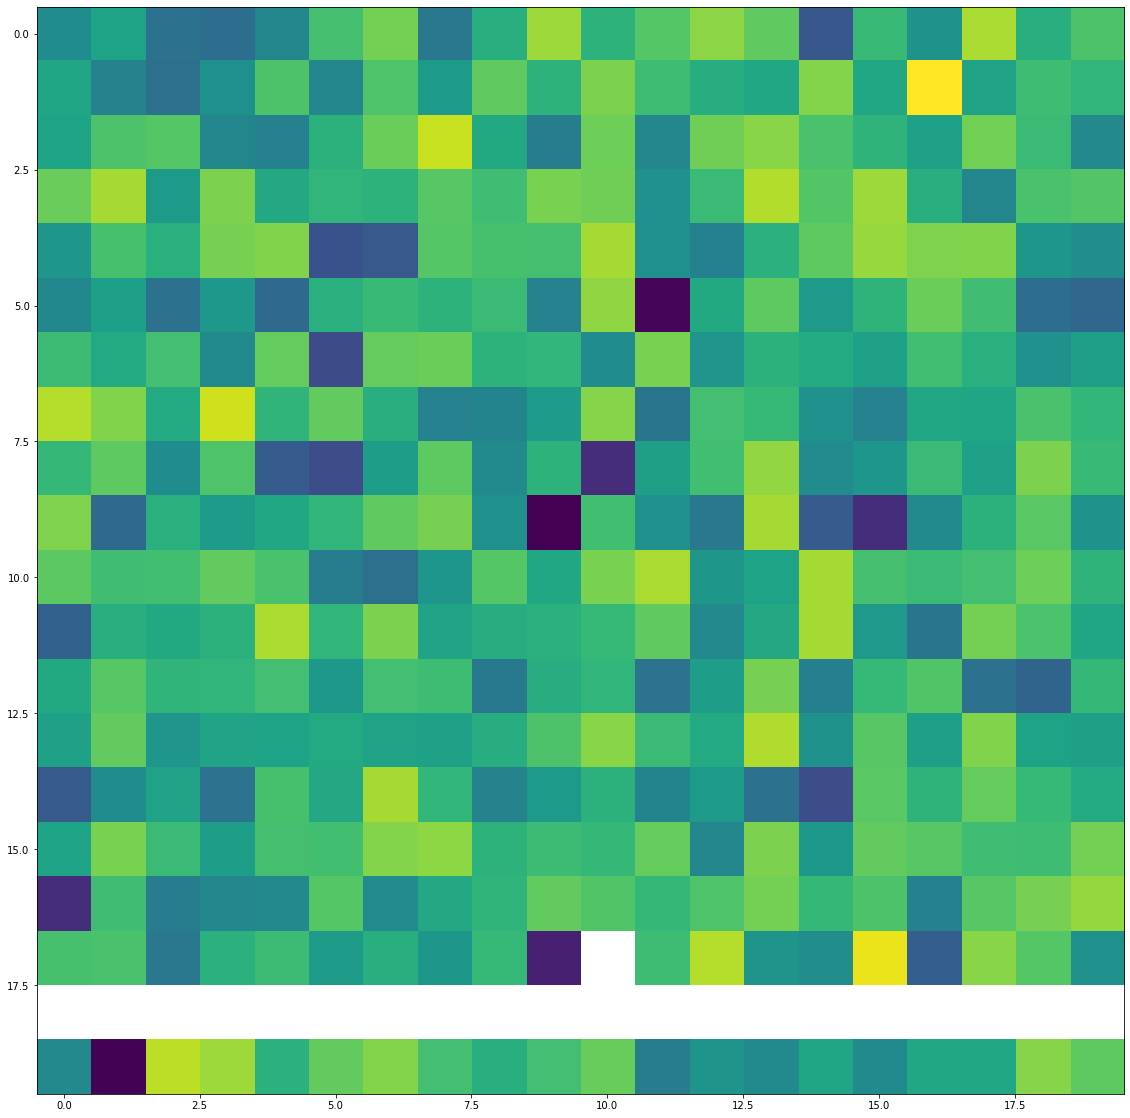

Masked:


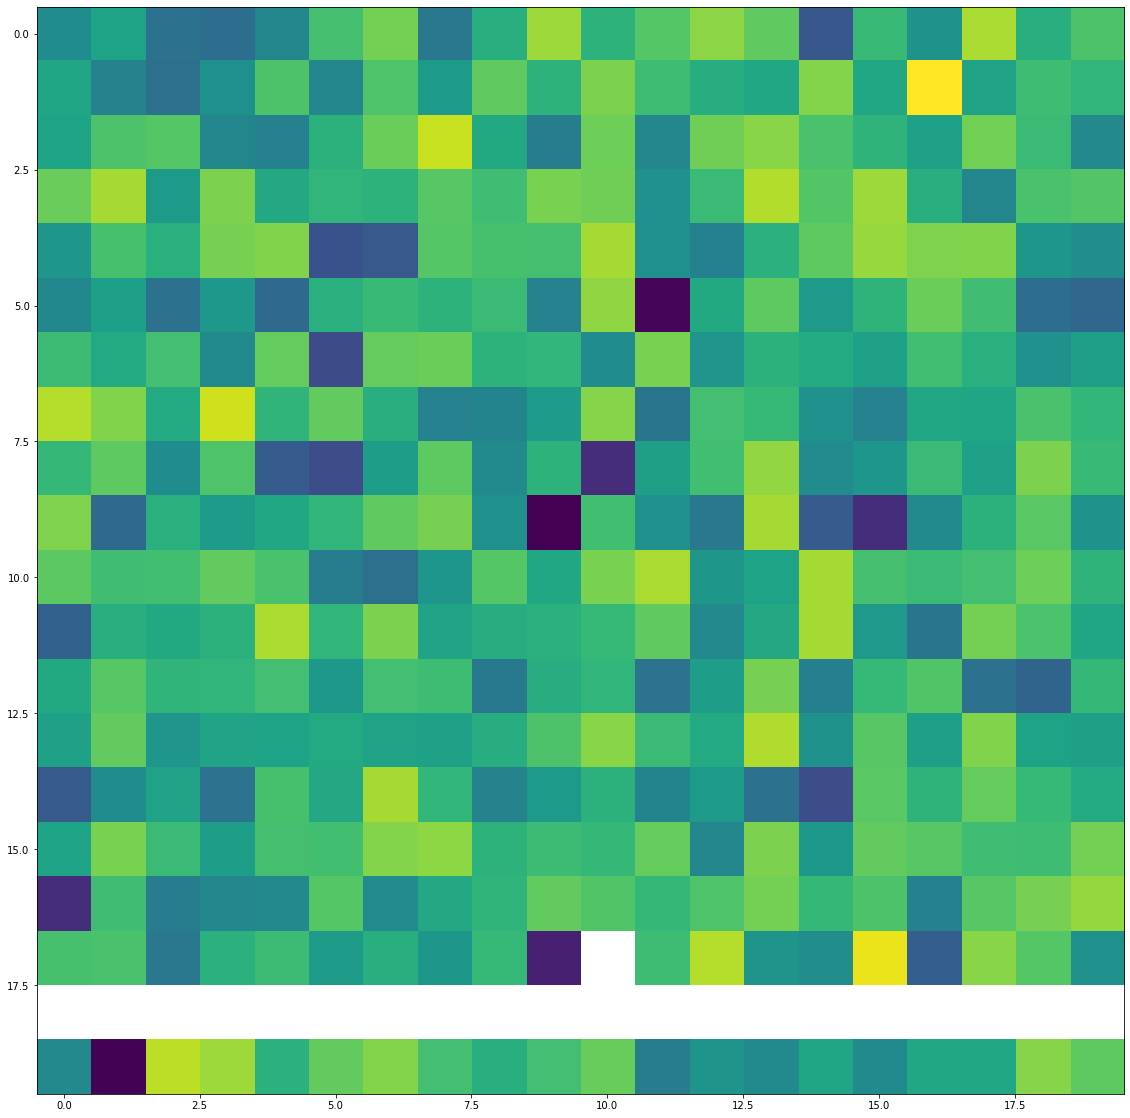

Resized:


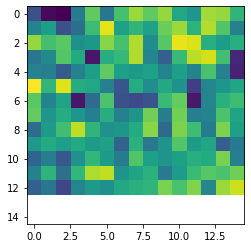

Region2 Region2
(20, 20)


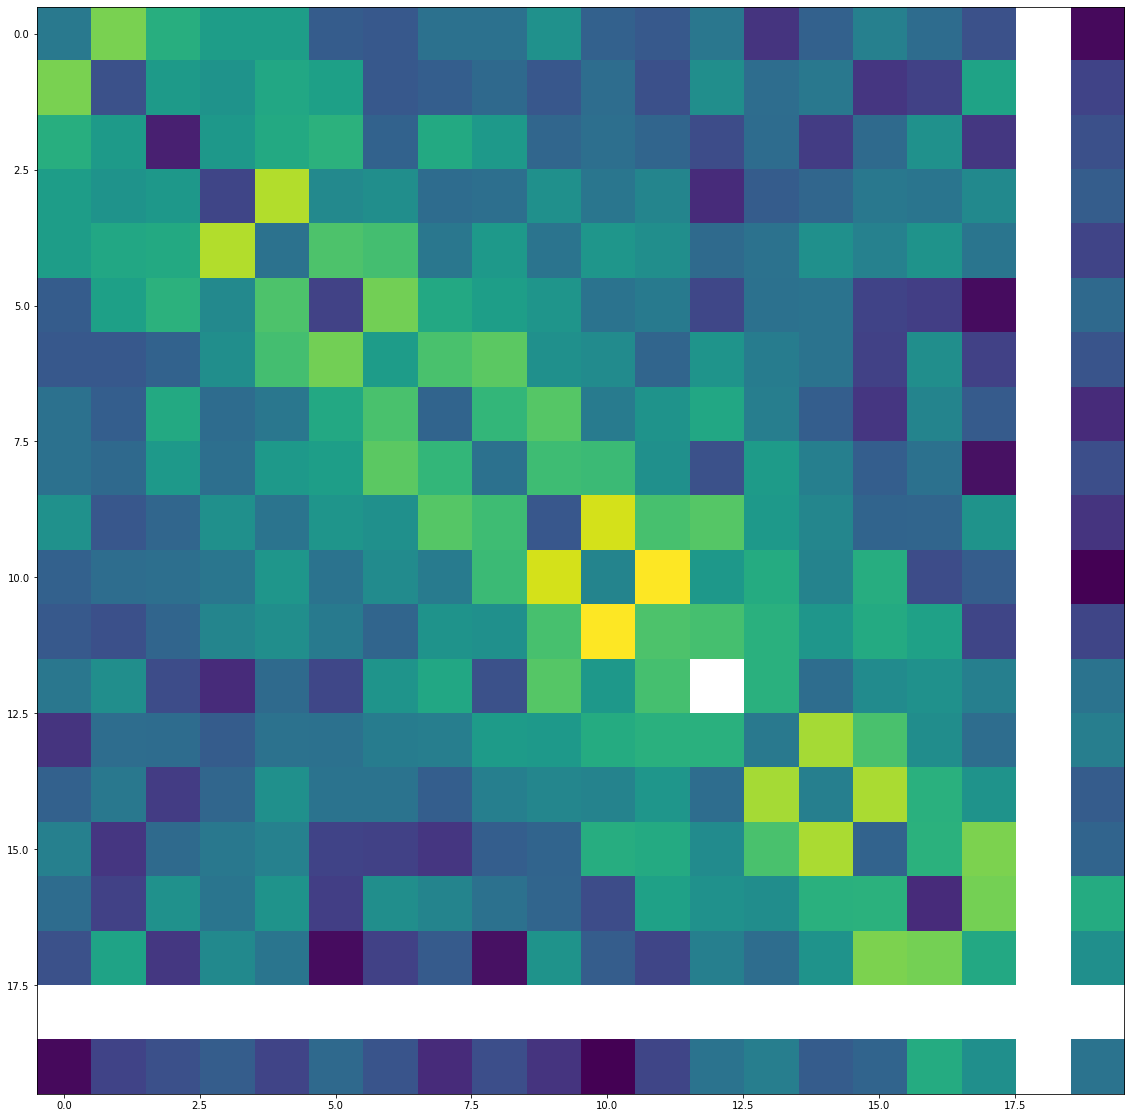

Masked:


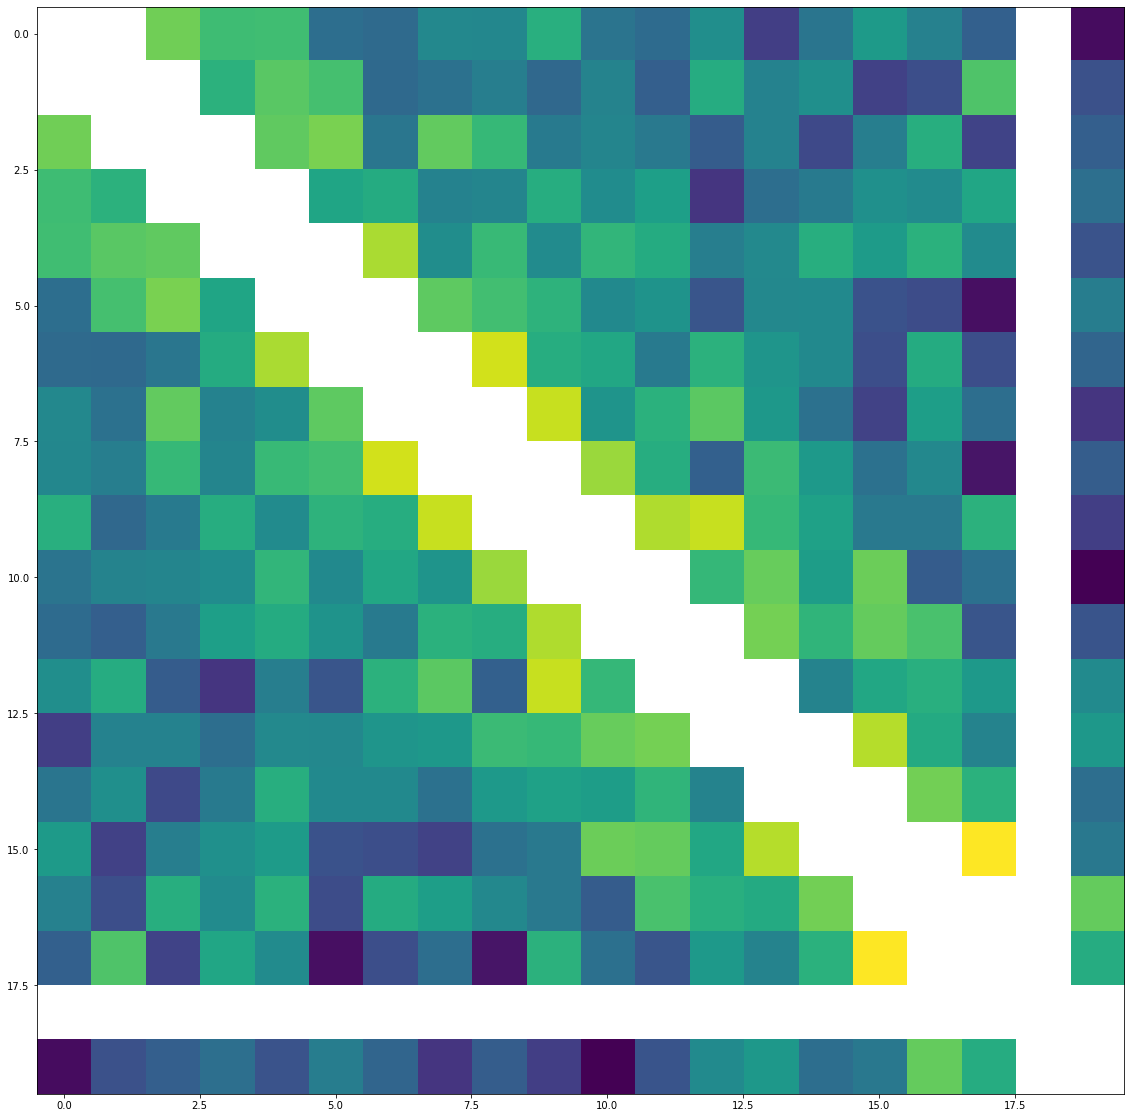

Resized:


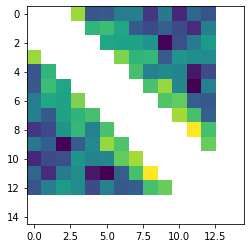

Region2 Region3
(20, 20)


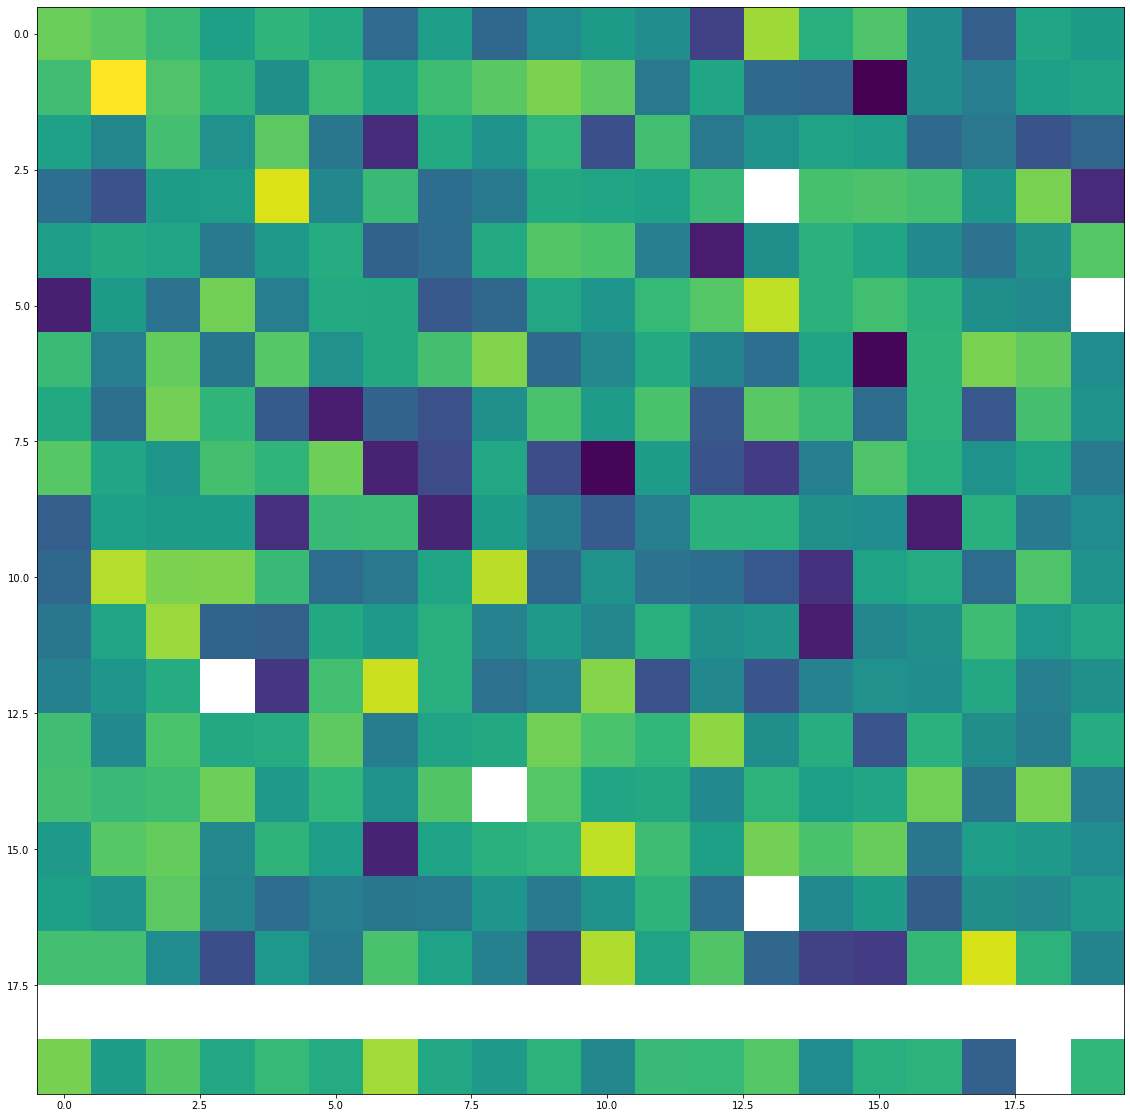

Masked:


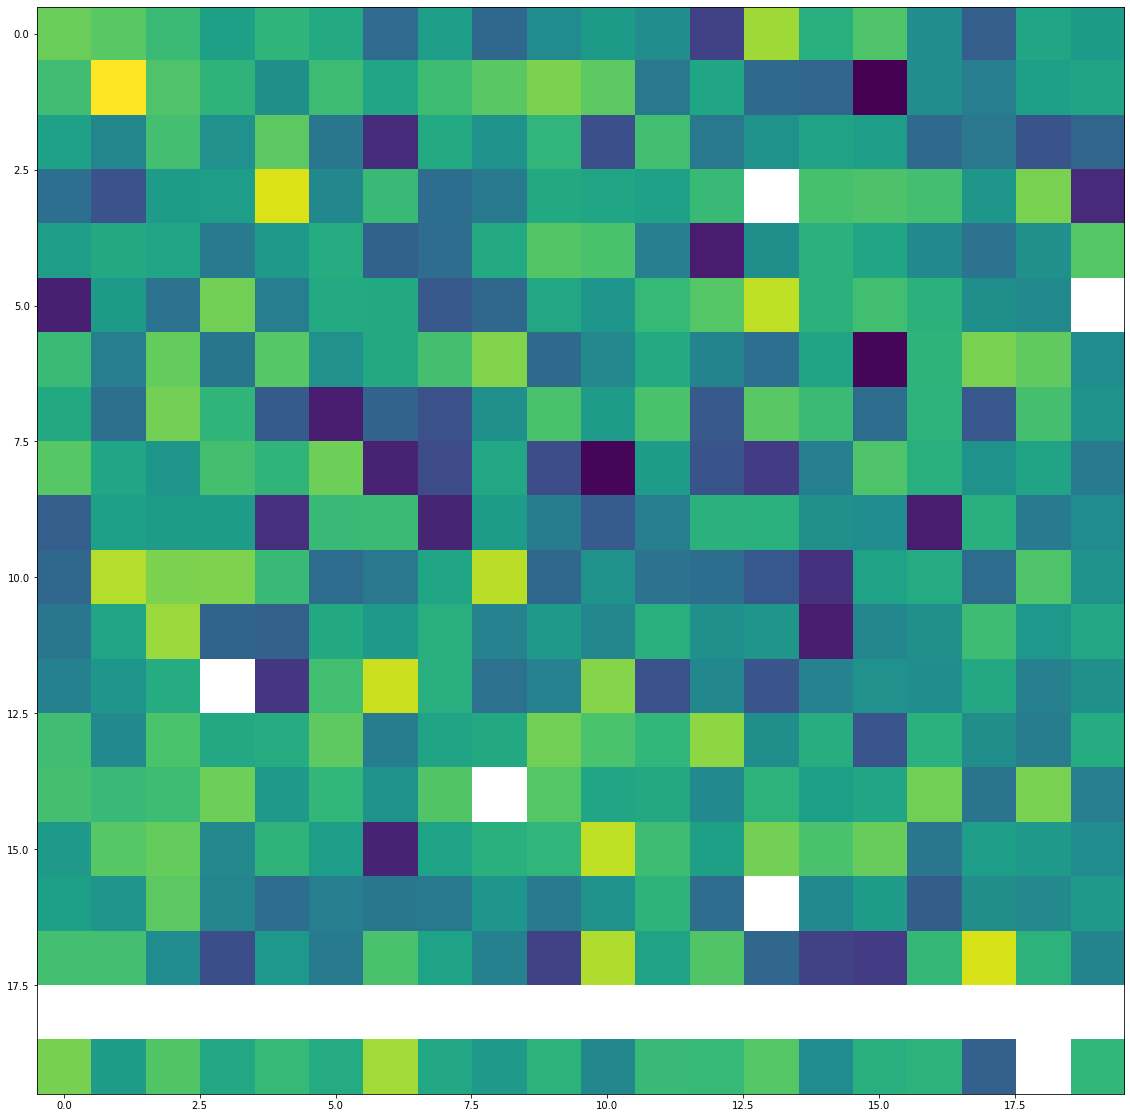

Resized:


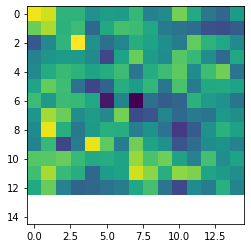

Region2 Region4
(20, 20)


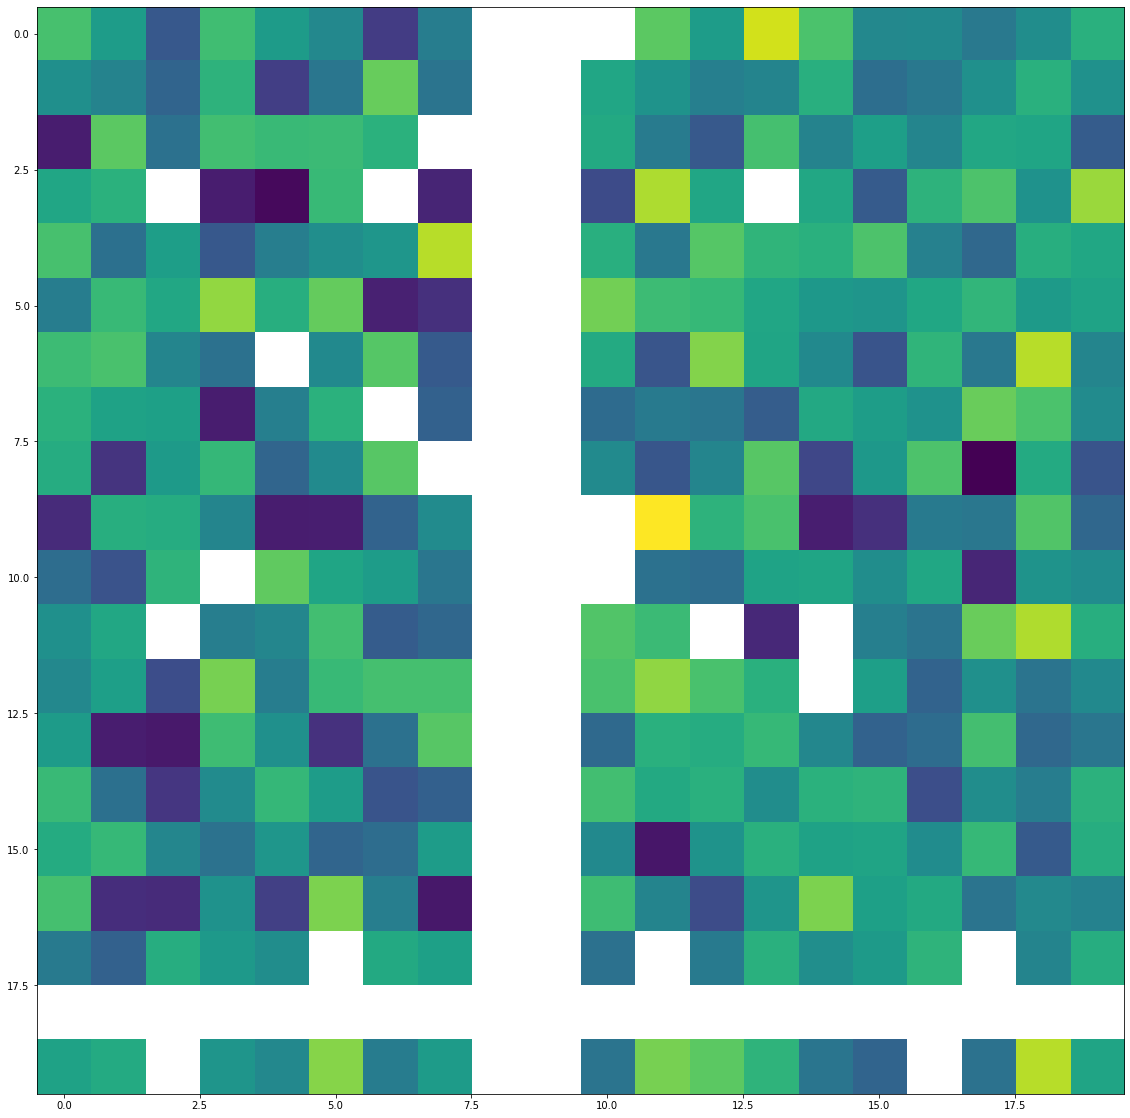

Masked:


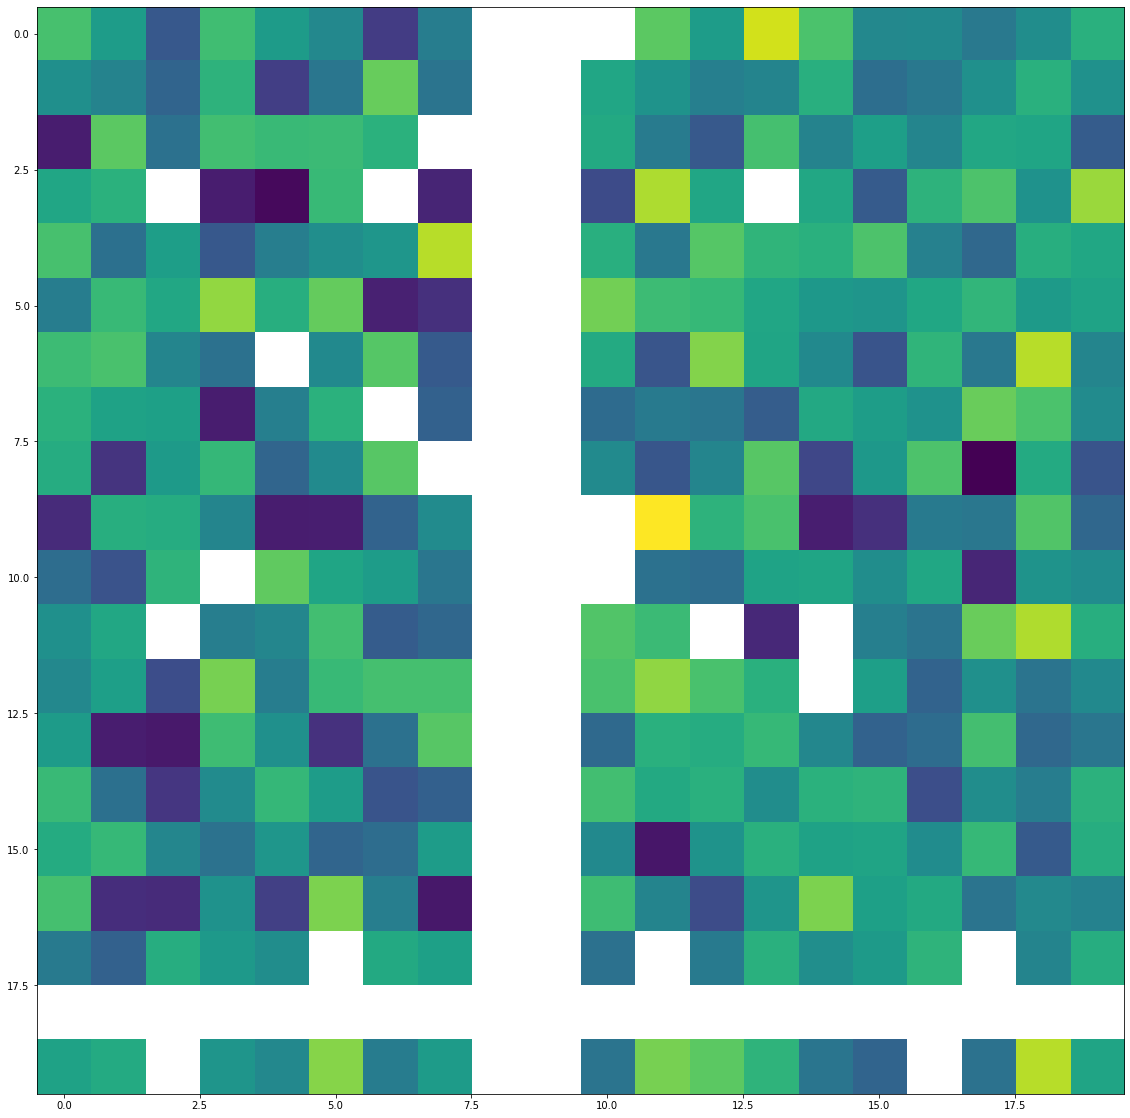

Resized:


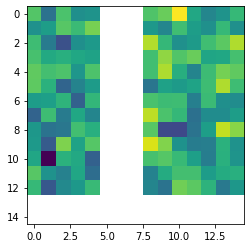

Region2 Region5
(20, 20)


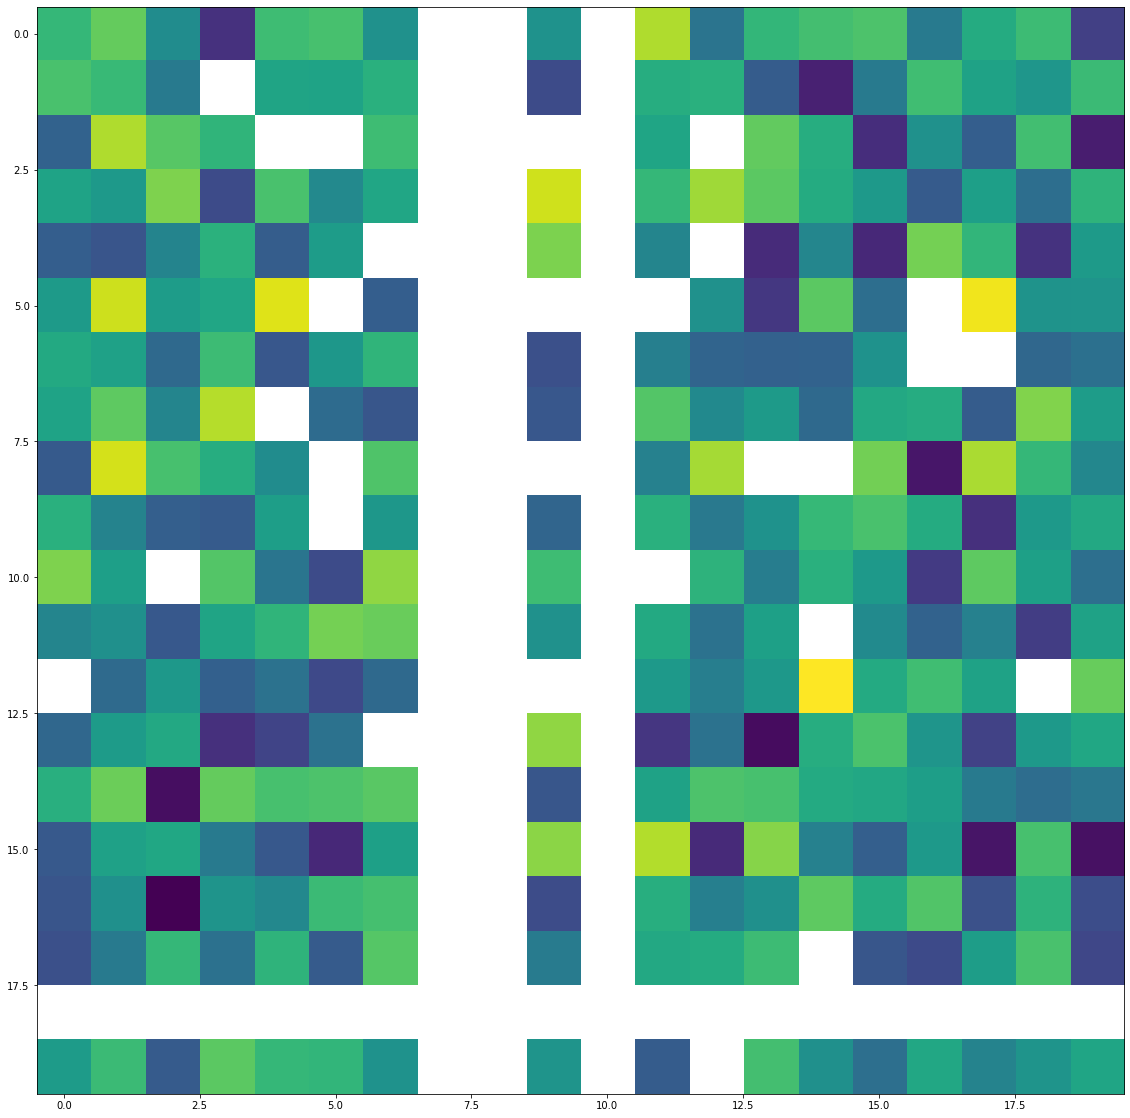

Masked:


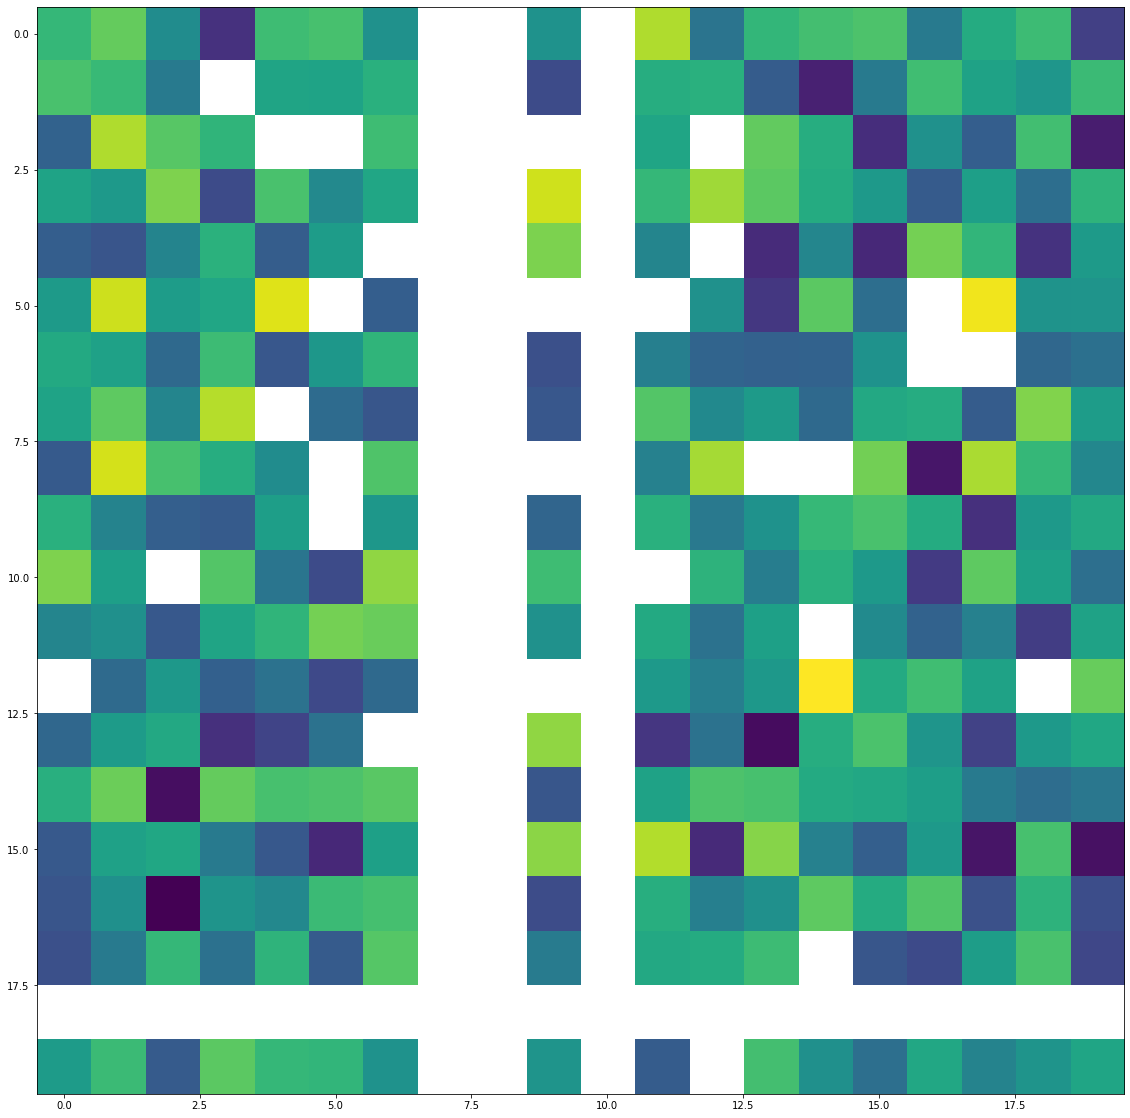

Resized:


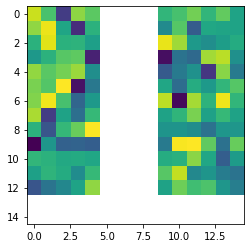

Region3 Region1
(20, 20)


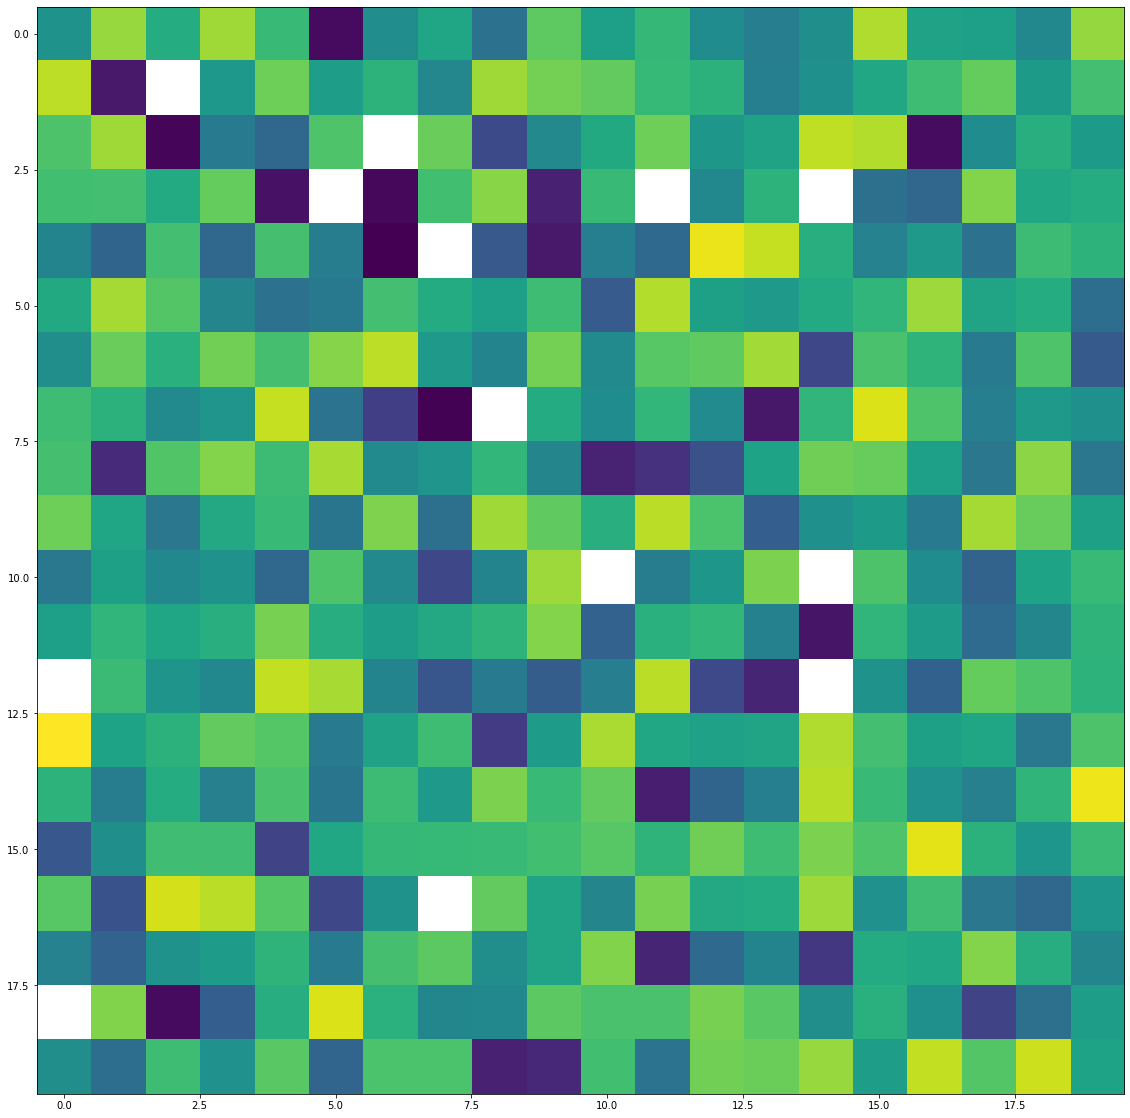

Masked:


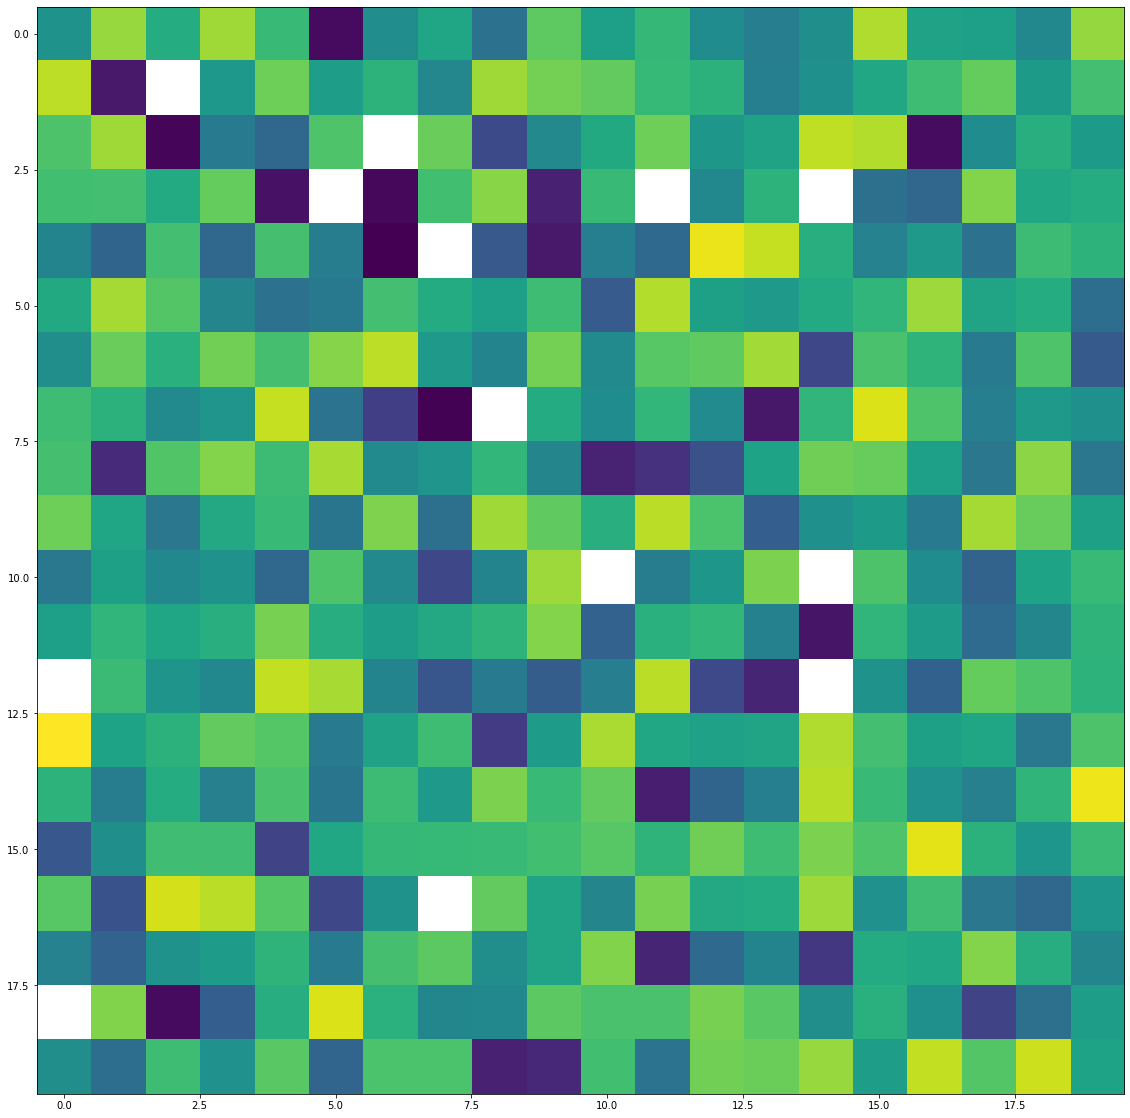

Resized:


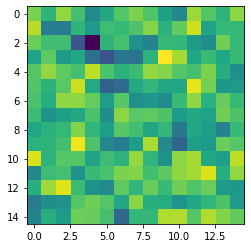

Region3 Region2
(20, 20)


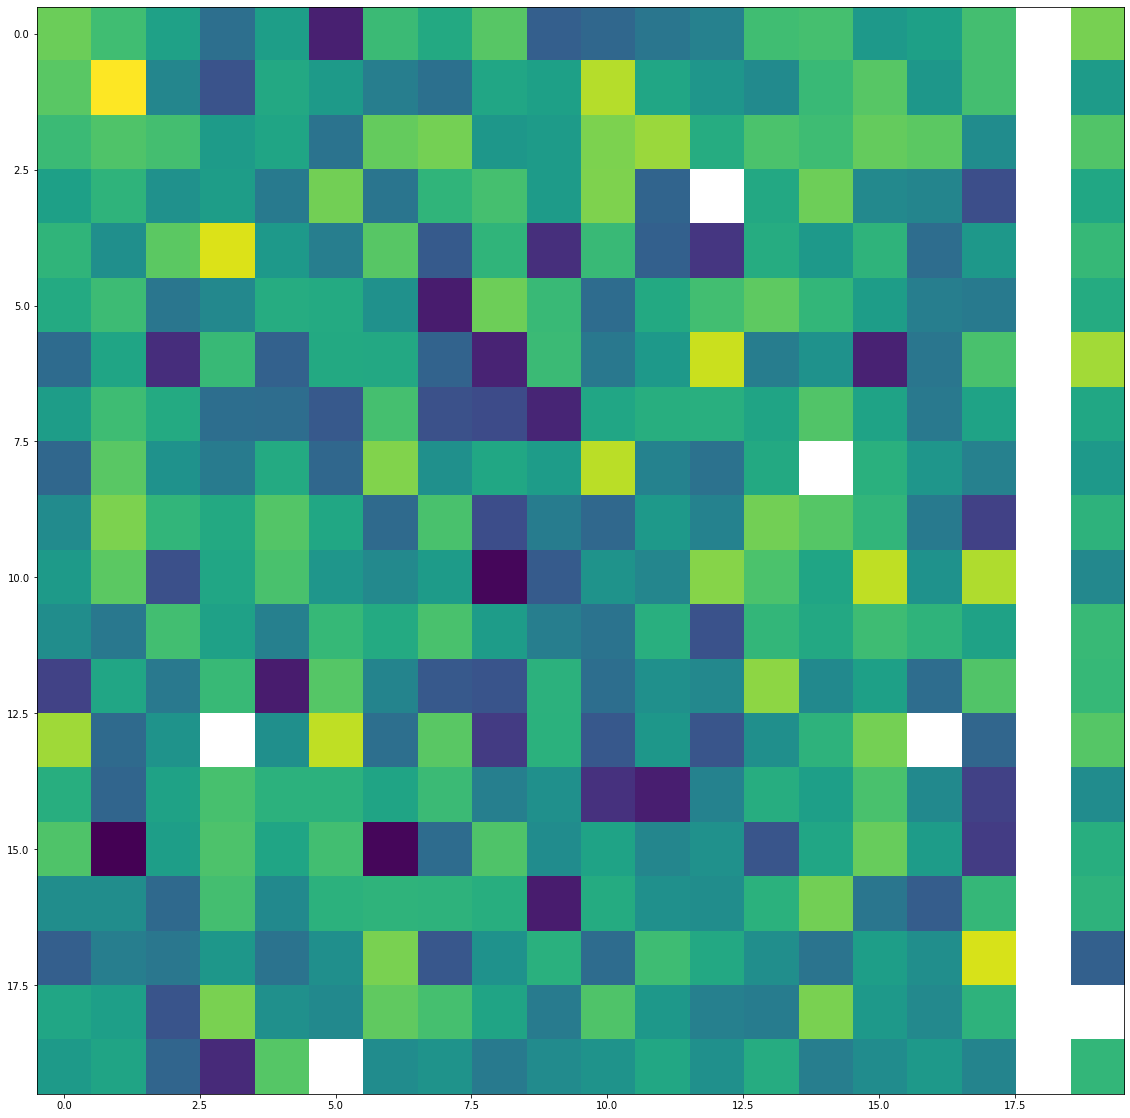

Masked:


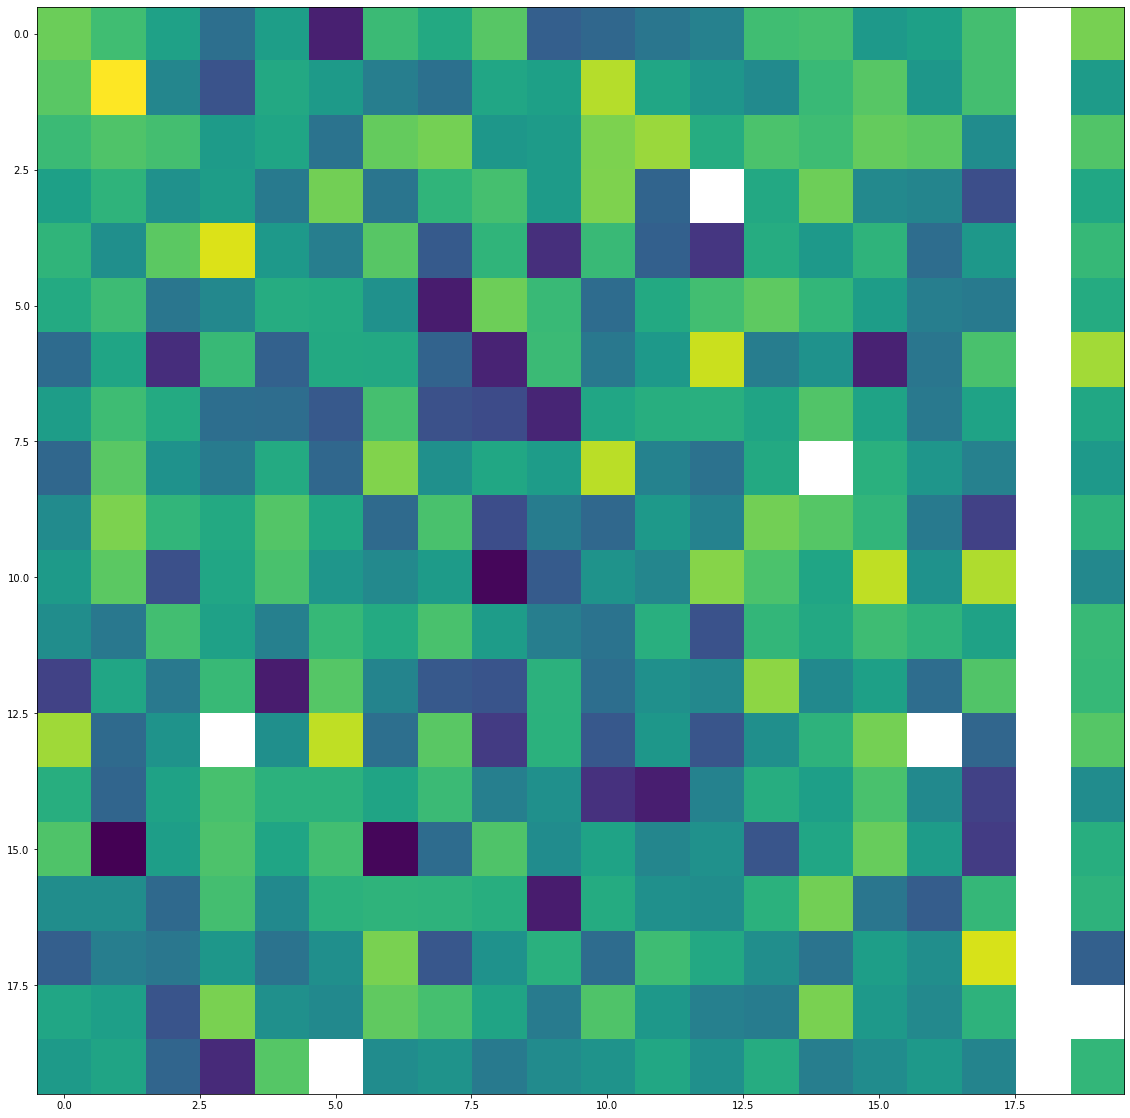

Resized:


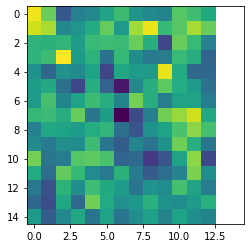

Region3 Region3
(20, 20)


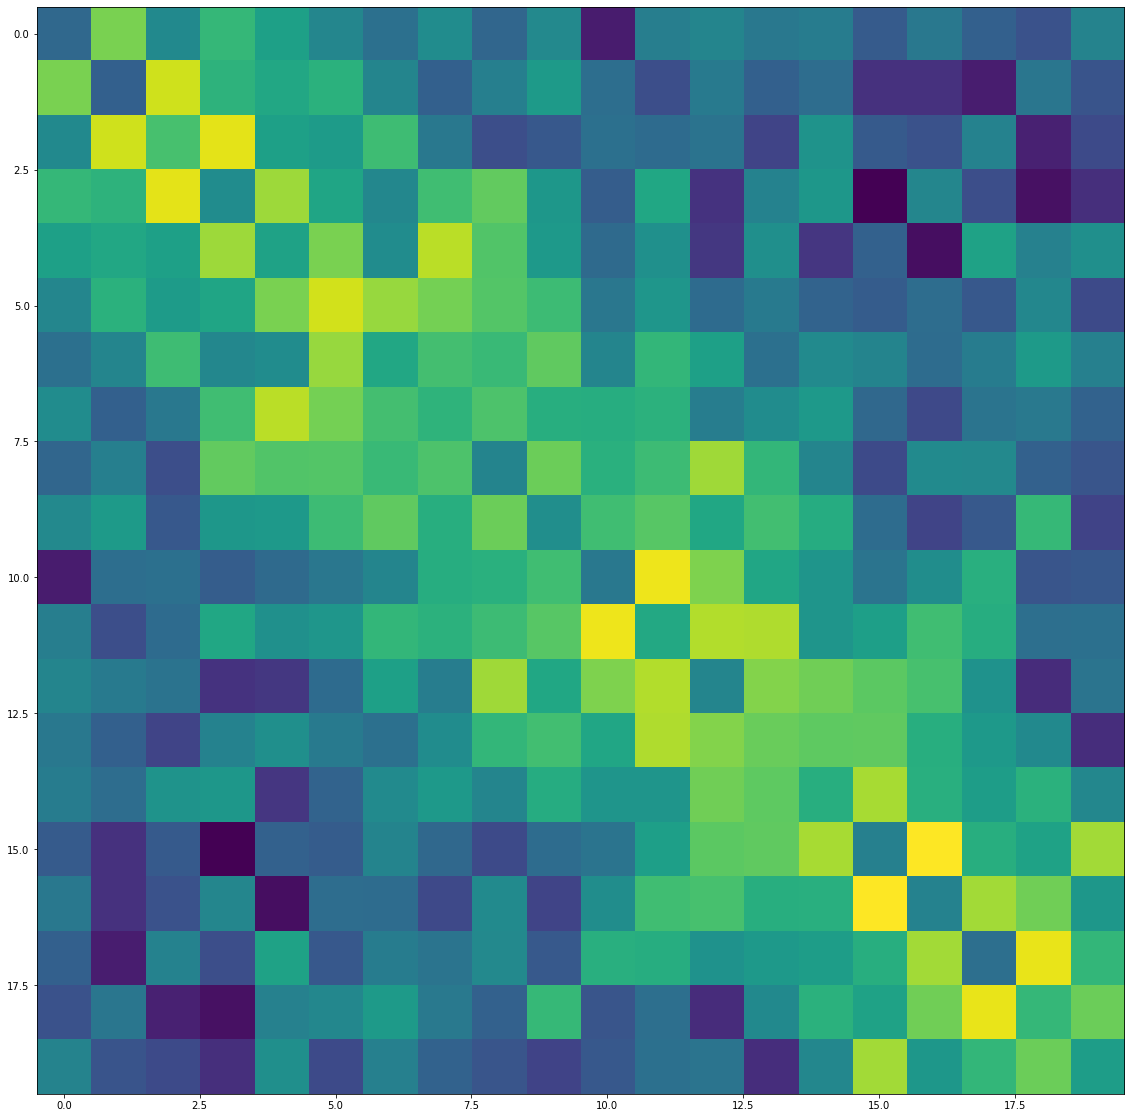

Masked:


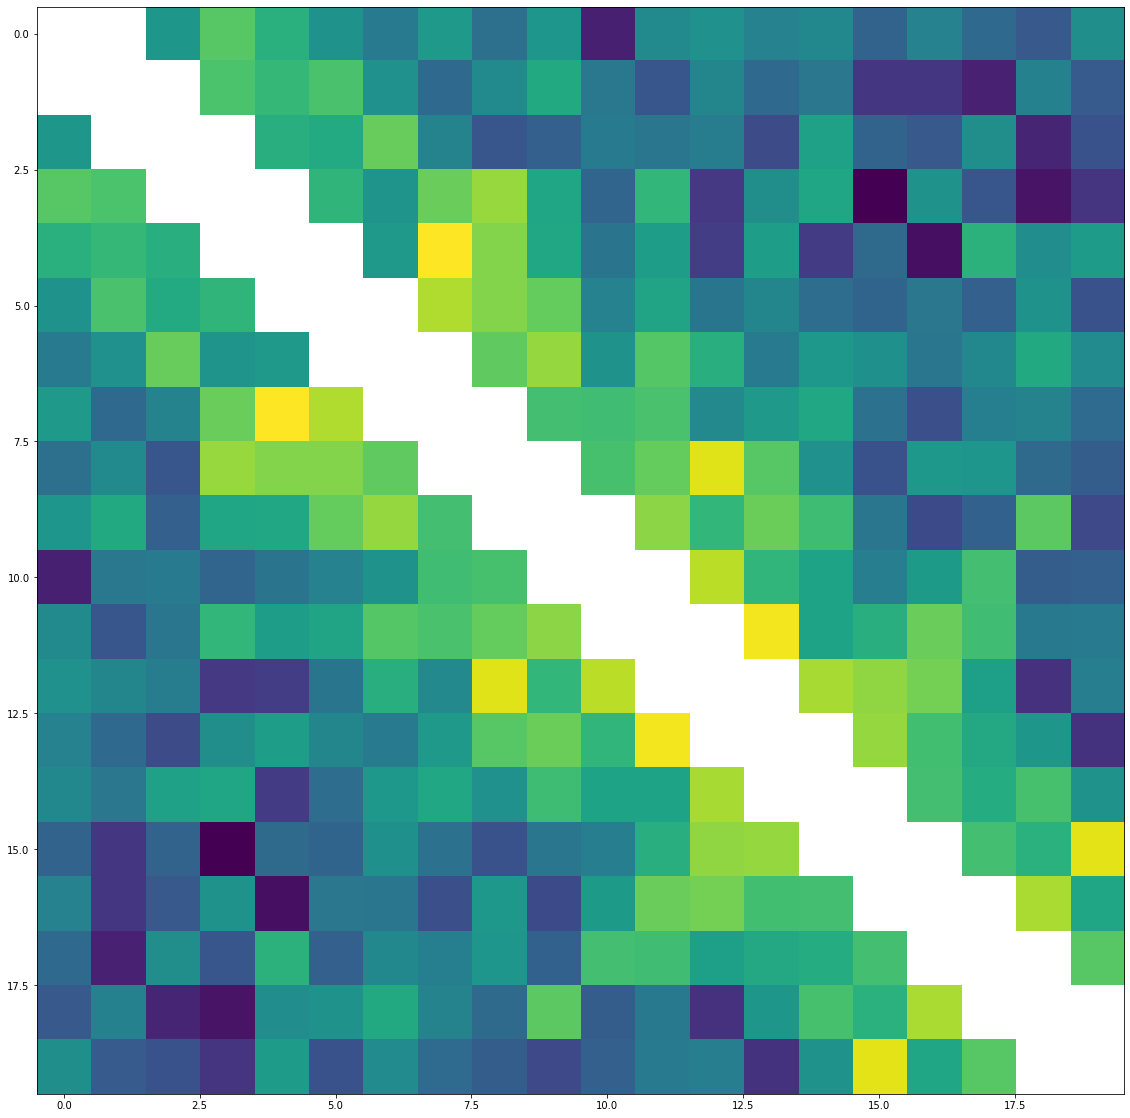

Resized:


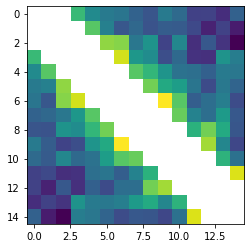

Region3 Region4
(20, 20)


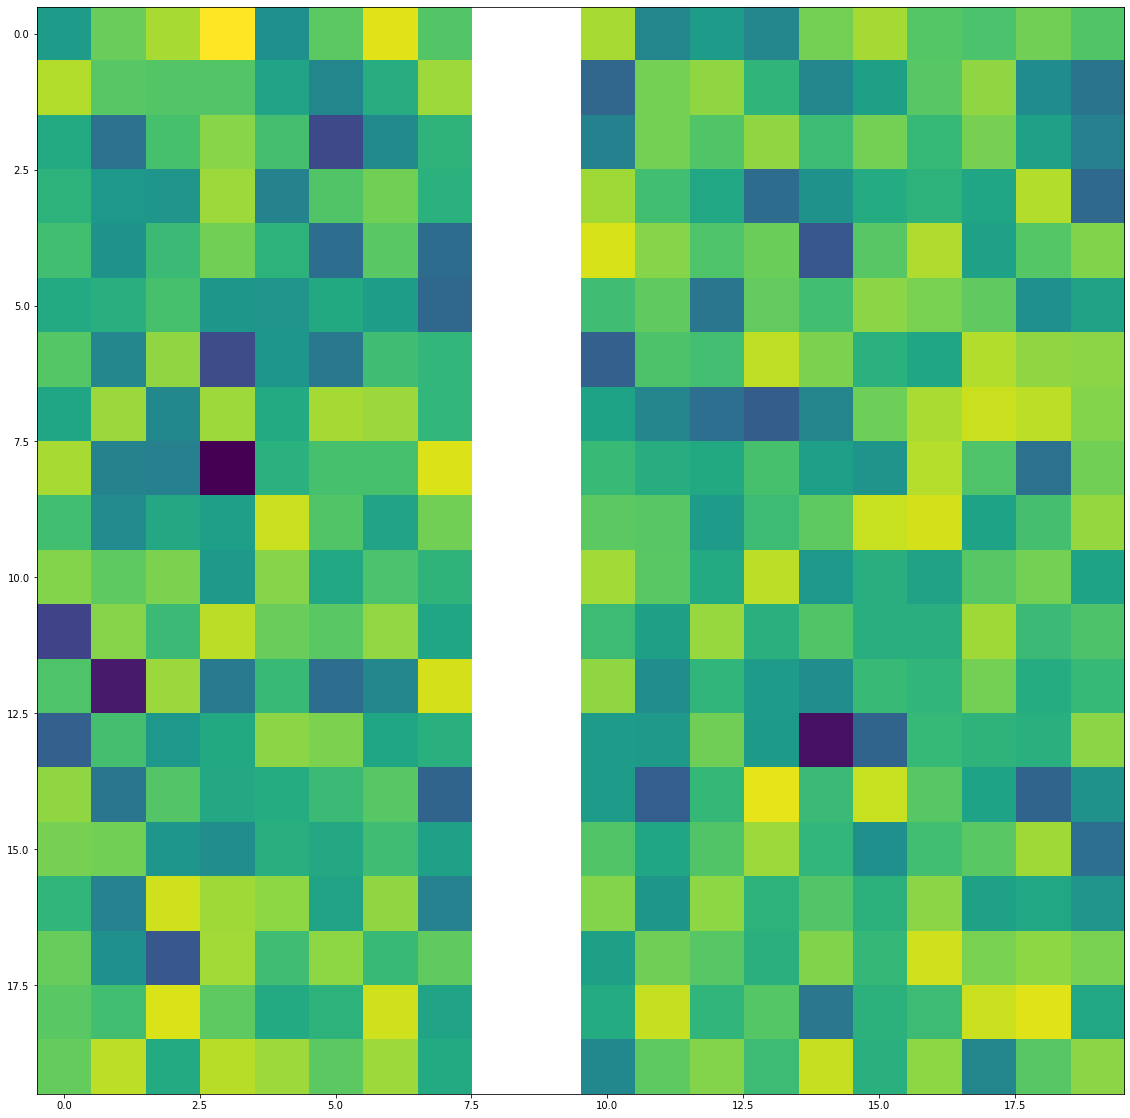

Masked:


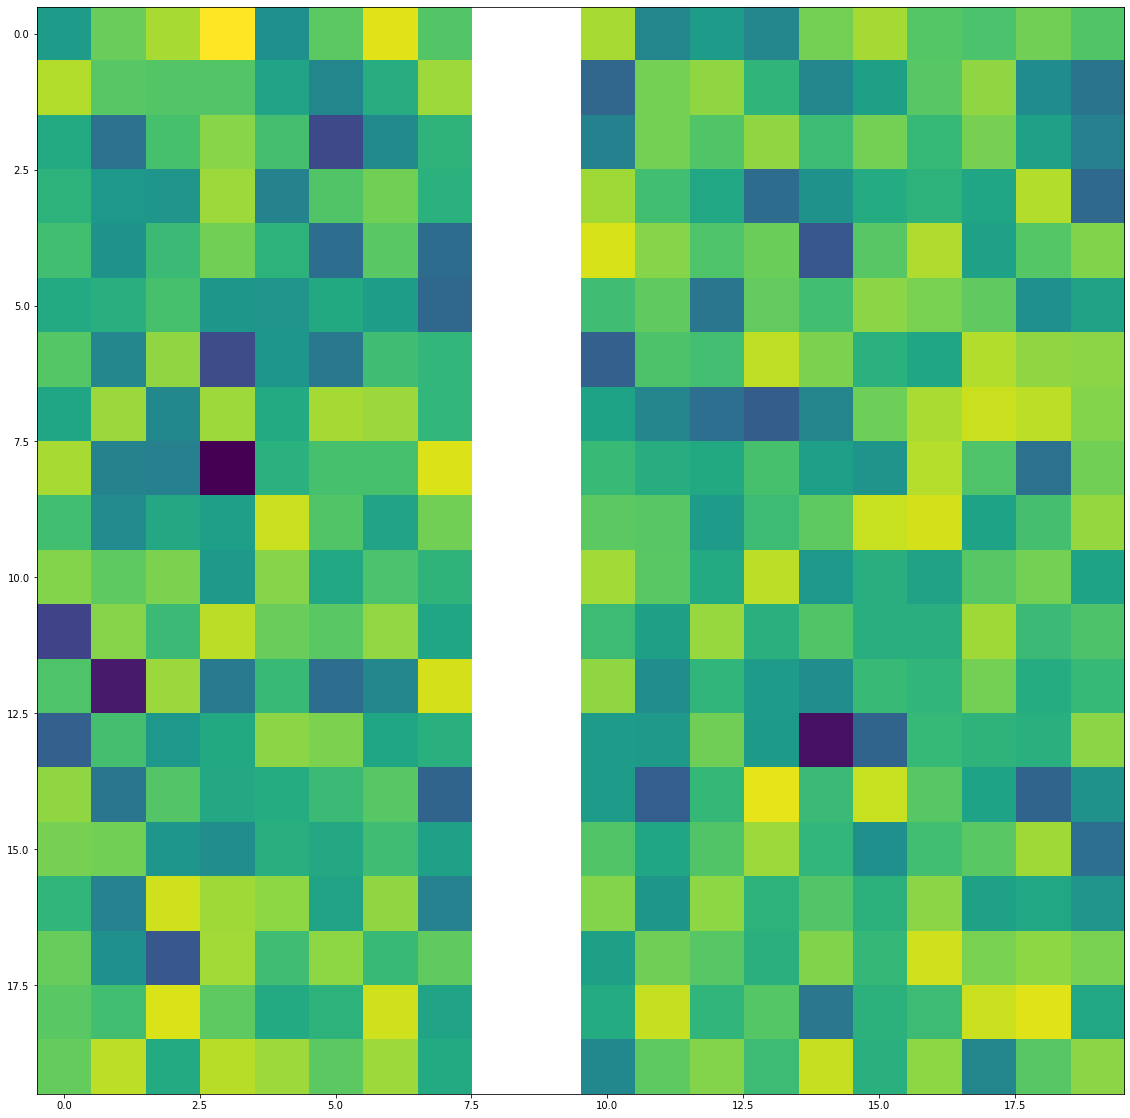

Resized:


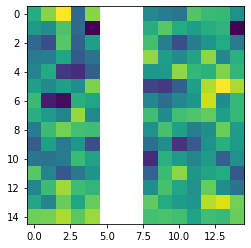

Region3 Region5
(20, 20)


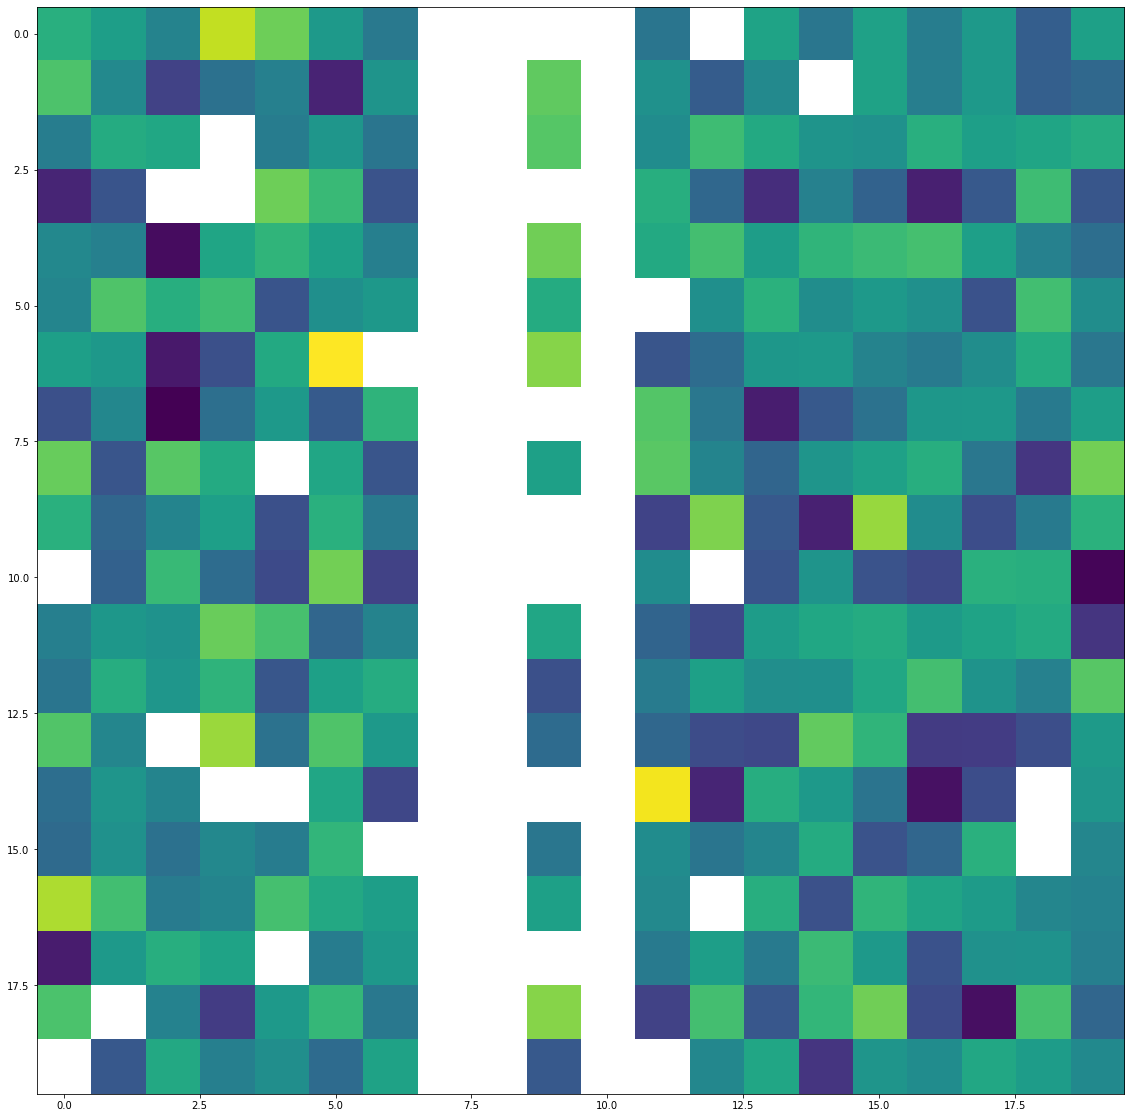

Masked:


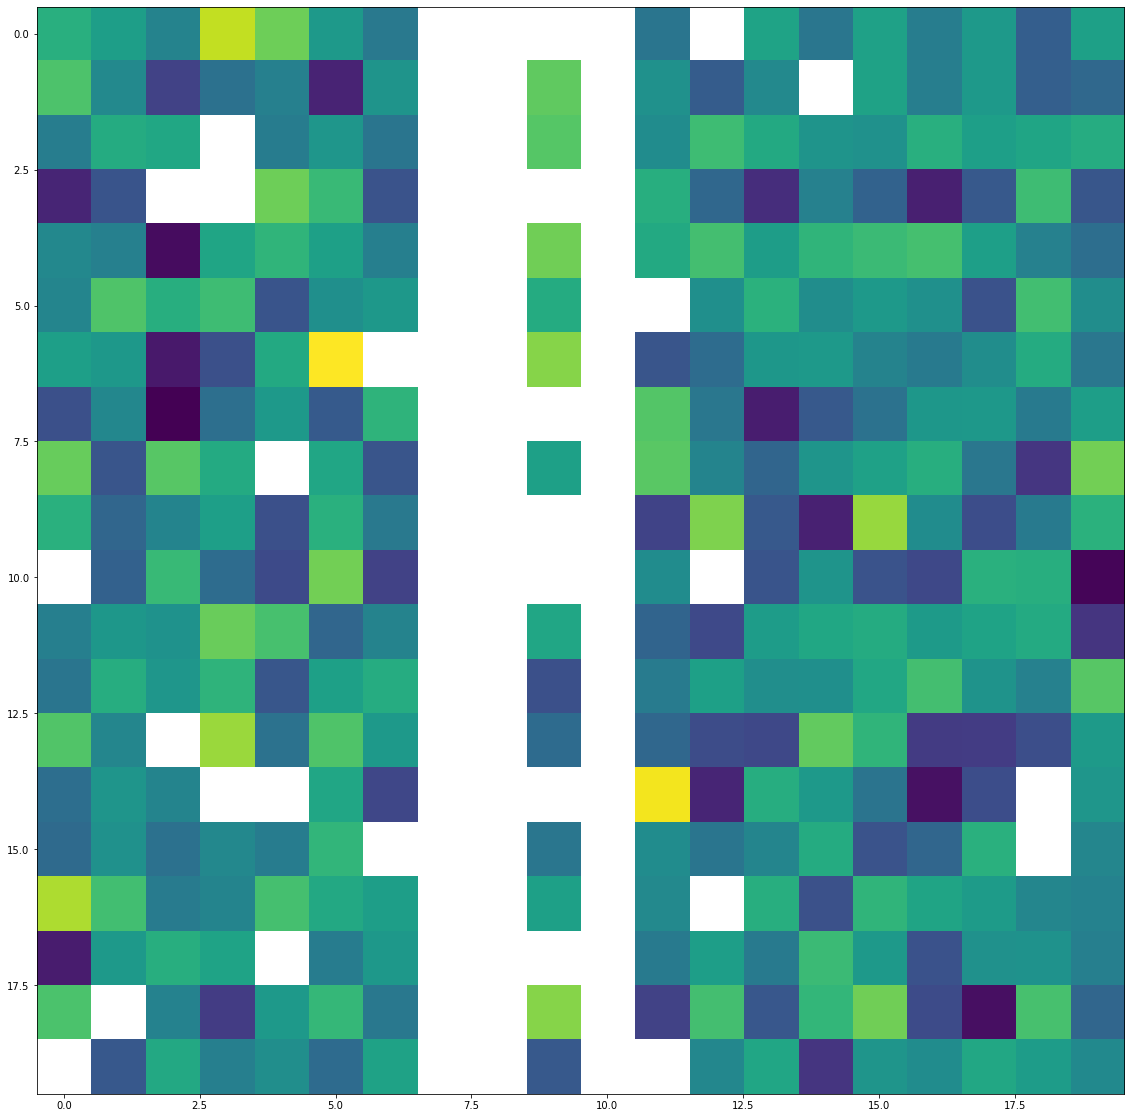

Resized:


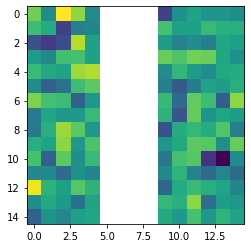

Region4 Region1
(20, 20)


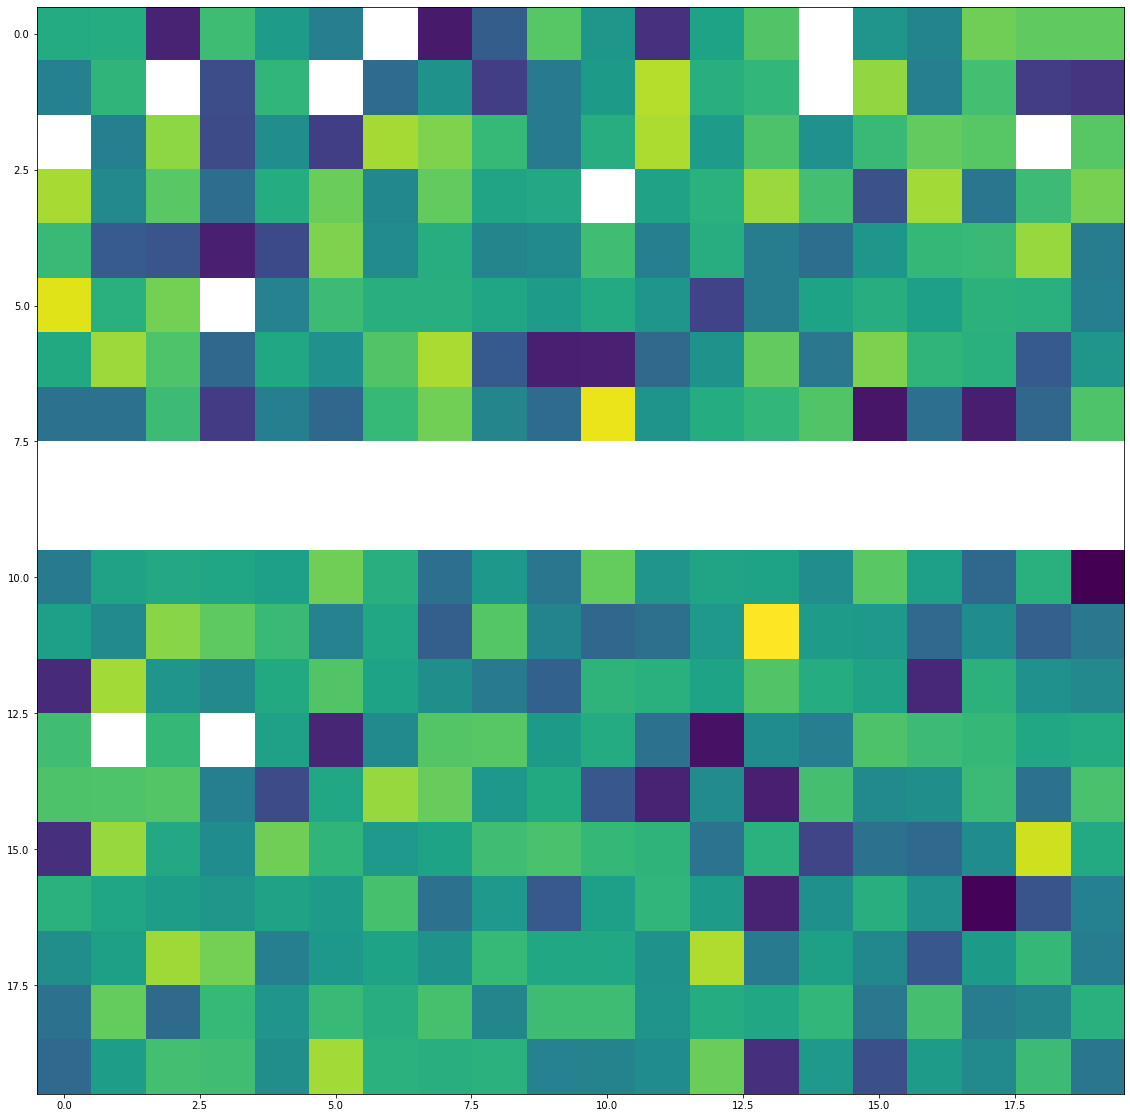

Masked:


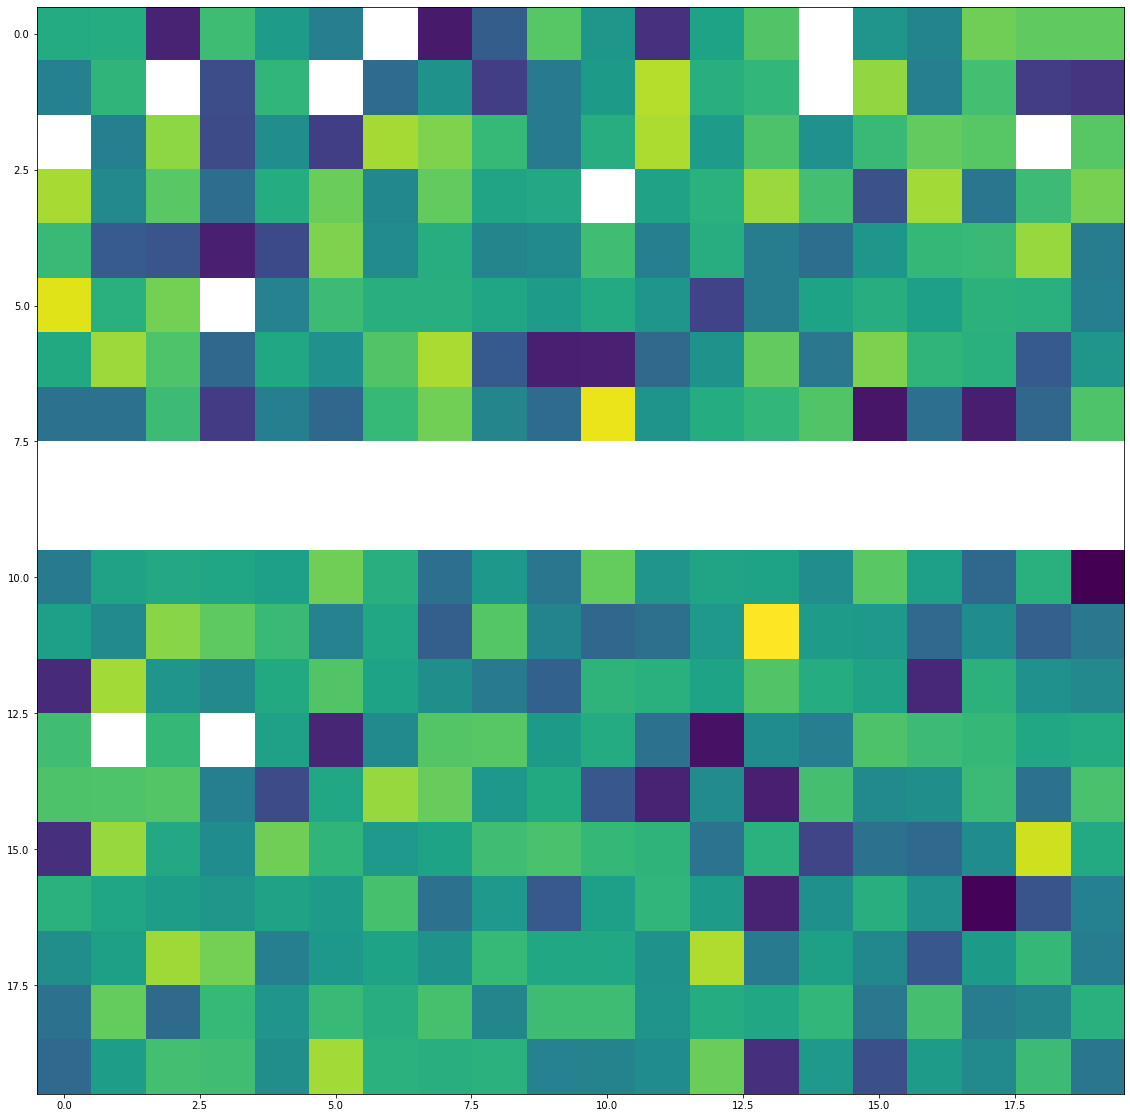

Resized:


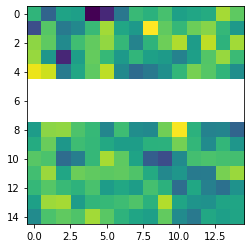

Region4 Region2
(20, 20)


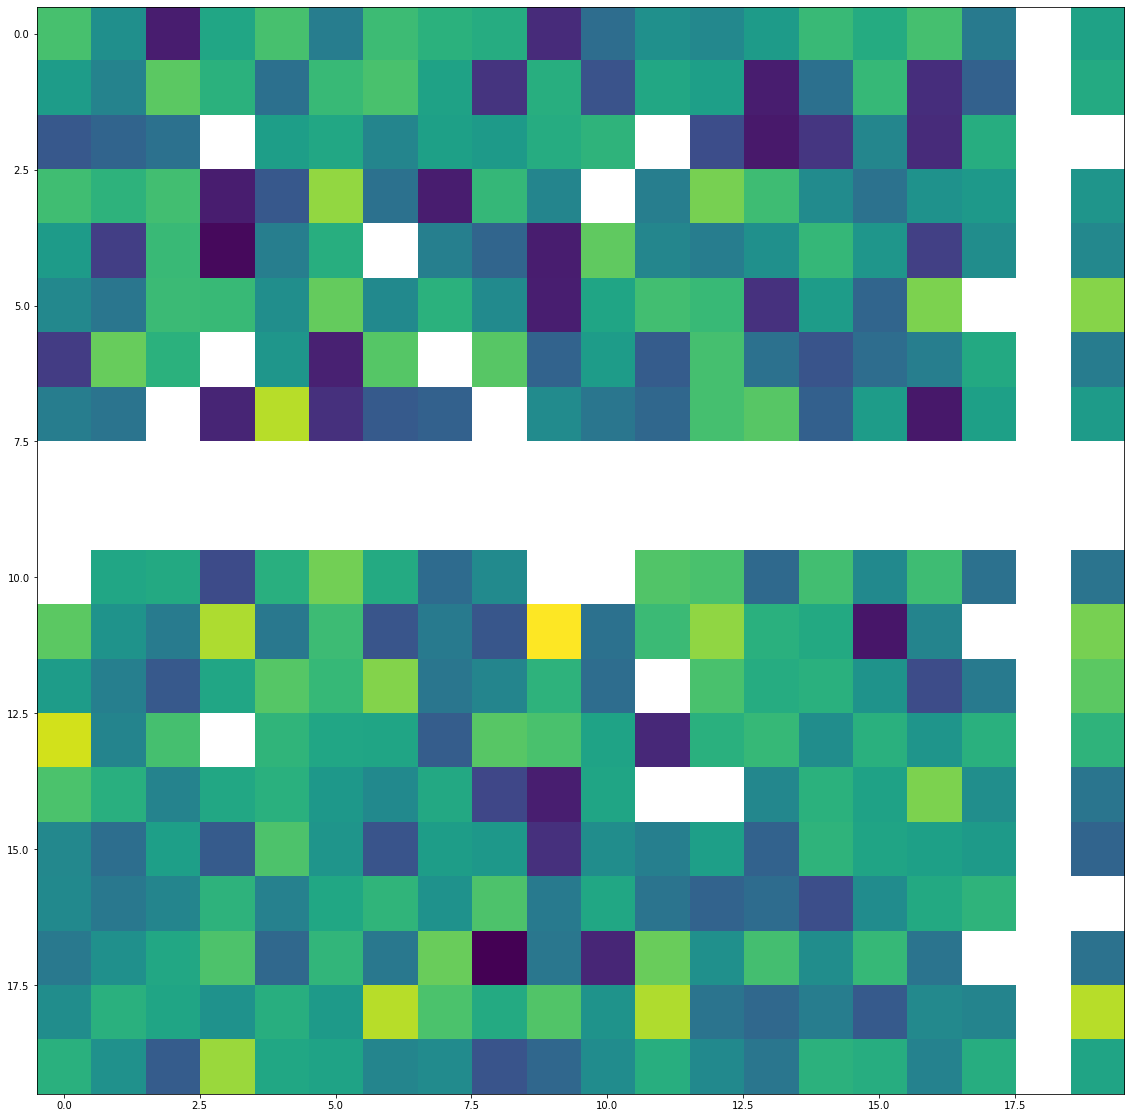

Masked:


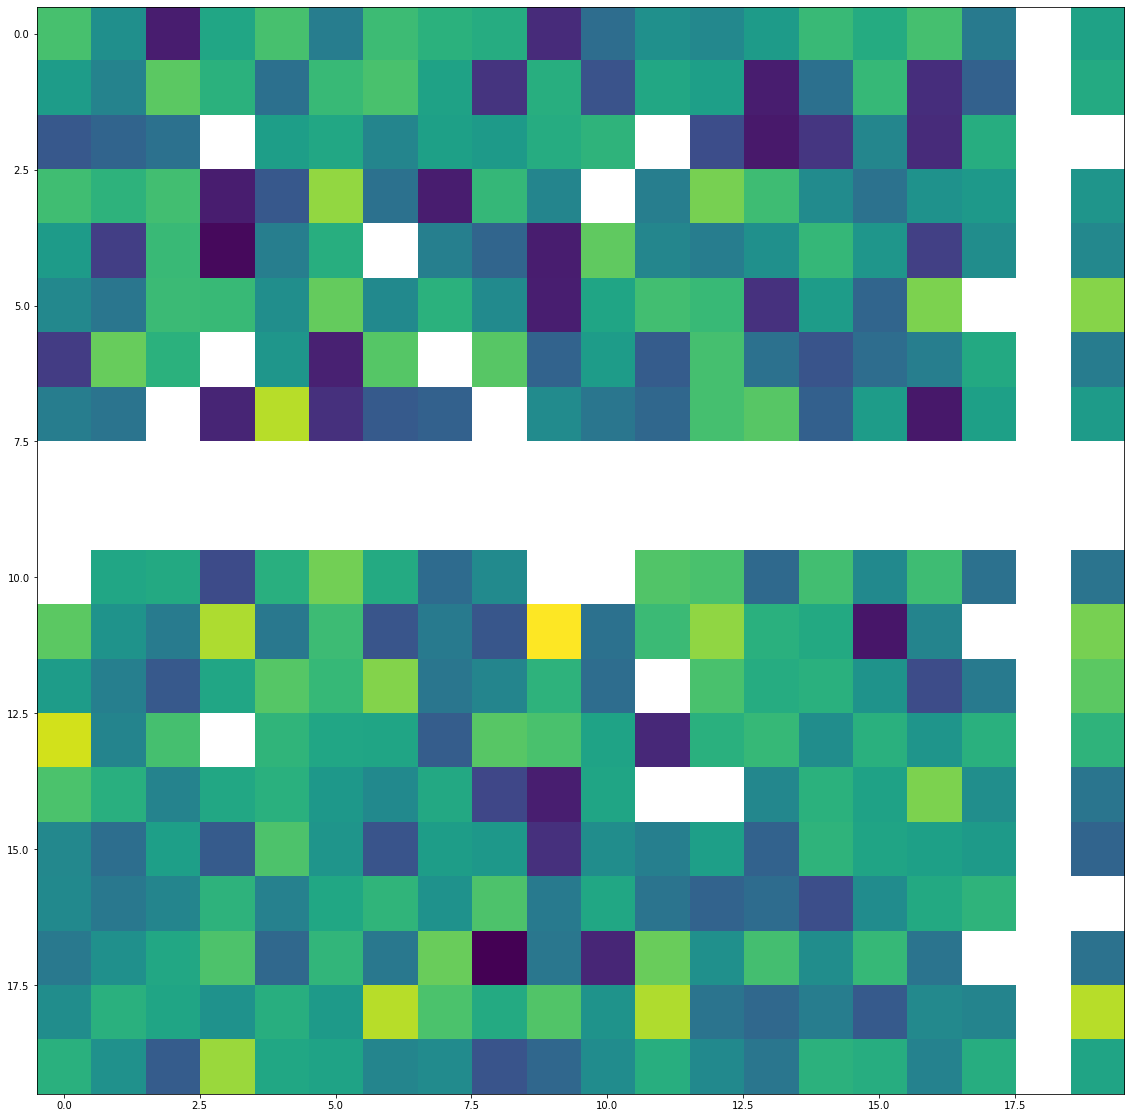

Resized:


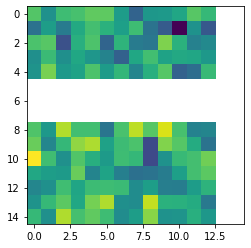

Region4 Region3
(20, 20)


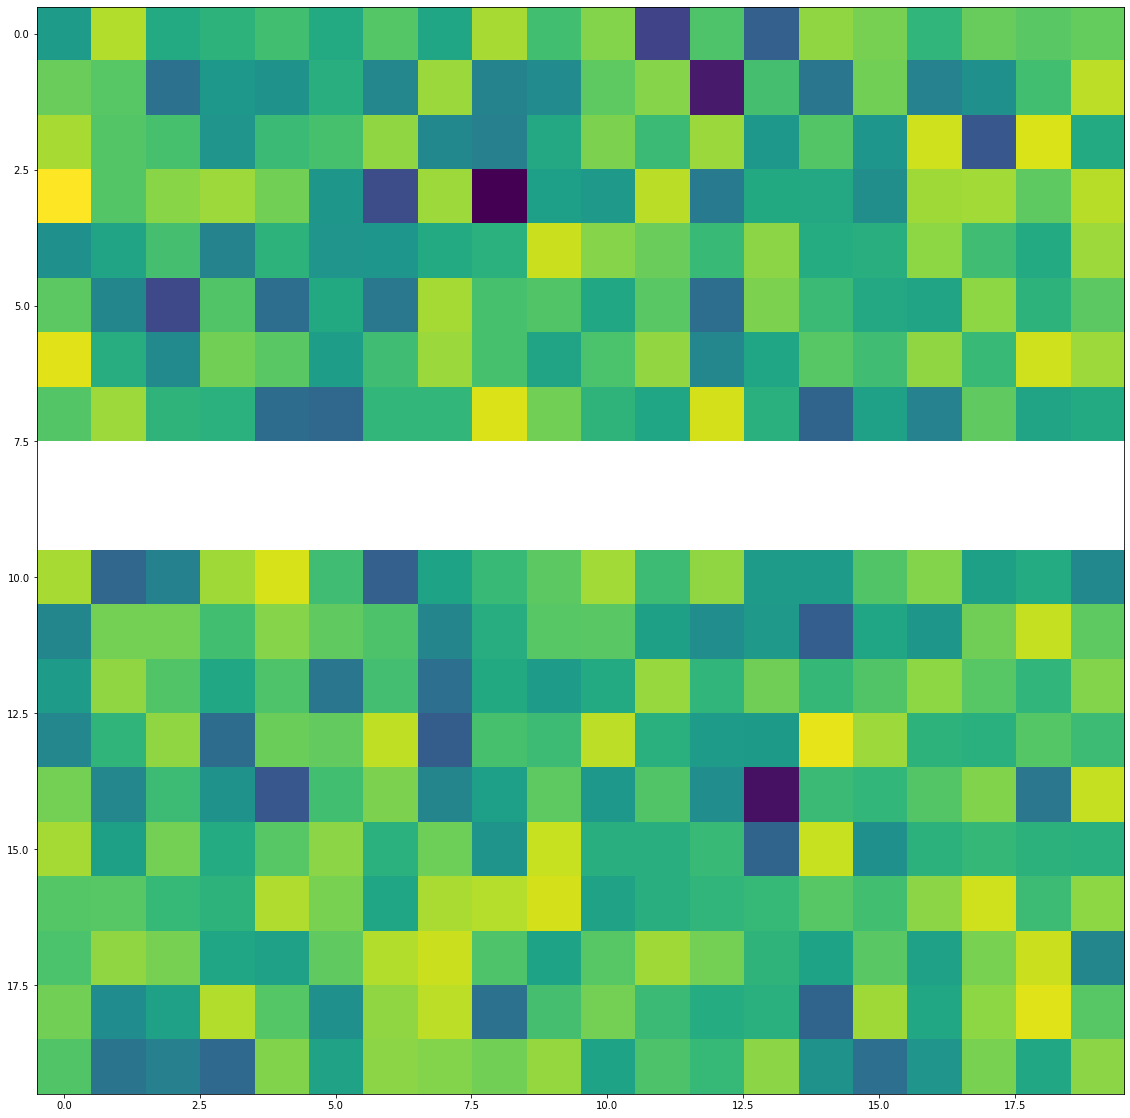

Masked:


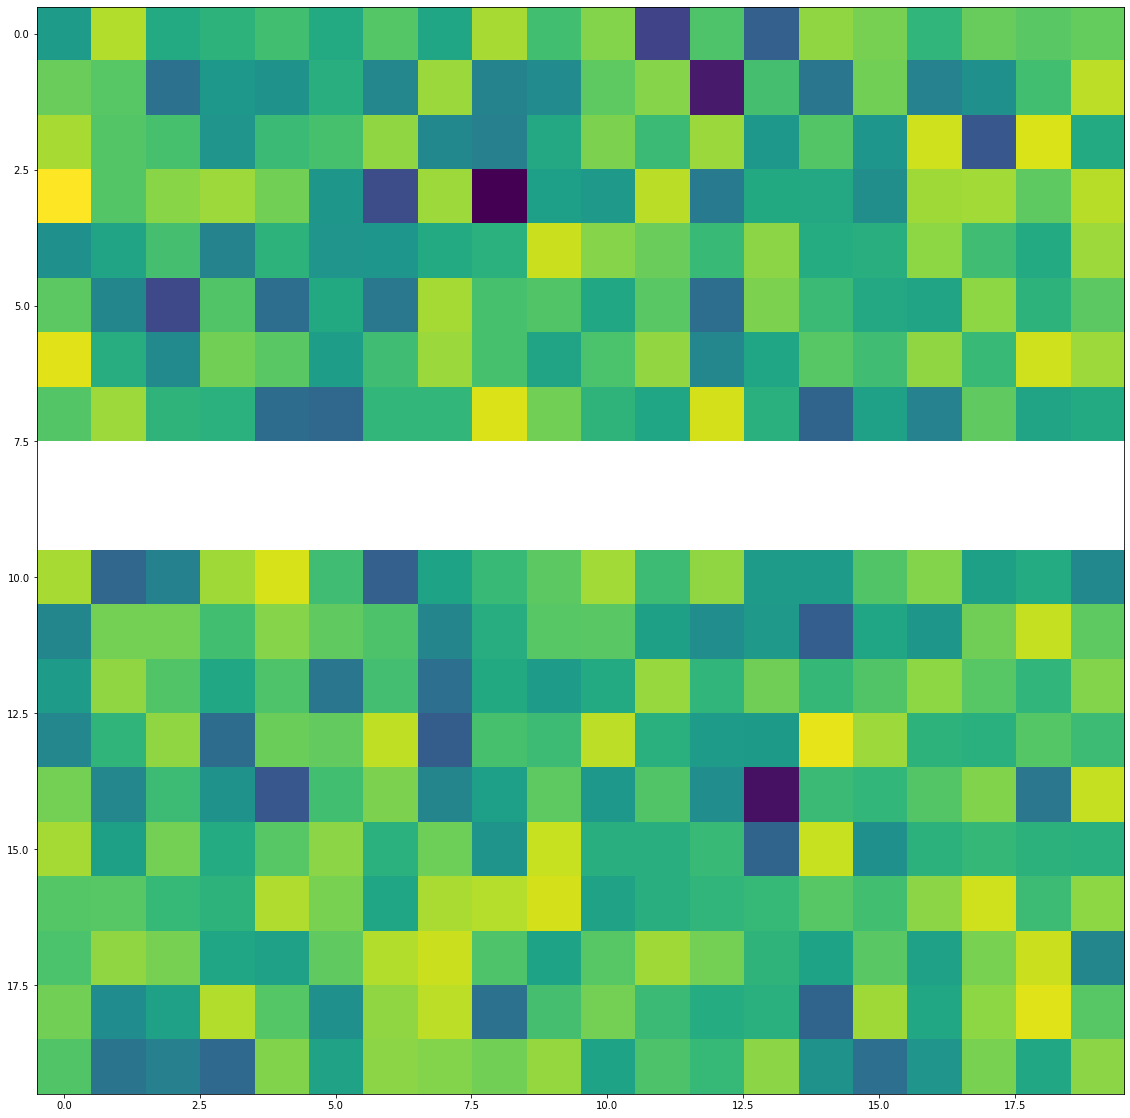

Resized:


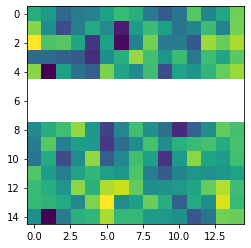

Region4 Region4
(20, 20)


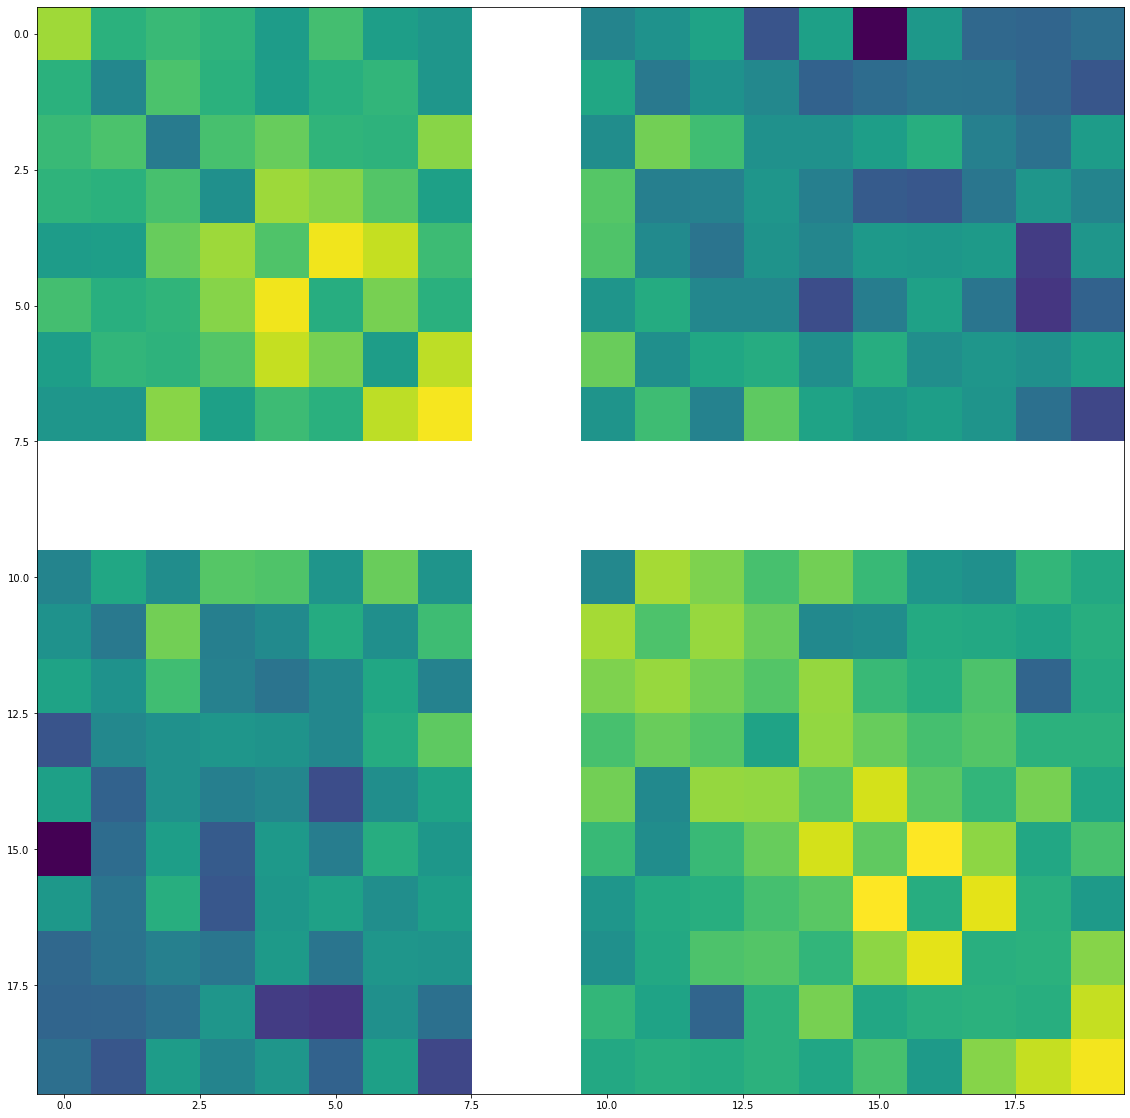

Masked:


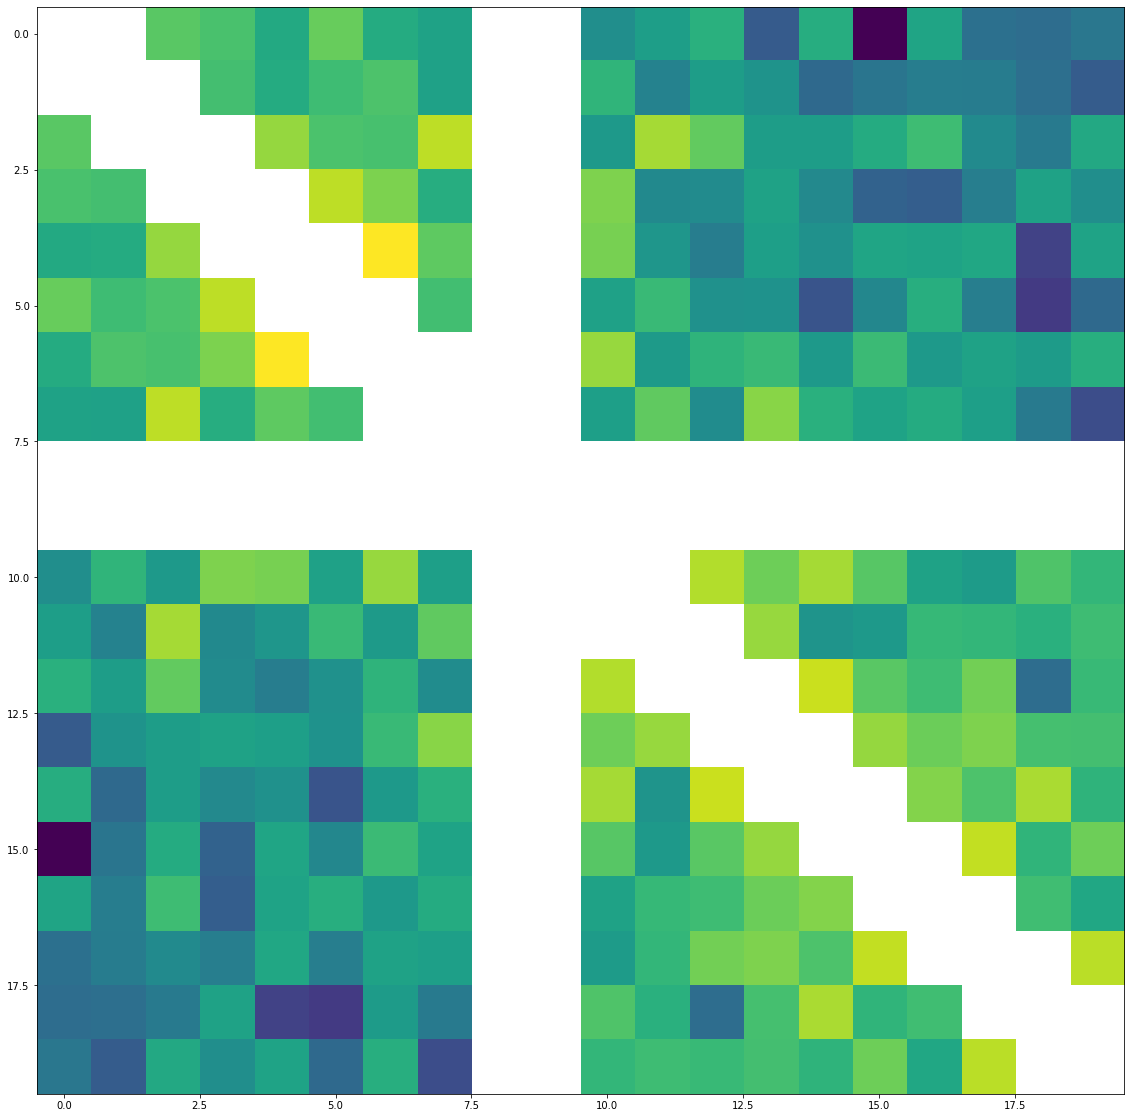

Resized:


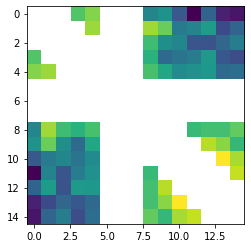

Region4 Region5
(20, 20)


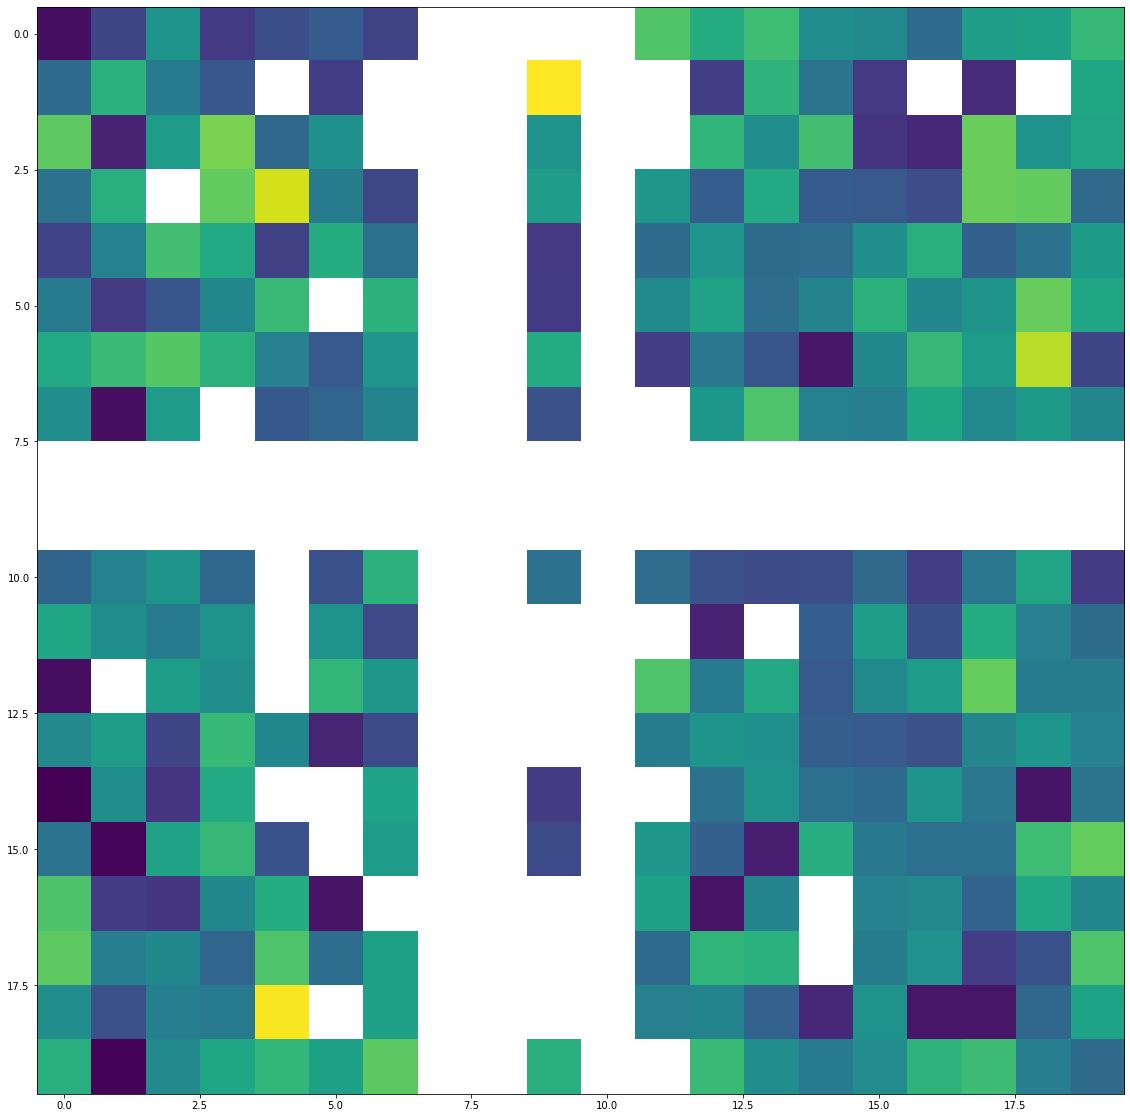

Masked:


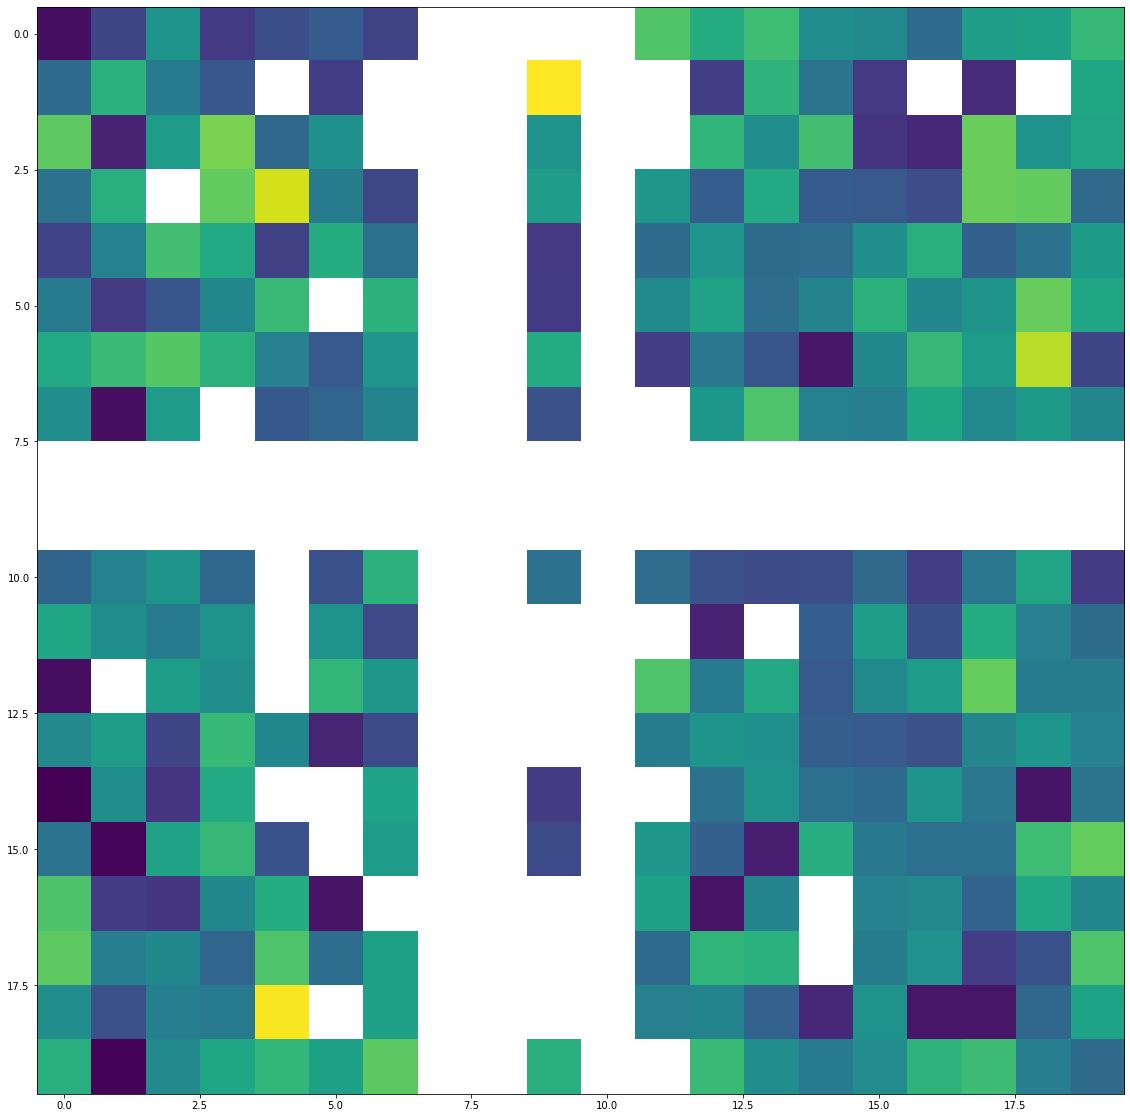

Resized:


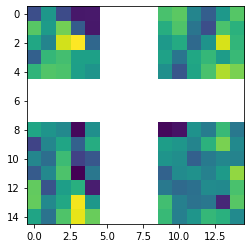

Region5 Region1
(20, 20)


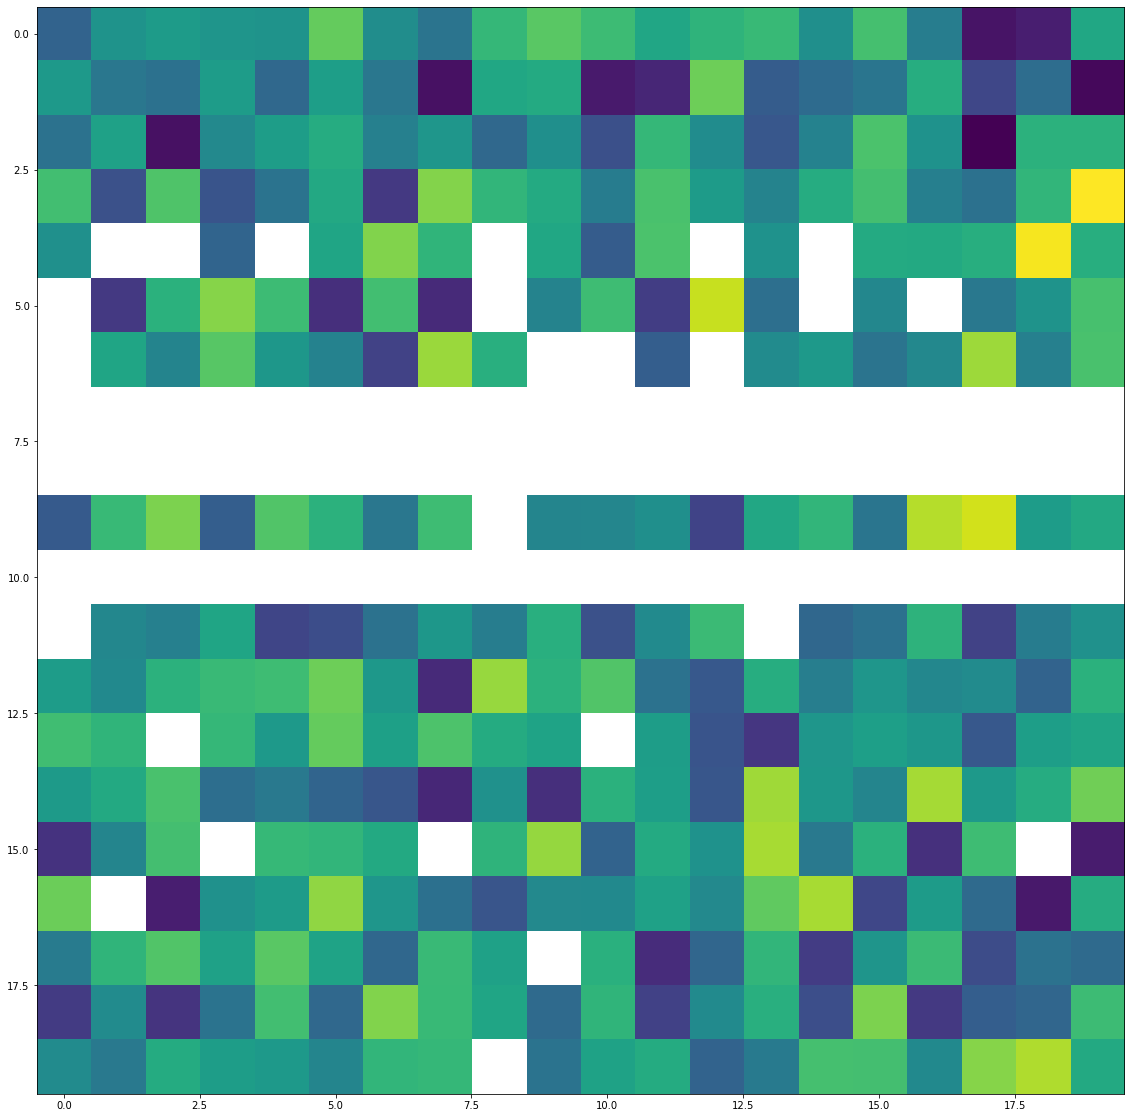

Masked:


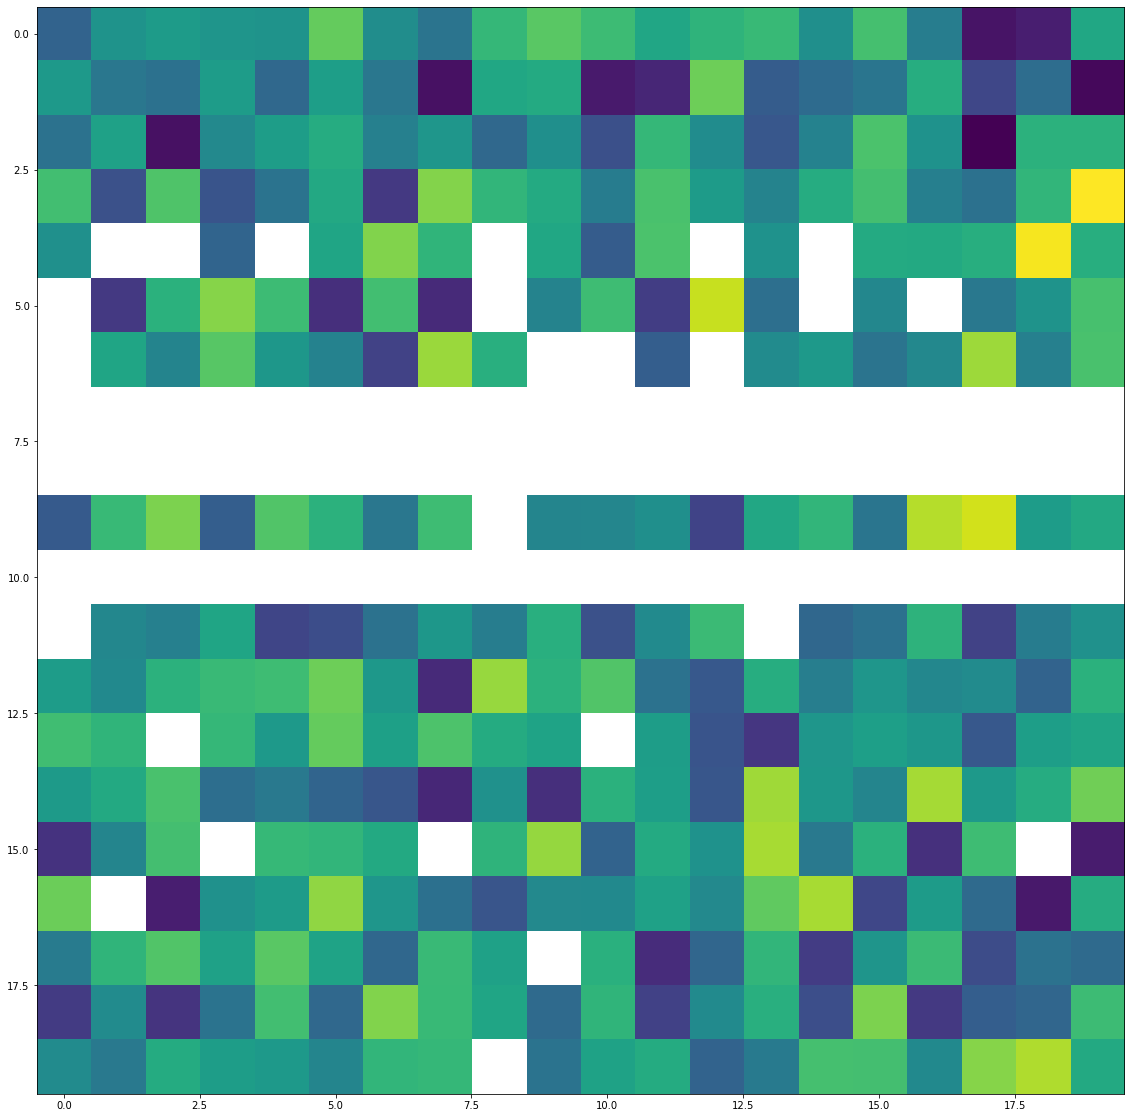

Resized:


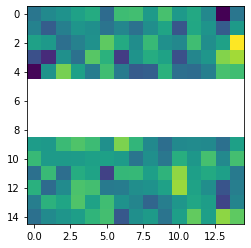

Region5 Region2
(20, 20)


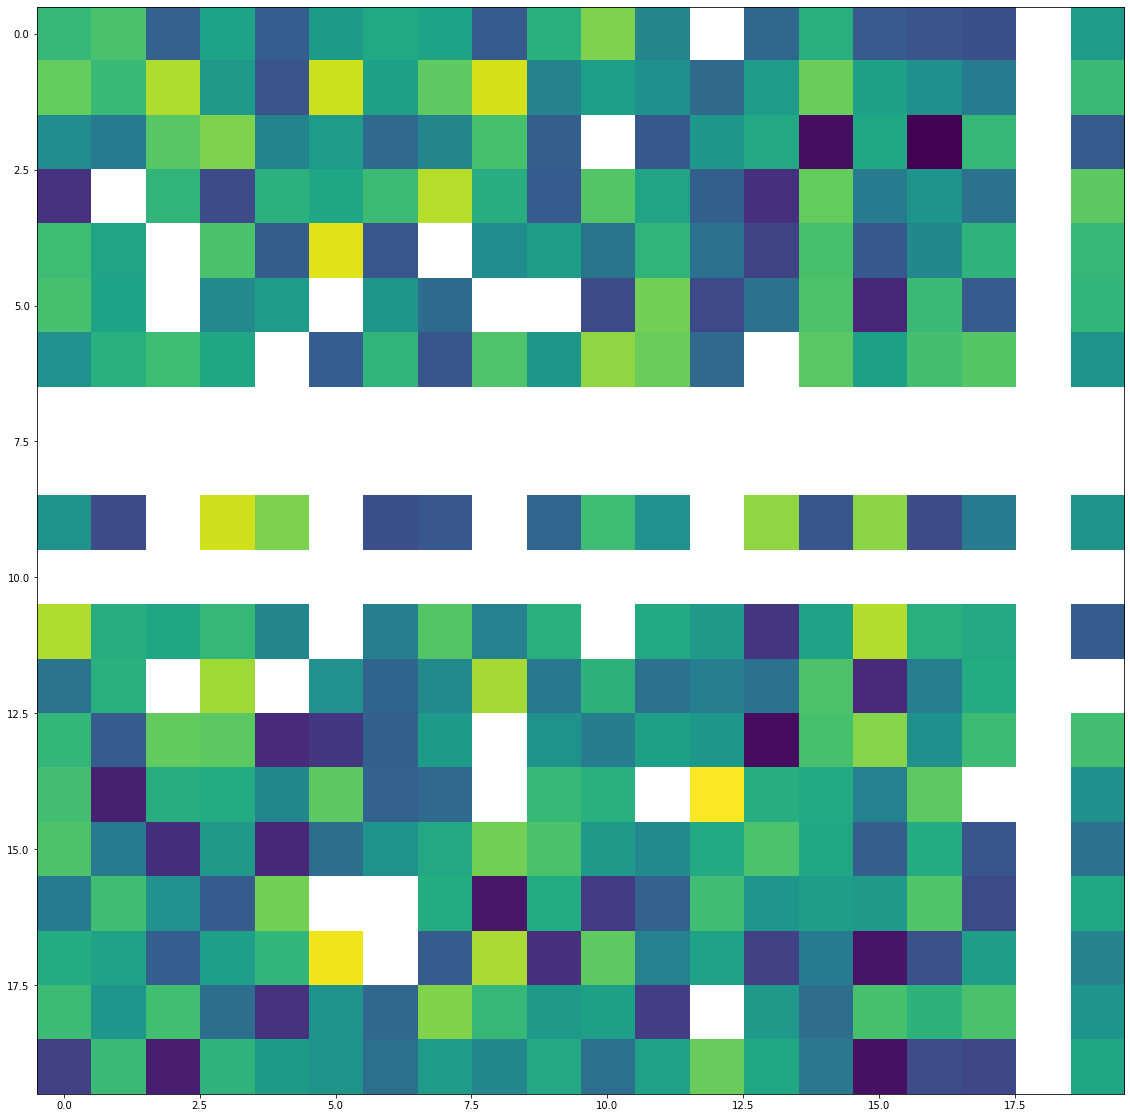

Masked:


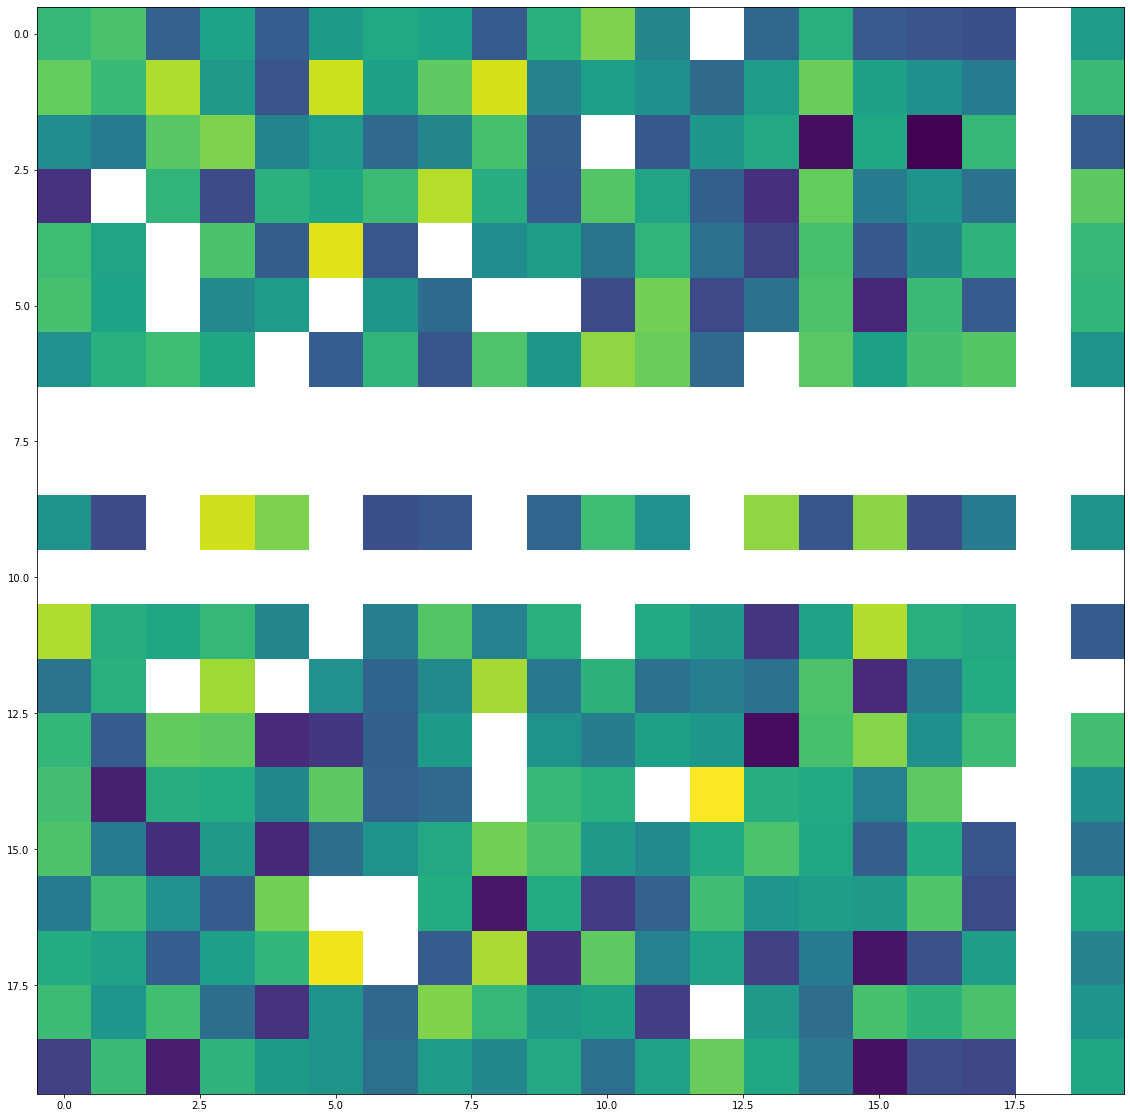

Resized:


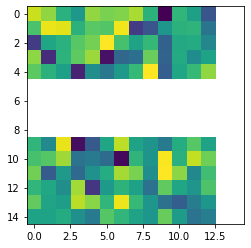

Region5 Region3
(20, 20)


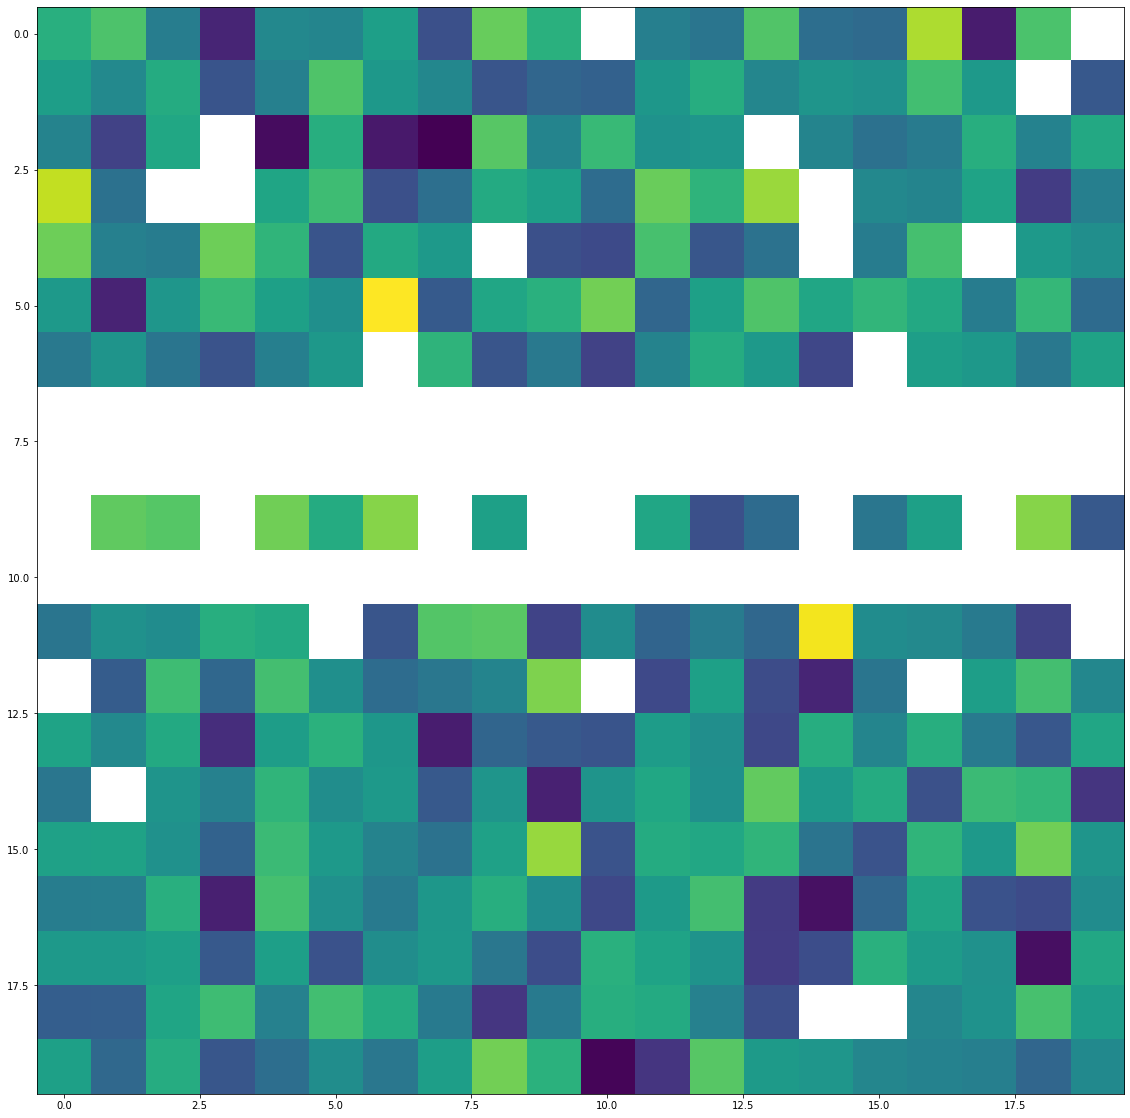

Masked:


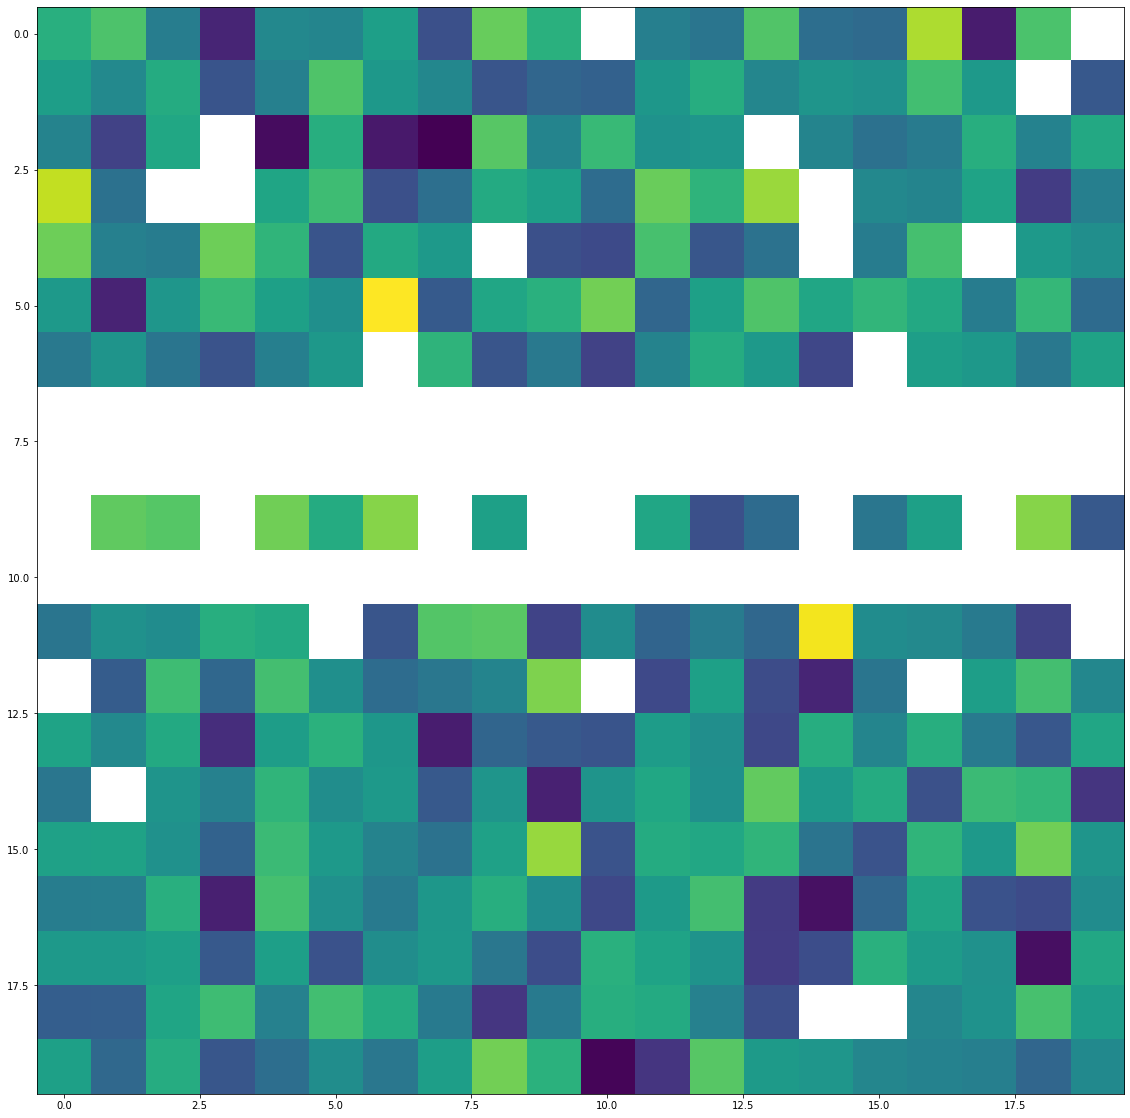

Resized:


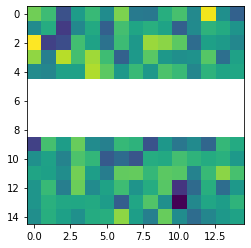

Region5 Region4
(20, 20)


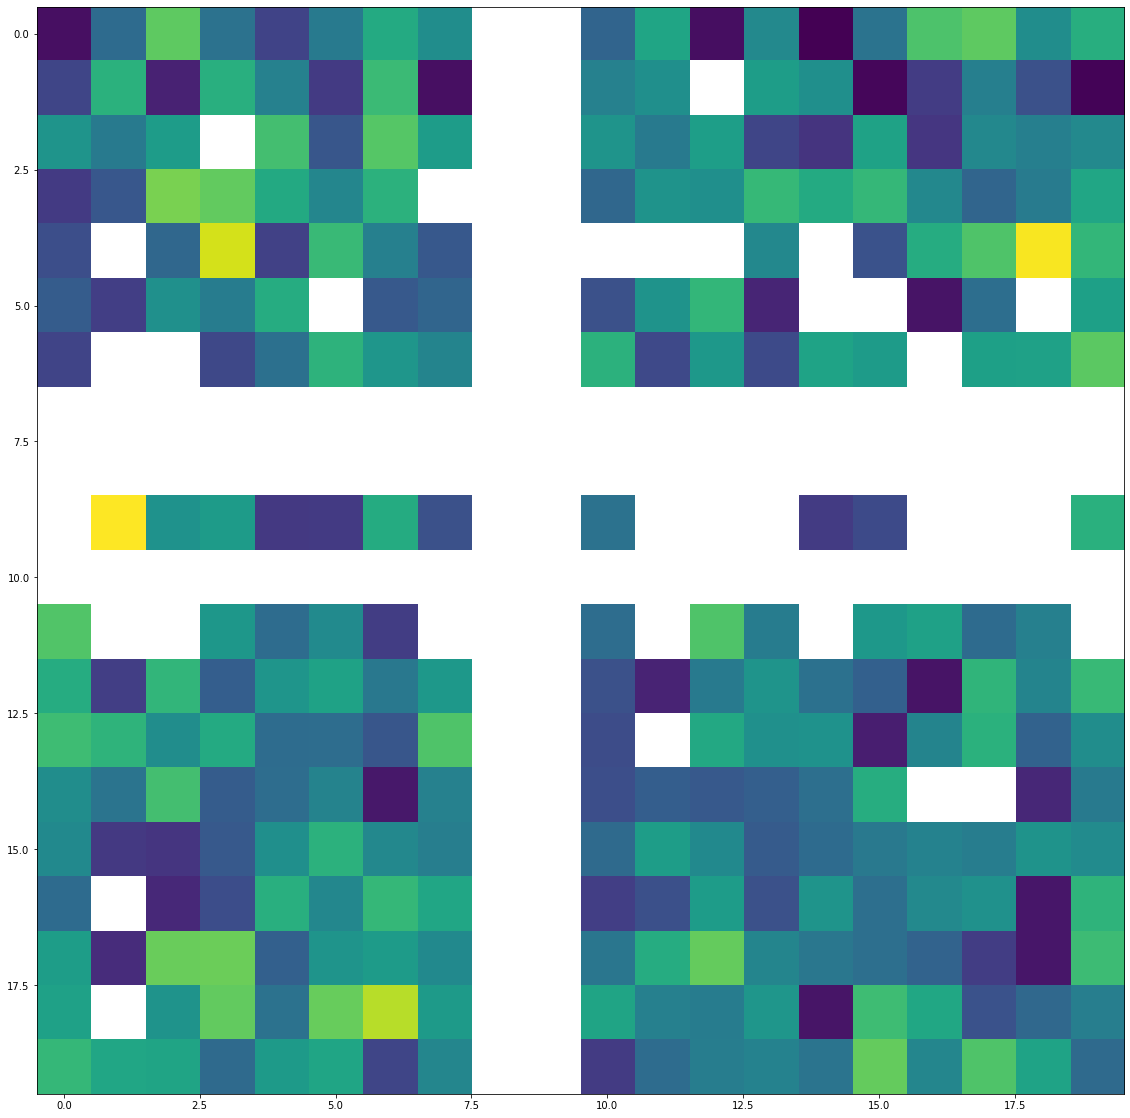

Masked:


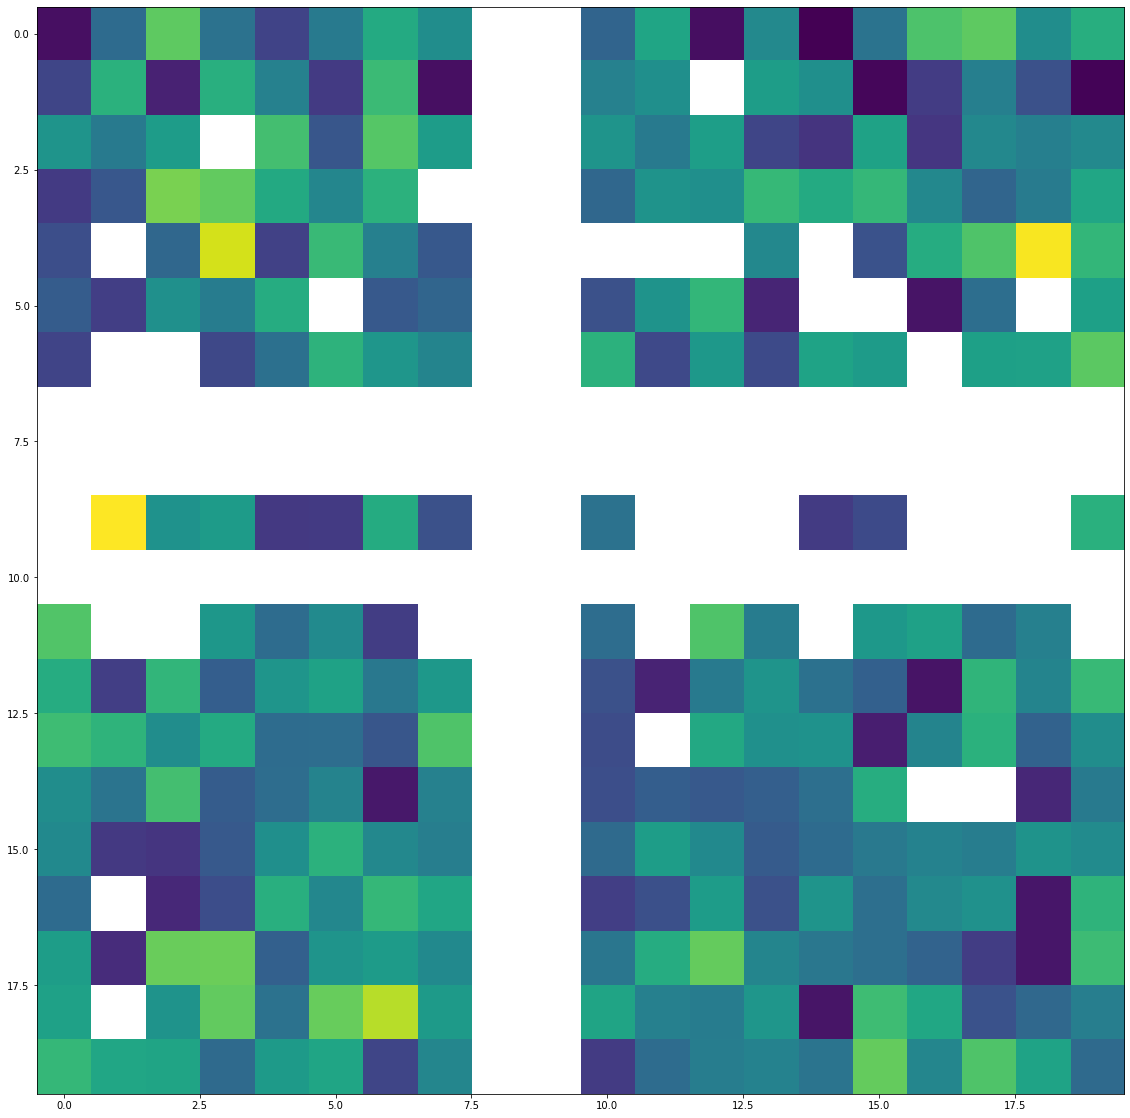

Resized:


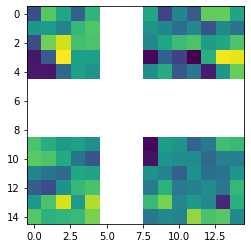

Region5 Region5
(20, 20)


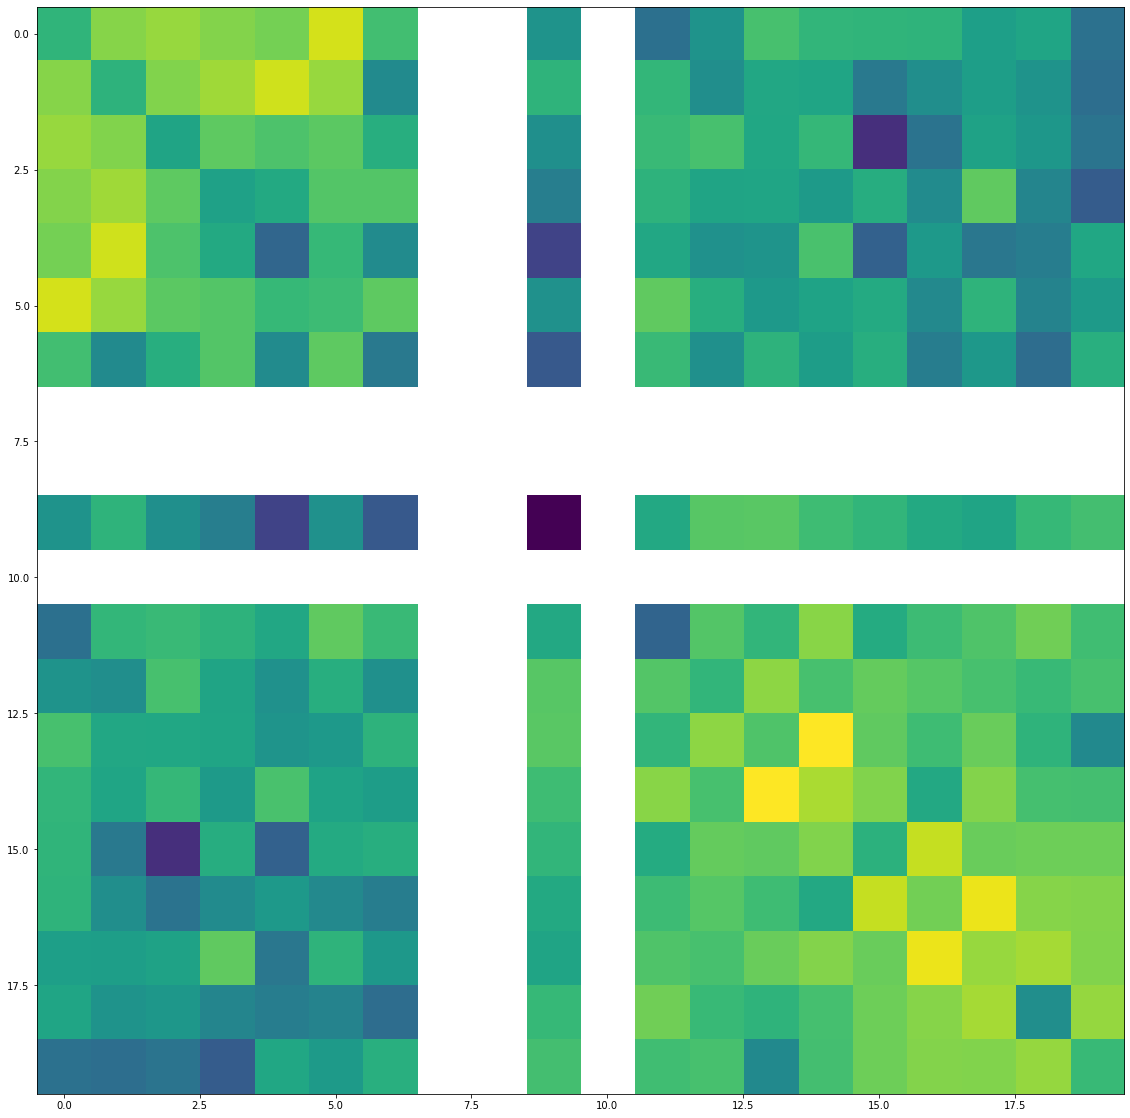

Masked:


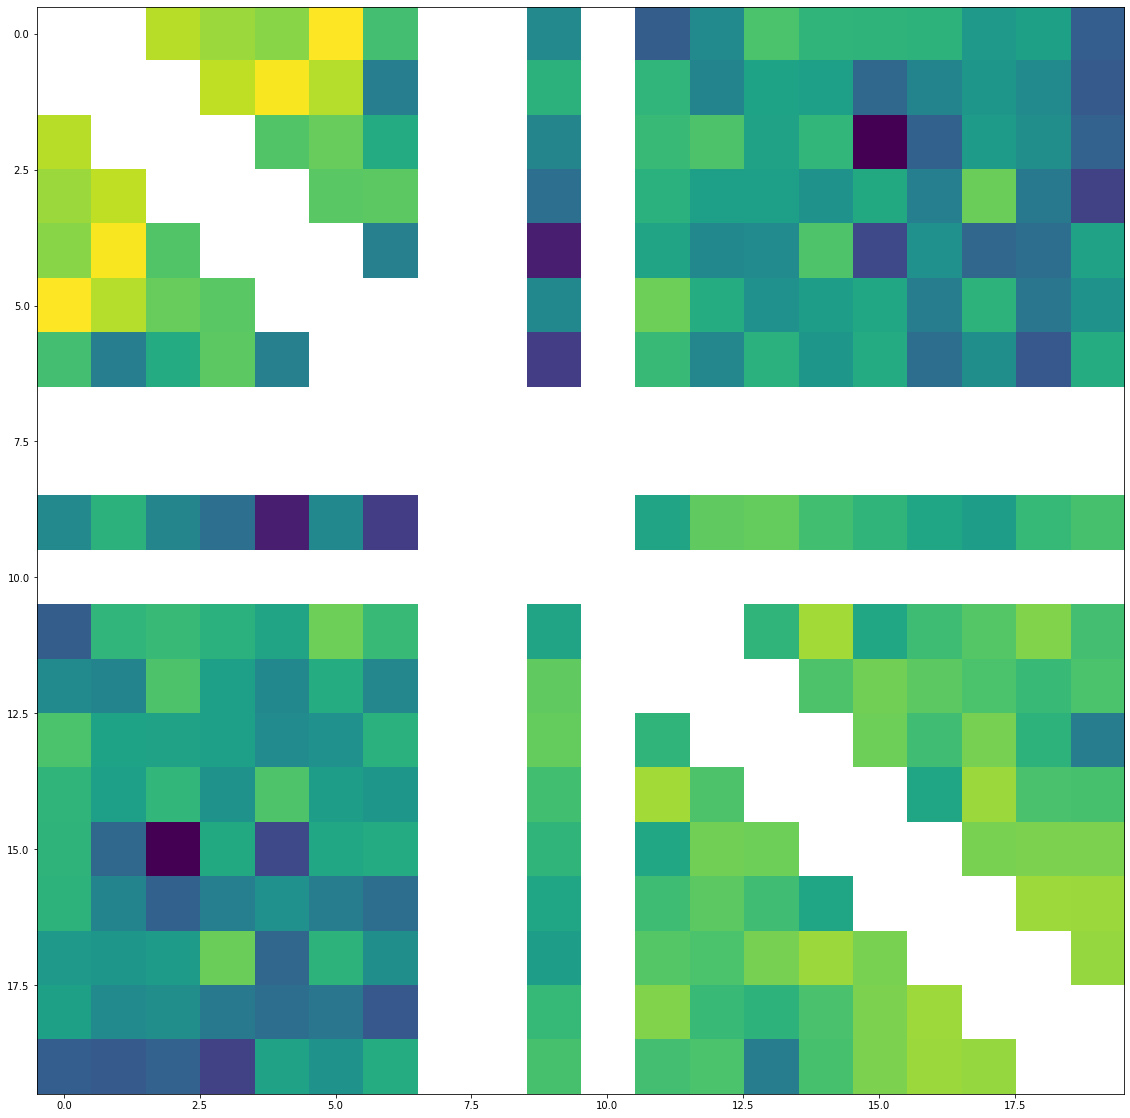

Resized:


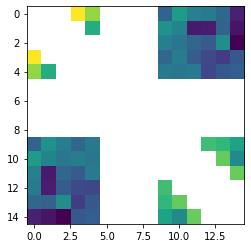

Diagonal pileup:


/tmp/ipykernel_621655/3237019885.py:40: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


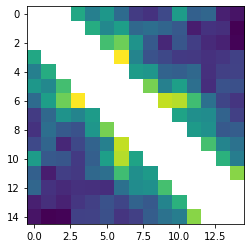

Contact pileup:


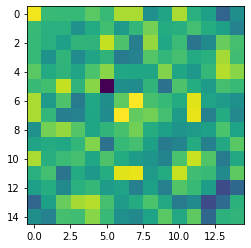

In [5]:
# hicue region parameters
for i in range(1):#range(len(hics)):
    print(hics[i])
    cool = cooler.Cooler(hics[i])
    pileup_diag = []
    pileup_contact = []
    #for k in range(len(dickeya_padded_regions)):
    for _, region1 in dickeya_padded_regions.iterrows():
        #region1 = dickeya_padded_regions.iloc[k]
        #print(cool.chromsizes[region1["Chromosome"]])
        #for l in range(k + 1, len(dickeya_padded_regions)):
        for _, region2 in dickeya_padded_regions.iterrows():
            #region2 = dickeya_padded_regions.iloc[l]
            
            print(region1["Id"], region2["Id"])
            submat = extract_window_region(cool, region1, region2, is_loc_circ1 = True, is_loc_circ2 = True)
            print(submat.shape)
            plt.figure(figsize=(20, 20))
            plt.imshow(np.log10(submat))
            plt.show()
            
            print("Masked:")
            submat = mask_diagonal_region(submat, region1, region2, binning = binning, diagonal_mask= 2000, chromsize = cool.chromsizes[region1["Chromosome"]])
            plt.figure(figsize=(20, 20))
            plt.imshow(np.log10(submat))
            plt.show()

            print("Resized:")
            resized_submat = resize_window(submat, expected_size = 15)
            plt.imshow(np.log10(resized_submat))
            plt.show()

            if region1["Id"] == region2["Id"]:
                pileup_diag.append(resized_submat)
            else:
                pileup_contact.append(resized_submat)

    if len(pileup_diag) > 0:
        print("Diagonal pileup:")
        plt.imshow(np.nanmedian(pileup_diag, axis=0))
        plt.show()

    if len(pileup_contact) > 0:
        print("Contact pileup:")
        plt.imshow(np.log10(np.nanmedian(pileup_contact, axis=0)))
        plt.show()

In [45]:
# plasmodium falciparum test
# hicue region parameters
test_folder = "../test_data/regions"
test_out_folder = "region_results"
hic = "MicroC-Bartfai-Control.mcool"
cool = cooler.Cooler(f"{test_folder}/{hic}::resolutions/{binning}")
binning = 5000
min_size = 2 # minimal size of region in bins
bed_file = "3D7_aHP1.sort.bed"
heterochromatin_regions = pd.read_csv(f"{test_folder}/{bed_file}", sep= '\t', header = None)
heterochromatin_regions.columns = ["Chromosome", "Start", "End"]
heterochromatin_regions["Id"] = [i for i in range(len(heterochromatin_regions))]

heterochromatin_padded_regions = []
for i in range(len(heterochromatin_regions)):
    region = heterochromatin_regions.iloc[i]
    chromsize = cool.chromsizes[region["Chromosome"]]
    if abs(region["Start"] - region["End"]) >= (binning * min_size):
        heterochromatin_padded_regions.append(apply_padding(region, chromsize, padding_size = 0.5))

heterochromatin_padded_regions = pd.DataFrame(heterochromatin_padded_regions)
heterochromatin_padded_regions

/tmp/ipykernel_10501/2372808659.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region["Padded_start"] = (region["Start"] - padding) % chromsize
/tmp/ipykernel_10501/2372808659.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region["Padded_start"] = (region["Start"] - padding) % chromsize
/tmp/ipykernel_10501/2372808659.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region["Padded_end"] = (region["End"] + padding) % chroms

,Chromosome,Start,End,Id,Padded_start,Padded_end,Padding,Size
0,Pf3D7_01_v3,0,37100,0,622301,55650,18550,18550
4,Pf3D7_01_v3,53200,67100,4,46250,74050,6950,6950
12,Pf3D7_01_v3,520500,536100,12,512700,543900,7800,7800
15,Pf3D7_01_v3,549300,578000,15,534950,592350,14350,14350
18,Pf3D7_01_v3,607300,621600,18,600150,628750,7150,7150
...,...,...,...,...,...,...,...,...
193,Pf3D7_13_v3,2888500,2913700,193,2875900,1064,12600,12600
197,Pf3D7_14_v3,13800,32900,197,4250,42450,9550,9550
200,Pf3D7_14_v3,3087700,3114800,200,3074150,3128350,13550,13550
203,Pf3D7_14_v3,3165500,3186500,203,3155000,3197000,10500,10500


Diagonal pileup Pf3D7_01_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


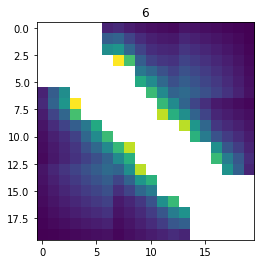

Contact pileup Pf3D7_01_v3:


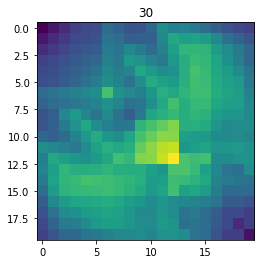

Diagonal pileup Pf3D7_02_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


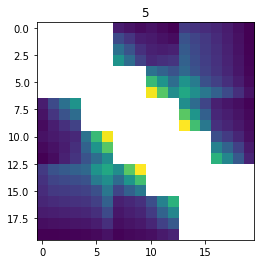

Contact pileup Pf3D7_02_v3:


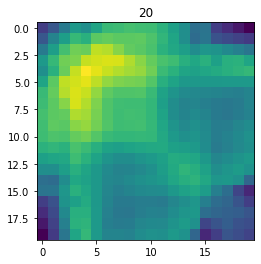

Diagonal pileup Pf3D7_03_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


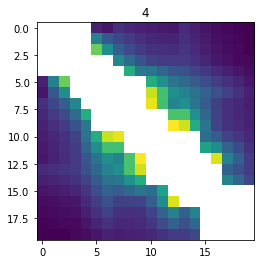

Contact pileup Pf3D7_03_v3:


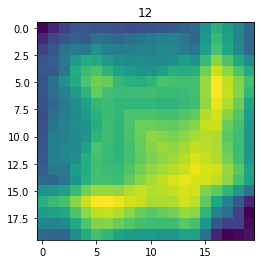

Diagonal pileup Pf3D7_04_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


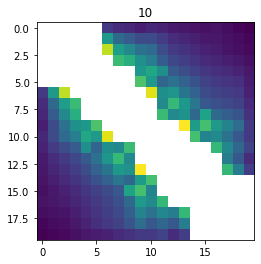

Contact pileup Pf3D7_04_v3:


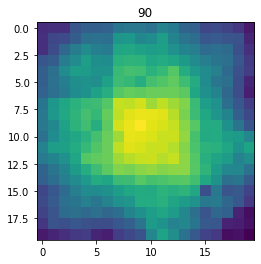

Diagonal pileup Pf3D7_05_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


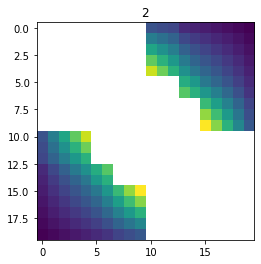

Contact pileup Pf3D7_05_v3:


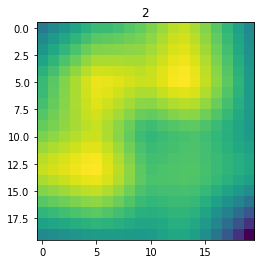

Diagonal pileup Pf3D7_06_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


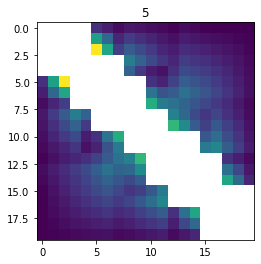

Contact pileup Pf3D7_06_v3:


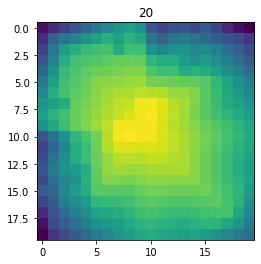

Diagonal pileup Pf3D7_07_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


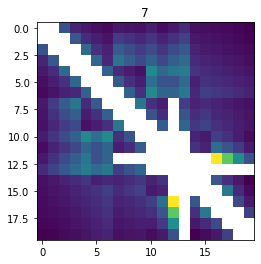

Contact pileup Pf3D7_07_v3:


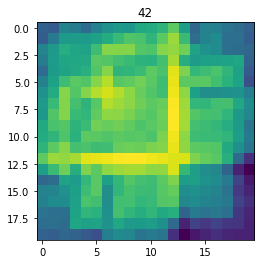

Diagonal pileup Pf3D7_08_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


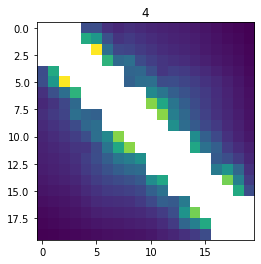

Contact pileup Pf3D7_08_v3:


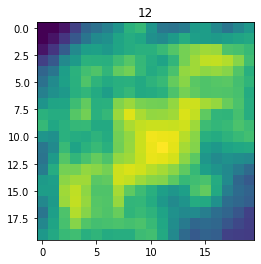

Diagonal pileup Pf3D7_09_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


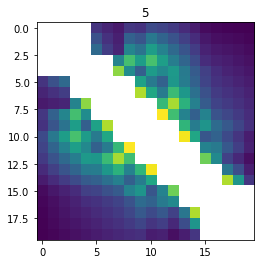

Contact pileup Pf3D7_09_v3:


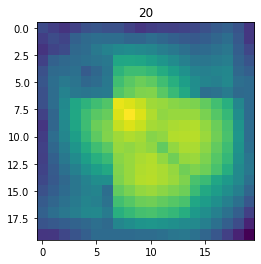

Diagonal pileup Pf3D7_10_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


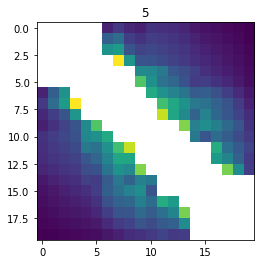

Contact pileup Pf3D7_10_v3:


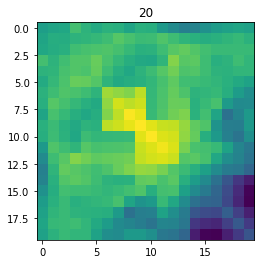

Diagonal pileup Pf3D7_11_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


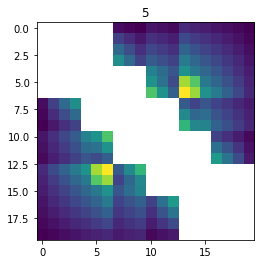

Contact pileup Pf3D7_11_v3:


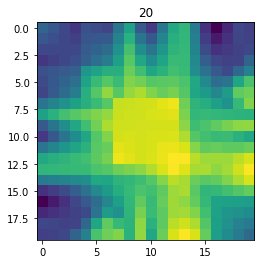

Diagonal pileup Pf3D7_12_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


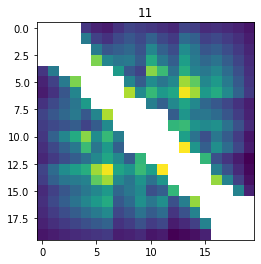

Contact pileup Pf3D7_12_v3:


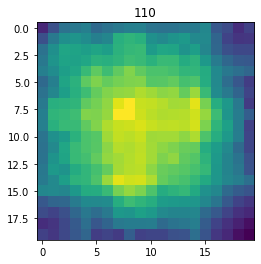

Diagonal pileup Pf3D7_13_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


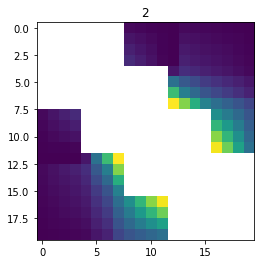

Contact pileup Pf3D7_13_v3:


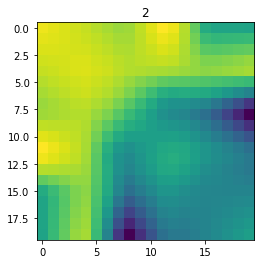

Diagonal pileup Pf3D7_14_v3:


/tmp/ipykernel_10501/1223658678.py:34: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(pileup_diag, axis=0))


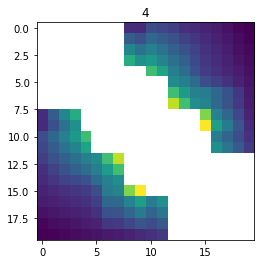

Contact pileup Pf3D7_14_v3:


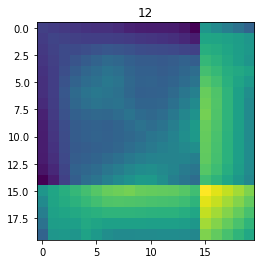

In [46]:
# separating per chromosome for easier analysis
for chrom, chromsize in cool.chromsizes.items():
    pileup_diag = []
    pileup_contact = []
    heterochrom_chrom = heterochromatin_padded_regions[heterochromatin_padded_regions["Chromosome"] == chrom]
    for _, region1 in heterochrom_chrom.iterrows():
        for _, region2 in heterochrom_chrom.iterrows():

            #print(region1["Id"], region2["Id"])
            submat = extract_window_region(cool, region1, region2)
            #print(submat.shape)
            #plt.figure(figsize=(20, 20))
            #plt.imshow(np.log10(submat))
            #plt.show()

            #print("Masked:")
            submat = mask_diagonal_region(submat, region1, region2, binning = binning, diagonal_mask= binning, chromsize = chromsize)
            #plt.figure(figsize=(20, 20))
            #plt.imshow(np.log10(submat))
            #plt.show()

            #print("Resized:")
            resized_submat = resize_window(submat, expected_size = 20)
            #plt.imshow(np.log10(resized_submat))
            #plt.show()

            if region1["Id"] == region2["Id"]:
                pileup_diag.append(resized_submat)
            else:
                pileup_contact.append(resized_submat)

    if len(pileup_diag) > 0:
        print(f"Diagonal pileup {chrom}:")
        plt.imshow(np.nanmedian(pileup_diag, axis=0))
        plt.title(len(pileup_diag))
        plt.savefig(f"{test_out_folder}/{chrom}_diag_{binning}_pileup.png")
        plt.savefig(f"{test_out_folder}/{chrom}_diag_{binning}_pileup.pdf")
        plt.show()

    if len(pileup_contact) > 0:
        print(f"Contact pileup {chrom}:")
        plt.imshow(np.log10(np.nanmedian(pileup_contact, axis=0)))
        plt.title(len(pileup_contact))
        plt.savefig(f"{test_out_folder}/{chrom}_contact_{binning}_pileup.png")
        plt.savefig(f"{test_out_folder}/{chrom}_contact_{binning}_pileup.pdf")
        plt.show()

Diagonal pileup Pf3D7_MIT_v3:


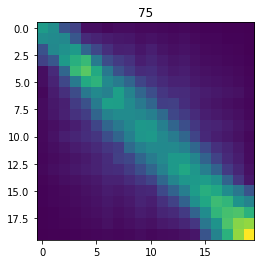

Contact cis pileup Pf3D7_MIT_v3:


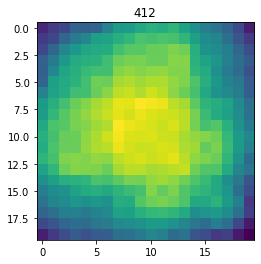

Contact trans pileup Pf3D7_MIT_v3:


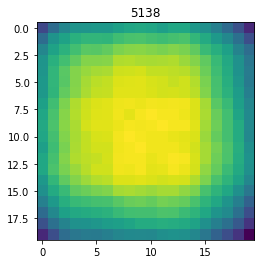

In [47]:
# cis/trans contacts
pileup_cis = []
pileup_trans = []
pileup_diag = []
for _, region1 in heterochromatin_padded_regions.iterrows():
    for _, region2 in heterochromatin_padded_regions.iterrows():

        #print(region1["Id"], region2["Id"])
        submat = extract_window_region(cool, region1, region2)
        #print(submat.shape)
        #plt.figure(figsize=(20, 20))
        #plt.imshow(np.log10(submat))
        #plt.show()

        #print("Masked:")
        submat = mask_diagonal_region(submat, region1, region2, binning = binning, diagonal_mask= binning, chromsize = chromsize)
        #plt.figure(figsize=(20, 20))
        #plt.imshow(np.log10(submat))
        #plt.show()

        #print("Resized:")
        resized_submat = resize_window(submat, expected_size = 20)
        #plt.imshow(np.log10(resized_submat))
        #plt.show()

        if region1["Id"] == region2["Id"]:
            pileup_diag.append(resized_submat)
        else:
            if region1["Chromosome"] == region2["Chromosome"]:
                pileup_cis.append(resized_submat)
            else:
                pileup_trans.append(resized_submat)

if len(pileup_diag) > 0:
    print(f"Diagonal pileup {chrom}:")
    plt.imshow(np.nanmedian(pileup_diag, axis=0))
    plt.title(len(pileup_diag))
    plt.savefig(f"{test_out_folder}/all_diag_{binning}_pileup.png")
    plt.savefig(f"{test_out_folder}/all_diag_{binning}_pileup.pdf")
    plt.show()

if len(pileup_cis) > 0:
    print(f"Contact cis pileup {chrom}:")
    plt.imshow(np.log10(np.nanmedian(pileup_cis, axis=0)))
    plt.title(len(pileup_cis))
    plt.savefig(f"{test_out_folder}/cis_contact_{binning}_pileup.png")
    plt.savefig(f"{test_out_folder}/cis_contact_{binning}_pileup.pdf")
    plt.show()
    
if len(pileup_trans) > 0:
    print(f"Contact trans pileup {chrom}:")
    plt.imshow(np.log10(np.nanmedian(pileup_trans, axis=0)))
    plt.title(len(pileup_trans))
    plt.savefig(f"{test_out_folder}/trans_contact_{binning}_pileup.png")
    plt.savefig(f"{test_out_folder}/trans_contact_{binning}_pileup.pdf")
    plt.show()